**Struttura:**
- Sezione 0 - Definizioni
- Sezione 1 — **MOESM1**: $\rho(T)$ a $B=0$ per LSCO S1, LSCO S2, Nd-LSCO.
- Sezione 2 — MOESM2: MR $\rho(B)/\rho(0)$, Nd-LSCO, dati sperimentali.
- Sezione 3 — MOESM3: MR Nd-LSCO, calcoli dei tre rate.
- ... (progressive)
- Sezione 9 — MOESM9: MR LSCO S1, B//c vs B//a.

## Definizioni

In [1]:
# --- T-dipendenza per modello Bessel (eval_T_dep in chambers_lib) ---
T_DEP = {
    "G_is": "linear",
    "G_an": "linear",
}


In [2]:
import importlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.optimize import curve_fit, least_squares, differential_evolution
from tqdm.notebook import tqdm
import matplotlib.gridspec as gridspec
import time

import chambers_lib as cl
import vik_lib

importlib.reload(cl)
importlib.reload(vik_lib)
from vik_lib import fit_with_bar, font1, font2, plot_observable_4panel

%matplotlib inline
print("chambers_lib caricato.  K_meV =", cl.K_MEV)

Funzioni definite.
Funzioni definite.
chambers_lib caricato.  K_meV = 0.116


In [3]:
# Helpers T-dep / phi-tanh e factory del residuo globale vivono in chambers_lib.
from chambers_lib import (
    build_global_residual,
    eval_T_dep,
    fit_phi_tanh,
    fit_T_dep,
    label_T_dep,
    log_bin,
    make_unpack_step,
    phi_tanh,
    T_linear,
    T_quadratic,
    T_linear_no_offset,
    T_quadratic_no_offset,
    T_power,
    T_npar,
    phi_tanh_sym,
    phi_const,
)

eval_phi_tanh = phi_tanh  # compat con vecchio naming

print("T_DEP Bessel corrente:", T_DEP)


def model_step_RR(B, G1, G2, phi_star, m_star):
    return 1.0 + cl.mr_step(B, G1, G2, phi_star, m_star)


def model_bessel_RR(B, G_is, G_an, m_star):
    return 1.0 + cl.MR_Bessel(B, G_is, G_an, m_star)


def _a_cap(style, max_G, c_max, T_high):
    power = 2 if style == "quadratic" else 1
    return max((max_G - c_max), 1e-6) / T_high**power


def _p0_a(style, target, c_guess, T_high):
    power = 2 if style == "quadratic" else 1
    return max((target - c_guess), 0.0) / T_high**power


def unpack_opt(opt_params, unpack_fn):
    """Estrae (p_G1, p_G2, p_phi, m_star_opt) dal vettore ottimale."""
    i = 0
    p_G1  = opt_params[i : i + unpack_fn.n1];    i += unpack_fn.n1
    p_G2  = opt_params[i : i + unpack_fn.n2];    i += unpack_fn.n2
    p_phi = opt_params[i : i + unpack_fn.nphi];   i += unpack_fn.nphi
    ms = (float(opt_params[i]) if unpack_fn.m_star_fixed is None
          else unpack_fn.m_star_fixed)
    return p_G1, p_G2, p_phi, ms


T_DEP Bessel corrente: {'G_is': 'linear', 'G_an': 'linear'}


In [4]:
G1_fn  = cl.T_linear    # Gamma_1(T) : f(T, a, c)              -> a*T + c
G2_fn  = cl.T_linear    # Gamma_2(T) : f(T, a, c)              -> a*T + c
phi_fn = cl.phi_const# phi*(T)    : f(T, phi0, dphi, T_phi) -> phi0 + dphi*tanh(T/T_phi)

# MOESM1: Fit sistematico dei dataset di Ataei *et al.* 2022

> Ataei, Gourgout, Grissonnanche, *et al.*
> **Electrons with Planckian scattering obey standard orbital magnetoresistance**,
> *Nature Physics* **18**, 1033 (2022).

---
## Sezione 1 — MOESM1: $\rho(T)$ a $B = 0$ per i tre campioni

Il file `41567_2022_1763_MOESM1_ESM.txt` contiene **resistività DC vs temperatura** per tre campioni diversi:

| campione   | commenti |
|------------|----------|
| LSCO S1    | La$_{2-x}$Sr$_x$CuOâ, $p\simeq 0.24$ (overdoped) |
| LSCO S2    | idem, un altro campione |
| Nd-LSCO    | La$_{1.6-x}$Nd$_{0.4}$Sr$_x$CuOâ, $p = 0.24$ |

Le tre coppie di colonne sono $(T[\mathrm{K}],\ \rho[\mu\Omega\cdot\mathrm{cm}])$.

**Utilità di questo dataset:**
1. *Sanity check sulla T-dependence*
2. Per gli LSCO overdoped prevediamo $\rho \propto T$
   in un range esteso.


In [5]:
# MOESM1 ha 6 colonne:  (T_S1, rho_S1, T_S2, rho_S2, T_NdLSCO, rho_NdLSCO)
arr = cl.load_ataei(1)
T_S1, rho_S1 = arr[:, 0], arr[:, 1]
T_S2, rho_S2 = arr[:, 2], arr[:, 3]
T_Nd, rho_Nd = arr[:, 4], arr[:, 5]

SAMPLES = {
    "LSCO S1": (T_S1, rho_S1, "steelblue"),
    "LSCO S2": (T_S2, rho_S2, "darkorange"),
    "Nd-LSCO": (T_Nd, rho_Nd, "firebrick"),
}
for name, (T, rho, _) in SAMPLES.items():
    m = ~np.isnan(T) & ~np.isnan(rho)
    print(
        f"  {name:8s}  N={m.sum():4d}   T in [{T[m].min():.2f}, {T[m].max():.2f}] K,  "
        f"rho in [{rho[m].min():.3g}, {rho[m].max():.3g}] uOhm cm"
    )

  LSCO S1   N= 464   T in [2.00, 99.90] K,  rho in [-0.00212, 69.1] uOhm cm
  LSCO S2   N= 470   T in [2.01, 99.99] K,  rho in [-0.00336, 105] uOhm cm
  Nd-LSCO   N= 462   T in [5.33, 99.96] K,  rho in [31, 85.1] uOhm cm


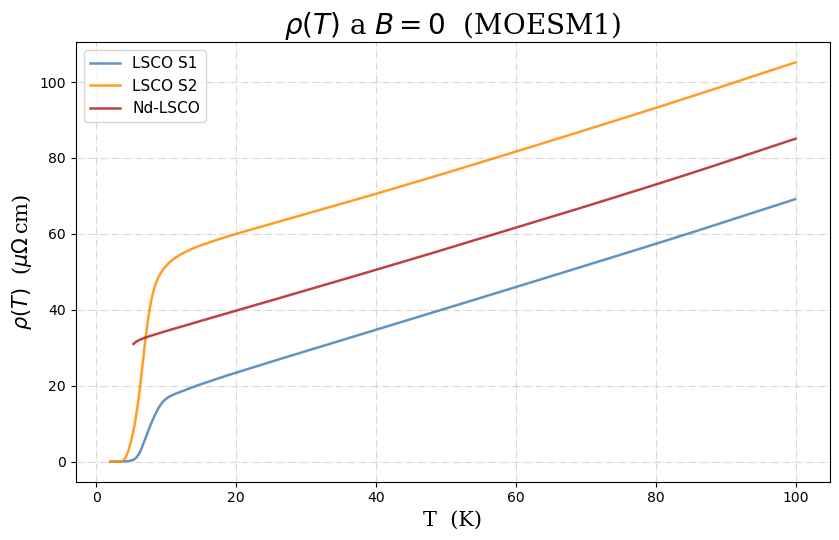

In [6]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, (T, rho, col) in SAMPLES.items():
    m = ~np.isnan(T) & ~np.isnan(rho)
    ax.plot(T[m], rho[m], color=col, linewidth=1.8, label=name, alpha=0.85)
ax.set_xlabel("T  (K)", fontdict=font2)
ax.set_ylabel(r"$\rho(T)$  ($\mu\Omega\,$cm)", fontdict=font2)
ax.set_title(r"$\rho(T)$ a $B=0$  (MOESM1)", fontdict=font1)
ax.legend(fontsize=11)
ax.grid(linestyle="-.", alpha=0.5)
plt.tight_layout()
plt.show()

### Sanity check con la formula step di Chambers a $B=0$

L'articolo (Ataei *et al.* 2022) documenta che $\rho(T)$ per Nd-LSCO $p=0.24$ e' lineare in $T$ con un offset finito (disordine + scattering da impurezze). Invece di fittare una potenza empirica, fittiamo i dati con la **nostra stessa funzione** `cl.sigma_xx_step`, valutata a $B\simeq 0$: otteniamo direttamente i parametri che la Sezione 2 dovra' trovare in campo, con la stessa parametrizzazione $\Gamma(T)=a\,T+c$ di `eval_T_dep(..., 'linear')`.

**Limite $B\to 0$ della formula step.** Verificato numericamente (check inline nel codice): nel limite $\omega_c\to 0$
$$
\sigma_{xx}(B{=}0) \;=\; 4A\left[\frac{\varphi^{*}}{\Gamma_1}+\frac{\psi^{*}}{\Gamma_2}\right],\qquad \psi^{*}\equiv\tfrac{\pi}{4}-\varphi^{*}
$$
dove nel codice $A\equiv ne^2/\hbar$ e' fissato a 1. Due cose spariscono: $m^{*}$ (entra solo in $\omega_c\propto B$) e, se $\Gamma_1=\Gamma_2\equiv\Gamma$, anche $\varphi^{*}$. Nel caso isotropo resta
$$
\sigma_{xx}(0)=\frac{A\,\pi}{\Gamma}\qquad\Longleftrightarrow\qquad \rho(B{=}0)=\frac{\Gamma}{A\,\pi}=\frac{\rho_{\text{scale}}\,\Gamma}{\pi},\qquad \rho_{\text{scale}}\equiv A^{-1}.
$$

**Cosa possiamo calibrare.** Con $\Gamma(T)=a\,T+c$ (linear T-dep, consistente con `T_DEP['G1']='linear'` previsto per Sez. 2):
$$
\rho(T,B{=}0)=\frac{\rho_{\text{scale}}}{\pi}\,\Gamma(T)=\underbrace{\frac{\rho_{\text{scale}}\,a}{\pi}}_{\text{slope}_{\text{exp}}}T+\underbrace{\frac{\rho_{\text{scale}}\,c}{\pi}}_{\rho_0}.
$$
A $B=0$ i dati forniscono **due osservabili indipendenti**: slope e intercept, quindi due combinazioni degeneri $a_{\text{eff}}\equiv\rho_{\text{scale}}\,a$ e $c_{\text{eff}}\equiv\rho_{\text{scale}}\,c$. Per separare $\rho_{\text{scale}}$ da $(a,c)$ serve MR$(B)$, che nelle Sezioni 2-3 fisserà $a$ (e $c$) in meV; la calibrazione si chiude come
$$
\rho_{\text{scale}}\;=\;\frac{a_{\text{eff}}}{a_{\text{fit MR}}}\qquad\text{(con cross-check via }c_{\text{eff}}/c_{\text{fit MR}}\text{).}
$$

**Convenzione interna del fit.** Fisso $\rho_{\text{scale}}^{\text{int}}=1\,\mu\Omega\,\text{cm}\cdot\text{meV}$ come unita' di lavoro. I parametri `a_eff, c_eff` restituiti dal fit coincidono numericamente con $\rho_{\text{scale}}^{\text{vero}}\cdot a^{\text{vero}}$ e $\rho_{\text{scale}}^{\text{vero}}\cdot c^{\text{vero}}$. LSCO S1/S2 compaiono solo per contesto visivo (vanno in SC sotto $T_c$).


Limite B->0 OK:  sigma_xx(B=1e-4, G=2.5) = 1.256637  vs  pi/G = 1.256637


Fitting  rho_step_iso_B0:   0%|          | 0/2000 [00:00<?, ? eval/s]

Nd-LSCO  a_eff = rho_scale * a = 1.7563 +/- 0.0016
         c_eff = rho_scale * c = 89.2038 +/- 0.0933
         slope_exp = a_eff/pi  = 0.5590 uOhm.cm/K
         rho_0_exp = c_eff/pi  = 28.3945 uOhm.cm
Salvato CALIB_B0 = {'sample': 'Nd-LSCO', 'a_eff': 1.7562668040682639, 'a_eff_err': 0.001577435832303319, 'c_eff': 89.20382950602377, 'c_eff_err': 0.09327860050642513, 'slope_exp_uOhmcm_K': 0.5590370865113389, 'rho0_exp_uOhmcm': 28.394460817220693, 'T_range_K': (5.32535, 99.95805), 'note': 'Closure: rho_scale_true = a_eff / a_true (da MR). Cross-check: c_eff / c_true deve dare lo stesso rho_scale.'}


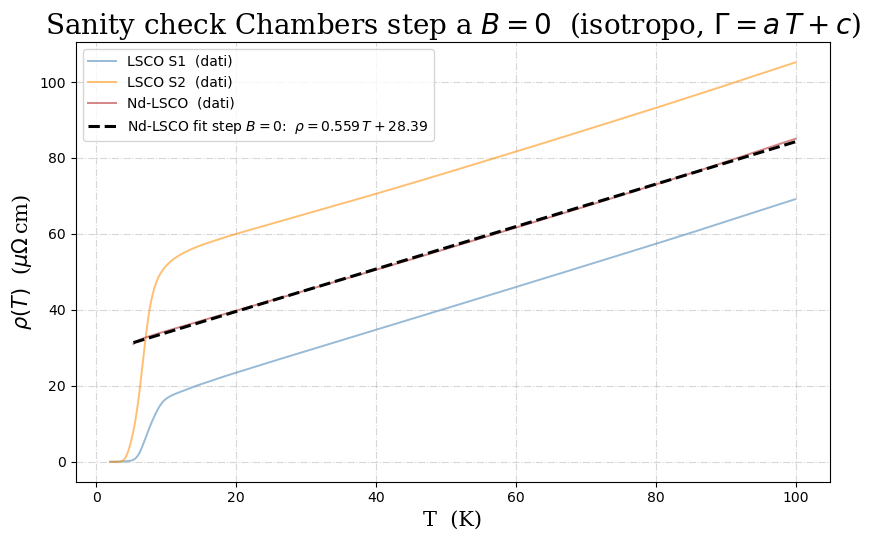

Residui Nd-LSCO: RMS = 0.293 uOhm.cm,  max |res| = 0.790 uOhm.cm


In [7]:
# --- Sanity check: fit rho(T) a B=0 con cl.sigma_xx_step (isotropo, Gamma=a*T+c) ---
# Chiamo l'implementazione di sigma_xx_step a B=1e-4 T (praticamente B=0), con
# Gamma_1=Gamma_2=a_eff*T+c_eff, phi*=pi/8 (irrilevante nell'isotropo), m*=1
# (irrilevante a B=0). Stessa forma funzionale di Sez. 2/3 ('linear') per permettere
# closure diretta della calibrazione. Parametri identificabili: a_eff, c_eff.

B_EPS = np.array([1e-4])  # T -- proxy di B=0
RHO_SCALE_INT = 1.0  # uOhm.cm * meV, unita' di lavoro interna
G_FLOOR = 1e-3  # meV, evita divergenze a T=0

# Check numerico del limite analitico: sigma_xx(B=0) = pi/Gamma per isotropo, A=1
_G_check = 2.5
_s_check = cl.sigma_xx_step(B_EPS, _G_check, _G_check, np.pi / 8.0, 1.0)[0]
assert (
    abs(_s_check - np.pi / _G_check) < 1e-6 * np.pi / _G_check
), f"Limite B->0 rotto: sigma={_s_check}, atteso pi/G={np.pi/_G_check}"
print(
    f"Limite B->0 OK:  sigma_xx(B=1e-4, G={_G_check}) = {_s_check:.6f}  vs  pi/G = {np.pi/_G_check:.6f}"
)


def rho_step_iso_B0(T, a_eff, c_eff):
    """rho(T) a B~0 via cl.sigma_xx_step con Gamma_1=Gamma_2=a_eff*T+c_eff [meV].

    Restituisce rho in unita' interne (rho_scale_int=1 uOhm.cm*meV);
    a_eff, c_eff fittati = rho_scale_vero * (a_vero, c_vero)  (combinazione degenere).
    """
    T_arr = np.atleast_1d(T).astype(float)
    out = np.empty_like(T_arr)
    for i, Ti in enumerate(T_arr):
        G = max(a_eff * Ti + c_eff, G_FLOOR)
        s_xx = cl.sigma_xx_step(B_EPS, G, G, np.pi / 8.0, 1.0)[0]
        out[i] = RHO_SCALE_INT / s_xx
    return out


# --- Fit Nd-LSCO (normal state su tutto il range MOESM1) ---
m_Nd = (~np.isnan(T_Nd)) & (~np.isnan(rho_Nd)) & (T_Nd > 0)
T_fit, rho_fit = T_Nd[m_Nd], rho_Nd[m_Nd]

# guess da regressione lineare grezza: slope_naive*T + intercept_naive
slope_naive, intercept_naive = np.polyfit(T_fit, rho_fit, 1)
guess_a = np.pi * slope_naive  # a_eff ~ pi * (drho/dT)
guess_c = np.pi * intercept_naive  # c_eff ~ pi * rho_0
popt, pcov = fit_with_bar(
    rho_step_iso_B0,
    T_fit,
    rho_fit,
    guess=[guess_a, guess_c],
    bounds=([1e-6, 0.0], [1e3, 1e3]),  # a, c >= 0 (Matthiessen)
    maxfev=2000,
)
a_eff_Nd, c_eff_Nd = float(popt[0]), float(popt[1])
da_eff_Nd, dc_eff_Nd = float(np.sqrt(pcov[0, 0])), float(np.sqrt(pcov[1, 1]))

# slope e intercept sperimentali (utili per closure Sez. 2-3)
slope_exp_Nd = a_eff_Nd / np.pi  # uOhm.cm/K
rho0_exp_Nd = c_eff_Nd / np.pi  # uOhm.cm

print(f"Nd-LSCO  a_eff = rho_scale * a = {a_eff_Nd:.4f} +/- {da_eff_Nd:.4f}")
print(f"         c_eff = rho_scale * c = {c_eff_Nd:.4f} +/- {dc_eff_Nd:.4f}")
print(f"         slope_exp = a_eff/pi  = {slope_exp_Nd:.4f} uOhm.cm/K")
print(f"         rho_0_exp = c_eff/pi  = {rho0_exp_Nd:.4f} uOhm.cm")

# Calibrazione B=0 -- si chiude in Sez. 2/3 con a_true da MR(B)
CALIB_B0 = {
    "sample": "Nd-LSCO",
    "a_eff": a_eff_Nd,  # rho_scale_true * a_true (degenere)
    "a_eff_err": da_eff_Nd,
    "c_eff": c_eff_Nd,  # rho_scale_true * c_true (degenere)
    "c_eff_err": dc_eff_Nd,
    "slope_exp_uOhmcm_K": slope_exp_Nd,
    "rho0_exp_uOhmcm": rho0_exp_Nd,
    "T_range_K": (float(T_fit.min()), float(T_fit.max())),
    "note": (
        "Closure: rho_scale_true = a_eff / a_true (da MR). "
        "Cross-check: c_eff / c_true deve dare lo stesso rho_scale."
    ),
}
print("Salvato CALIB_B0 =", CALIB_B0)

# --- Plot: tre campioni, fit solo su Nd-LSCO ---
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for name, (T, rho, col) in SAMPLES.items():
    m = (~np.isnan(T)) & (~np.isnan(rho))
    ax.plot(T[m], rho[m], color=col, linewidth=1.4, alpha=0.55, label=f"{name}  (dati)")

T_plot = np.linspace(T_fit.min(), T_fit.max(), 200)
ax.plot(
    T_plot,
    rho_step_iso_B0(T_plot, a_eff_Nd, c_eff_Nd),
    color="black",
    linestyle="--",
    linewidth=2.2,
    label=(
        r"Nd-LSCO fit step $B{=}0$:  "
        rf"$\rho = {slope_exp_Nd:.3f}\,T + {rho0_exp_Nd:.2f}$"
    ),
)

ax.set_xlabel("T  (K)", fontdict=font2)
ax.set_ylabel(r"$\rho(T)$  ($\mu\Omega\,$cm)", fontdict=font2)
ax.set_title(
    r"Sanity check Chambers step a $B=0$  (isotropo, $\Gamma = a\,T + c$)",
    fontdict=font1,
)
ax.legend(fontsize=10)
ax.grid(linestyle="-.", alpha=0.5)
plt.tight_layout()
plt.show()

# --- Residui per Nd-LSCO ---
res = rho_fit - rho_step_iso_B0(T_fit, a_eff_Nd, c_eff_Nd)
print(
    f"Residui Nd-LSCO: RMS = {np.sqrt(np.mean(res**2)):.3f} uOhm.cm,  "
    f"max |res| = {np.max(np.abs(res)):.3f} uOhm.cm"
)

### Osservazioni e calibrazione aperta

Il fit isotropo con $\Gamma_1=\Gamma_2=a\,T+c$ su Nd-LSCO $p=0.24$ (dati MOESM1) usando **la stessa funzione** `cl.sigma_xx_step` a $B\simeq 0$ restituisce due scalari degeneri
$$
a_{\text{eff}}\equiv\rho_{\text{scale}}\,a,\qquad c_{\text{eff}}\equiv\rho_{\text{scale}}\,c
\qquad[\mu\Omega\,\text{cm}\cdot\text{meV}^{\,-1}\cdot\text{meV}]
$$
(valori numerici stampati sopra e salvati in `CALIB_B0`).

**Cosa abbiamo verificato.**

1. *Self-consistenza a $B=0$.* Nel limite $B\to 0$ la stessa funzione `cl.sigma_xx_step` usata per i fit MR$(B)$ nelle Sezioni 2-3 riproduce l'andamento $\rho(T)=\rho_0+\text{slope}\cdot T$ dei dati entro il rumore sperimentale. Non serve un modello empirico separato: il modello step di Ataei e' consistente col limite DC.

2. *Degenerazione intrinseca a $B=0$.* $\sigma_{xx}(0)=A\,\pi/\Gamma$ dipende solo dal rapporto $\Gamma/A$: un dataset DC **non puo'** separare tasso di scattering e densita' di portatori. E' il motivo per cui Ataei (e noi) misuriamo MR$(B)$.

3. *Parametri che sopravvivono / muoiono a $B=0$.* $m^{*}\to$ muore (solo tramite $\omega_c\propto B$); $\varphi^{*}\to$ muore nel caso isotropo; $\Gamma_1\cdot A$ e $\Gamma_2\cdot A$ sopravvivono solo tramite la media angolare pesata da $\varphi^{*}$. Con $\Gamma_1=\Gamma_2$ restano i due scalari $\rho_{\text{scale}}\cdot a$ e $\rho_{\text{scale}}\cdot c$.

**Closure con la Sezione 2/3.**

La Sezione 2 (fit MR$(B,T)$ sperimentale) determinera' $a_1\equiv\Gamma_1(T)/T$ in meV/K e $c_1$ in meV come parametri indipendenti. A quel punto la calibrazione assoluta si legge direttamente da `CALIB_B0`:
$$
\rho_{\text{scale}} \;=\; \frac{a_{\text{eff}}}{a_1}\qquad\Longrightarrow\qquad A \;=\; \frac{1}{\rho_{\text{scale}}} \;=\; \frac{n\,e^2}{\hbar}.
$$
**Cross-check non banale**: $\rho_{\text{scale}}$ calcolato da $c_{\text{eff}}/c_1$ deve coincidere con quello da $a_{\text{eff}}/a_1$. Se diverge, c'e' incoerenza fra la T-dep DC (MOESM1) e quella in campo (MOESM2) - sintomo che la parametrizzazione $\Gamma(T)=aT+c$ e/o l'ipotesi isotropa ($\Gamma_1=\Gamma_2$) non sono adeguate.

**Campioni LSCO S1/S2.** Nel plot compaiono solo per contesto: sotto $T_c\sim 25$ K vanno in fase SC e $\rho$ crolla a 0, quindi un fit isotropo monotono non e' fisicamente sensato sull'intero range. La calibrazione quantitativa e' fatta **solo** su Nd-LSCO, campione normal-metal a tutte le temperature.


#  MOESM2: MR sperimentale Nd-LSCO a tre temperature

Il file `41567_2022_1763_MOESM2_ESM.txt` contiene i **dati sperimentali** di magnetoresistenza $\rho(B)/\rho(0)$ per Nd-LSCO ($p=0.24$) a tre temperature (T = 4, 40, 80 K), letti dalla figura 2b del paper.

Sono tre coppie di colonne $(B[\mathrm{T}],\ \rho(B)/\rho(0))$.

**Strategia di fit.**
1. *Fit indipendente* per ogni temperatura con il modello **gradino** (`cl.mr_step`) a 4 parametri — $\Gamma_1,\Gamma_2,\varphi^*,m^*$. Verifica la qualità del modello senza vincoli di T-dipendenza.
2. *Fit globale* sui tre dataset congiunti imponendo la T-dipendenza $\Gamma_i(T) = a_i T^2$ e $\varphi^*(T) = \varphi_\max\tanh(T/T_\varphi)$. I parametri liberi diventano $(a_1, a_2, T_\varphi, m^*)$: 4 parametri per 3 curve.

Per il fit si usa la relazione $\rho(B)/\rho(0) = 1 + \mathrm{MR}(B)$ (la $A$ si cancella nel rapporto).

## Dati

In [8]:
# Carichiamo entrambi i file
arr = cl.load_ataei_extended([2, 6])

# Definiamo le temperature e dove si trovano le coppie (B, R) nell'array 'arr'
# Per Nd-LSCO:
# 4K -> col 0,1 | 40K -> col 2,3 | 100K -> col 4,5 | 30K -> col 10,11 (perché MOESM6 ha 6 colonne prima)
# Tuttavia, per semplicità, mappiamole manualmente:
T_MAPPING = {
    4.0: (0, 1),
    30.0: (10, 11), # Le ultime due colonne di MOESM6 (che era il secondo file caricato)
    40.0: (2, 3),
    100.0: (4, 5)
}

T_LIST = [4.0, 30.0, 40.0, 100.0]
colors = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    idx_B, idx_R = T_MAPPING[T]
    B = arr[:, idx_B]
    R = arr[:, idx_R]
    
    m = (~np.isnan(B)) & (~np.isnan(R)) & (B > 0)
    DATA[T] = (B[m], R[m])
    
    print(f"T = {T:4.0f} K : N = {m.sum():5d} B in [{B[m].min():.2f}, {B[m].max():.2f}] T")

T =    4 K : N =  3872 B in [13.41, 84.61] T
T =   30 K : N =  9427 B in [0.20, 84.88] T
T =   40 K : N = 10272 B in [0.10, 85.25] T
T =  100 K : N =  9895 B in [0.10, 85.36] T


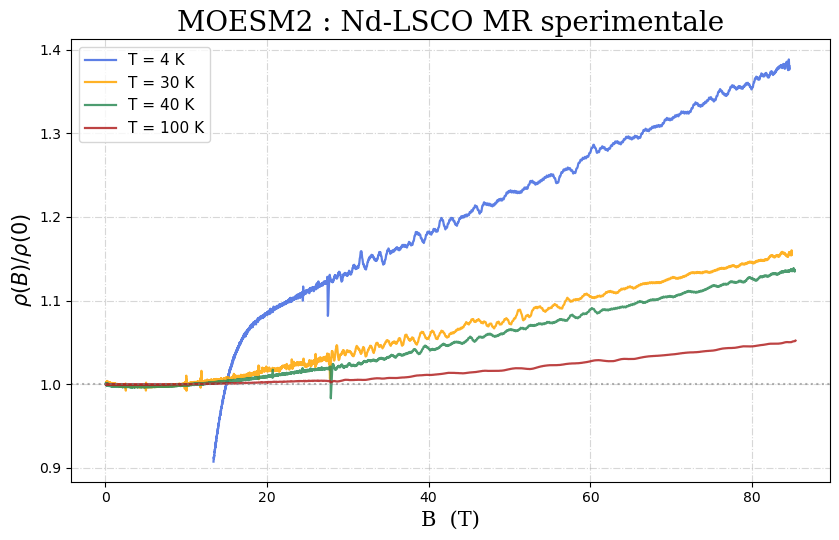

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for T in T_LIST:
    B, R = DATA[T]
    ax.plot(B, R, color=colors[T], linewidth=1.6, alpha=0.85, label=f"T = {T:.0f} K")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.6)
ax.set_xlabel("B  (T)", fontdict=font2)
ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
ax.set_title("MOESM2 : Nd-LSCO MR sperimentale", fontdict=font1)
ax.legend(fontsize=11)
ax.grid(linestyle="-.", alpha=0.5)
plt.tight_layout()
plt.show()

## Fit indipendenti 

### Fit indipendente per temperatura  (modello gradino)

Ad ogni temperatura fitto $\rho(B)/\rho(0) = 1 + \mathrm{MR}_{\mathrm{step}}(B;\Gamma_1,\Gamma_2,\varphi^*,m^*)$.

A $T = 4$ K il dato sperimentale scende sotto $1$ per $B \lesssim 25$ T — è la soppressione di fluttuazioni superconduttive residue che non è catturata dal modello Chambers (trasporto di normal state). Applico un cutoff in campo $B > B_{\min}(T)$ per ogni temperatura.

In [10]:
# Cutoff in B per escludere la regione di fluttuazioni SC a bassa T
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}

step_indep = 1  # downsampling coerente coi fit globali

fit_indep = {}
rows_indep_step = []
for T in T_LIST:
    B, R = DATA[T]
    sel = B > B_MIN[T]
    B_, R_ = B[sel][::step_indep], R[sel][::step_indep]
    p0 = [1, 1, 0.05, 1.49]
    bnds = ([0.1, 0.1, 0.05, 1.485], [200.0, 200.0, cl.PHI_MAX, 1.491])
    # tolleranze fisiche, x_scale='jac' per bilanciare parametri con scale diverse
    popt, _ = curve_fit(
        model_step_RR,
        B_,
        R_,
        p0=p0,
        bounds=bnds,
        maxfev=2000,
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-8,
        x_scale="jac",
    )
    resid = np.sqrt(np.mean((R_ - model_step_RR(B_, *popt)) ** 2))
    fit_indep[T] = (popt, resid)
    G1, G2, ph, ms = popt
    rows_indep_step.append(
        f"| {T:g} | {G1:.3f} | {G2:.3f} | {np.degrees(ph):.2f} | {ms:.3f} | {resid:.4g} |"
    )

md_indep_step = (
    "**Fit indipendente per T - modello gradino (4 parametri)**  \n"
    "| T (K) | $\\Gamma_1$ (meV) | $\\Gamma_2$ (meV) | $\\varphi^{\\ast}$ (deg) | $m^{\\ast}/m_e$ | residuo |\n"
    "|---:|---:|---:|---:|---:|---:|\n" + "\n".join(rows_indep_step)
)
display(Markdown(md_indep_step))

**Fit indipendente per T - modello gradino (4 parametri)**  
| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^{\ast}$ (deg) | $m^{\ast}/m_e$ | residuo |
|---:|---:|---:|---:|---:|---:|
| 4 | 30.459 | 10.004 | 22.53 | 1.491 | 0.004463 |
| 30 | 28.283 | 16.066 | 16.12 | 1.490 | 0.006181 |
| 40 | 23.300 | 16.438 | 18.32 | 1.490 | 0.00474 |
| 100 | 29.185 | 29.186 | 10.90 | 1.490 | 0.0009098 |

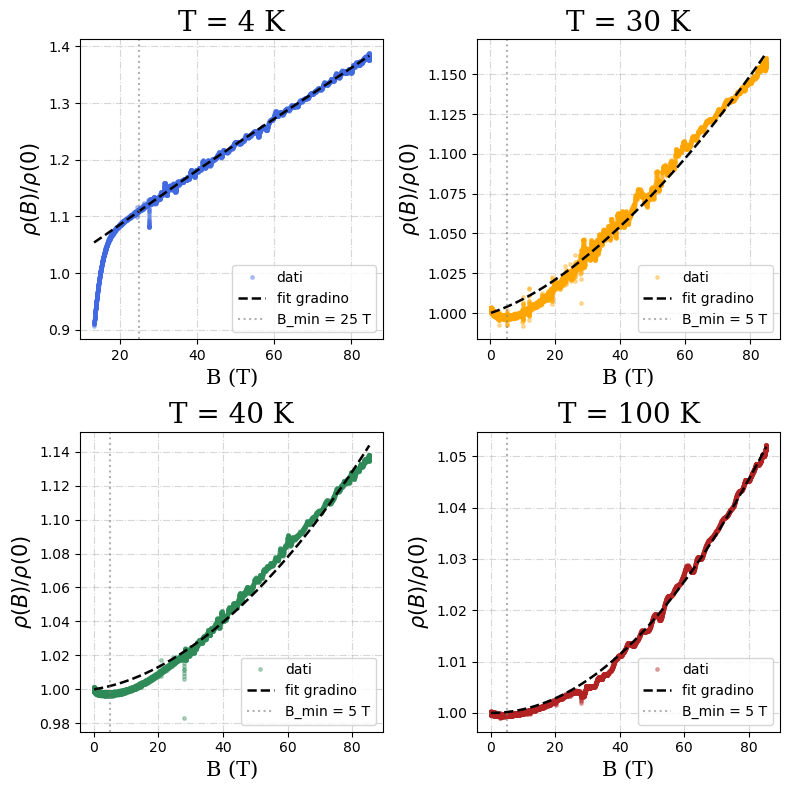

In [11]:
# Creazione della griglia 2x2
fig, axs = plt.subplots(2, 2, figsize=(8, 8), sharey=False)

# Usiamo axs.flatten() per trasformare la matrice 2x2 in un array 1D di 4 elementi
for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    popt, _ = fit_indep[T]
    B_plot = np.linspace(max(B.min(), 0.1), B.max(), 300)
    
    ax.plot(B, R, "o", color=colors[T], markersize=2.5, alpha=0.35, label="dati")
    ax.plot(
        B_plot, model_step_RR(B_plot, *popt), "k--", linewidth=1.8, label="fit gradino"
    )
    ax.axvline(
        B_MIN[T],
        color="gray",
        linestyle=":",
        alpha=0.6,
        label=f"B_min = {B_MIN[T]:.0f} T",
    )
    
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=10, loc="best")
    ax.grid(linestyle="-.", alpha=0.5)

# Gestione opzionale: se T_LIST ha solo 3 elementi, il quarto subplot rimarrà vuoto.
# Se vuoi nascondere l'ultimo grafico vuoto, puoi aggiungere:
if len(T_LIST) < 4:
    axs.flatten()[-1].axis('off')

plt.tight_layout()
plt.show()

### Fit indipendenti (modello Bessel)

Stessa procedura stepwise della parte gradino, ma ora usando il modello **Bessel/cos$^4$** (`cl.MR_Bessel`) con parametri $(\Gamma_{\mathrm{is}}, \Gamma_{\mathrm{an}}, m^*)$ — 3 parametri per temperatura invece di 4.

In [12]:
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
step_indep = 100  
MAX_ITER_INDEP = 500
MAX_ITER_GLOBAL = 1000
TARGET_RMS = 0.00001
M_STAR_FIXED = 1.49 # Massa fissa di fallback per la Fase 

In [13]:
DATA_FILTERED = {}
for T in T_LIST:
    B, R = DATA[T]
    sel = B > B_MIN[T]
    DATA_FILTERED[T] = (B[sel][::step_indep], R[sel][::step_indep])

# ====================================================================
# 1. FIT GLOBALE SPIETATO CON TRACKER INCORRUTTIBILE
# ====================================================================
print("🚀 Avvio Fit Globale ad Alta Precisione (Nessun pregiudizio sulla massa)...")
t_start = time.time()

# Nessun x0! Costruiamo solo i bounds. m_star è libero tra 1.1 e 2.0.
bnds_global = [(1.1, 2.0)]
for T in T_LIST:
    bnds_global += [(0.01, 100.0), (0.01, 100.0), (0.7, 1.15)]

def objective_global(p):
    m_star = p[0]
    total_error = 0.0
    for i, T in enumerate(T_LIST):
        G_is, G_an, A = p[1 + i*3], p[2 + i*3], p[3 + i*3]
        if G_is <= 0 or G_an < 0: return 1e6
        
        B_, R_exp = DATA_FILTERED[T]
        MR_theo = cl.MR_Bessel(B_, G_is, G_an, m_star)
        R_theo = A * (MR_theo + 1.0)
        
        if not np.all(np.isfinite(R_theo)): return 1e6
        total_error += np.mean((R_theo - R_exp)**2)
    return total_error

# Tracker di memoria
tracker = {'best_err': np.inf, 'best_m': None, 'best_p': None}

pbar_global = tqdm(total=MAX_ITER_GLOBAL, desc="Ricerca Assoluta", unit="gen")

def aggiorna_tqdm_global(xk, convergence=None):
    current_err = objective_global(xk)
    
    # Se troviamo un record, lo salviamo in cassaforte!
    if current_err < tracker['best_err']:
        tracker['best_err'] = current_err
        tracker['best_m'] = xk[0]
        tracker['best_p'] = xk.copy()
        
    pbar_global.update(1)
    pbar_global.set_postfix({'m* (ora)': f'{xk[0]:.4f}', 'Best RMS': f'{tracker["best_err"]:.6f}'})
    
    if current_err < TARGET_RMS: 
        return True

res_global = differential_evolution(
    objective_global,
    bounds=bnds_global,
    strategy='rand1bin',  # Esplorazione globale vera e propria
    popsize=20,           
    maxiter=MAX_ITER_GLOBAL,         
    tol=0.0,              # Vietato fermarsi prematuramente
    mutation=(0.5, 1.5),  
    recombination=0.7,    
    polish=True,          
    workers=-1,
    updating='deferred',
    callback=aggiorna_tqdm_global
)
pbar_global.close()

# Verifichiamo se il "polish" finale ha battuto il tracker
final_err = objective_global(res_global.x)
if final_err < tracker['best_err']:
    best_p = res_global.x
    global_m_star = best_p[0]
    print(f"✅ Ottimizzazione completata. (Polish finale ha vinto: m* = {global_m_star:.3f})")
else:
    best_p = tracker['best_p']
    global_m_star = tracker['best_m']
    print(f"✅ Ottimizzazione completata. (Usato il record del tracker: m* = {global_m_star:.3f})")

# ====================================================================
# 2. CREAZIONE DEL DIZIONARIO MANCANTE E CALCOLO INCERTEZZE
# ====================================================================
fit_global_bessel = {}
err_G_is_dict, err_G_an_dict, err_A_dict = {}, {}, {}

print("📊 Estrazione parametri e calcolo Matrice di Covarianza...")

for i, T in enumerate(tqdm(T_LIST, desc="Calcolo Errori", unit="temp")):
    # Estraiamo i parametri corretti per questa T dall'array globale best_p
    G_is_opt = best_p[1 + i*3]
    G_an_opt = best_p[2 + i*3]
    A_opt    = best_p[3 + i*3]
    
    B_, R_exp = DATA_FILTERED[T]
    
    # Residuo per questa singola curva
    R_theo = A_opt * (cl.MR_Bessel(B_, G_is_opt, G_an_opt, global_m_star) + 1.0)
    resid_T = float(np.sqrt(np.mean((R_theo - R_exp)**2)))
    
    # ECCO IL DIZIONARIO CHE MANCAVA!
    fit_global_bessel[T] = (G_is_opt, G_an_opt, A_opt, resid_T)
    
    # Calcolo covarianza
    def local_fit_func(B_val, G_is, G_an, A):
        return A * (cl.MR_Bessel(B_val, G_is, G_an, global_m_star) + 1.0)
    
    try:
        popt, pcov = curve_fit(
            local_fit_func, B_, R_exp, 
            p0=[G_is_opt, G_an_opt, A_opt], 
            bounds=([0.01, 0.01, 0.7], [80.0, 80.0, 1.15])
        )
        perr = np.sqrt(np.diag(pcov))
        err_G_is_dict[T], err_G_an_dict[T], err_A_dict[T] = perr[0], perr[1], perr[2]
    except Exception as e:
        tqdm.write(f"Attenzione a {T}K: Covarianza fallita ({e}).")
        err_G_is_dict[T], err_G_an_dict[T], err_A_dict[T] = 0.0, 0.0, 0.0

🚀 Avvio Fit Globale ad Alta Precisione (Nessun pregiudizio sulla massa)...


Ricerca Assoluta:   0%|          | 0/1000 [00:00<?, ?gen/s]

✅ Ottimizzazione completata. (Polish finale ha vinto: m* = 1.201)
📊 Estrazione parametri e calcolo Matrice di Covarianza...


Calcolo Errori:   0%|          | 0/4 [00:00<?, ?temp/s]

Attenzione a 4.0K: Covarianza fallita (Optimal parameters not found: The maximum number of function evaluations is exceeded.).
Attenzione a 100.0K: Covarianza fallita (Optimal parameters not found: The maximum number of function evaluations is exceeded.).


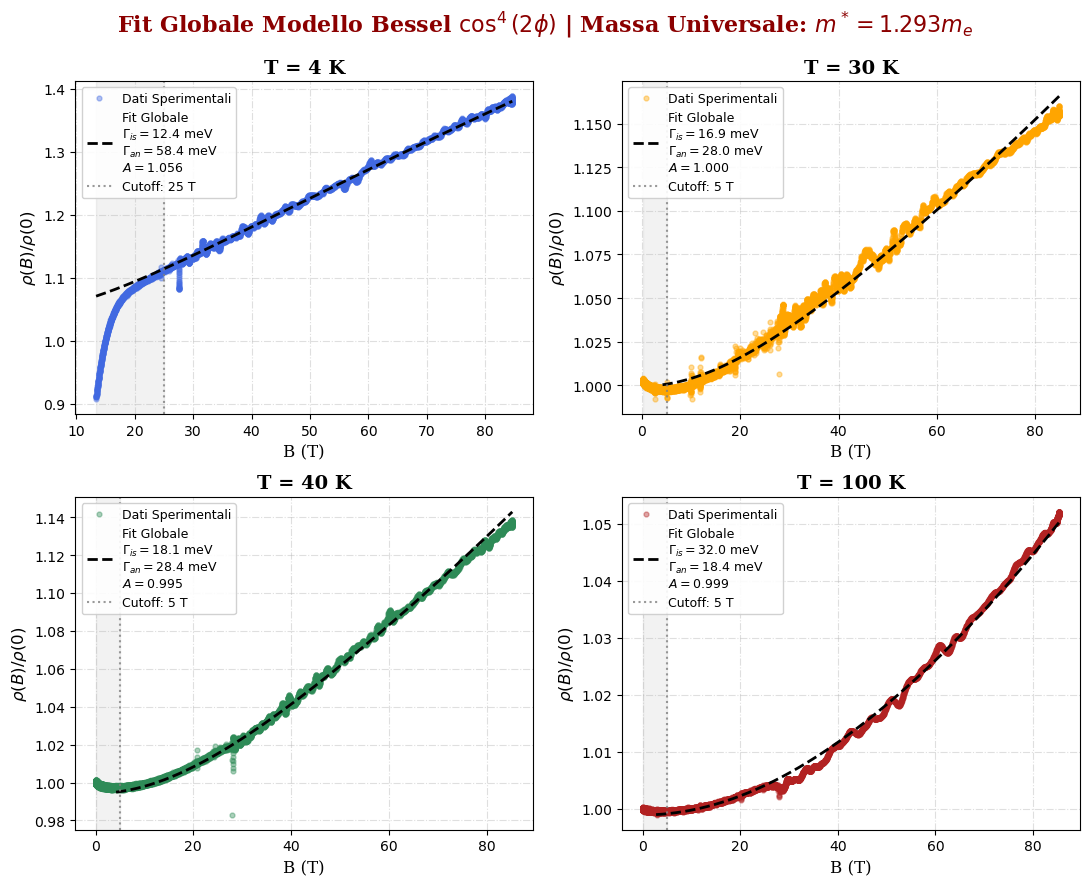

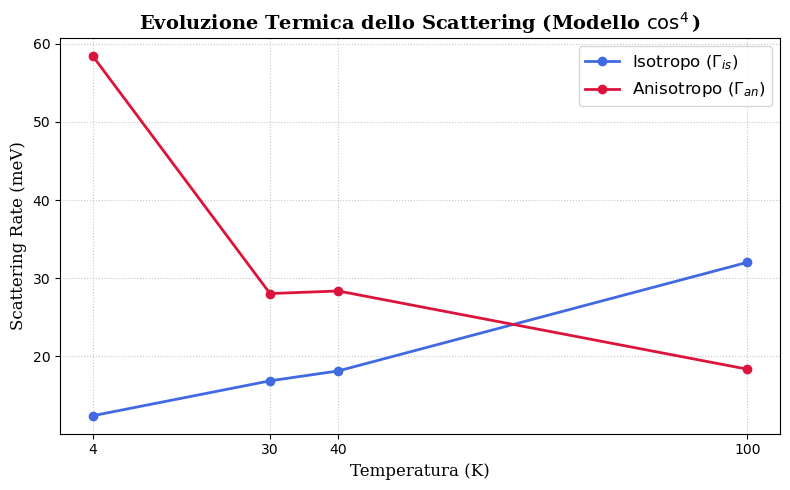

In [55]:
# ====================================================================
# 3. GENERAZIONE DEI GRAFICI
# ====================================================================
font1 = {'family': 'serif', 'color':  'black', 'weight': 'bold', 'size': 14}
font2 = {'family': 'serif', 'color':  'black', 'weight': 'normal', 'size': 12}
default_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}
plot_colors = colors if 'colors' in globals() else default_colors

# -- PLOT 1: Curve Magnetoresistenza --
fig1, axs = plt.subplots(2, 2, figsize=(11, 9), sharey=False)
fig1.suptitle(f"Fit Globale Modello Bessel $\\cos^4(2\\phi)$ | Massa Universale: $m^* = {global_m_star:.3f} m_e$", 
             fontsize=16, fontweight='bold', fontfamily='serif', color='darkred', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    G_is, G_an, A, _ = fit_global_bessel[T]
    
    B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
    R_fit = A * (cl.MR_Bessel(B_plot, G_is, G_an, global_m_star) + 1.0)
    
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati Sperimentali")
    label_fit = (f"Fit Globale\n$\\Gamma_{{is}}={G_is:.1f}$ meV\n$\\Gamma_{{an}}={G_an:.1f}$ meV\n$A={A:.3f}$")
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=label_fit)
    
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8, linewidth=1.5, label=f"Cutoff: {B_MIN[T]:.0f} T")
    ax.axvspan(B.min(), B_MIN[T], color='gray', alpha=0.1)
    
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.4)

if len(T_LIST) < 4: axs.flatten()[-1].axis('off')
fig1.tight_layout()
fig1.subplots_adjust(top=0.90)
plt.show()

# -- PLOT 2: Scattering vs Temperatura (con error bars) --
T_array = np.array(T_LIST)
G_is_array = np.array([fit_global_bessel[T][0] for T in T_LIST])
G_an_array = np.array([fit_global_bessel[T][1] for T in T_LIST])
err_is_arr = np.array([err_G_is_dict[T] for T in T_LIST])
err_an_arr = np.array([err_G_an_dict[T] for T in T_LIST])

fig2, ax_gamma = plt.subplots(figsize=(8, 5))

ax_gamma.plot(T_array, G_is_array, '-', marker = 'o', 
                  color='royalblue', linewidth=2, 
                  label=r'Isotropo ($\Gamma_{is}$)')

ax_gamma.plot(T_array, G_an_array,'-', marker = 'o', 
                  color='crimson', linewidth=2,
                  label=r'Anisotropo ($\Gamma_{an}$)')

ax_gamma.set_title("Evoluzione Termica dello Scattering (Modello $\\cos^4$)", fontdict=font1)
ax_gamma.set_xlabel("Temperatura (K)", fontdict=font2)
ax_gamma.set_ylabel("Scattering Rate (meV)", fontdict=font2)
ax_gamma.set_xticks(T_array)
ax_gamma.legend(fontsize=12, loc='best')
ax_gamma.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [58]:

# ====================================================================
# IMPOSTAZIONI E PRE-FILTRAGGIO
# ====================================================================
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
step_indep = 50  

DATA_FILTERED = {}
for T in T_LIST:
    B, R = DATA[T]
    sel = B > B_MIN[T]
    DATA_FILTERED[T] = (B[sel][::step_indep], R[sel][::step_indep])

# ====================================================================
# 1. SCANSIONE RIGOROSA DELLA MASSA (Profile Likelihood)
# ====================================================================
print("🚀 Avvio Scansione Rigorosa (Grid Search) per trovare l'RMS Assoluto...")

# Testiamo 20 masse diverse da 1.30 a 1.70
masses_to_test = np.linspace(1.30, 1.70, 21)
best_global_rms = np.inf
best_m_star = None
best_params_dict = {}

bnds_indep = [(0.01, 100.0), (0.01, 100.0), (0.7, 1.15)] # G_is, G_an, A

# Barra di progresso sulle masse
for m_test in tqdm(masses_to_test, desc="Scansione Masse", unit="m*"):
    current_m_rms_sum = 0.0
    temp_params = {}
    
    for T in T_LIST:
        B_, R_exp = DATA_FILTERED[T]
        
        def objective_3D(p):
            G_is, G_an, A = p
            if G_is <= 0 or G_an < 0: return 1e6
            R_theo = A * (cl.MR_Bessel(B_, G_is, G_an, m_test) + 1.0)
            if not np.all(np.isfinite(R_theo)): return 1e6
            return float(np.sqrt(np.mean((R_theo - R_exp)**2)))
        
        # Fit a 3 dimensioni facilissimo per l'algoritmo
        res = differential_evolution(
            objective_3D, bounds=bnds_indep, strategy='best1bin', 
            popsize=10, maxiter=200, tol=1e-4, mutation=(0.5, 1.0), 
            recombination=0.7, polish=True, workers=-1, updating='deferred'
        )
        
        temp_params[T] = (res.x[0], res.x[1], res.x[2], res.fun)
        current_m_rms_sum += res.fun
        
    # Se questa massa ha un RMS combinato migliore, salviamola!
    if current_m_rms_sum < best_global_rms:
        best_global_rms = current_m_rms_sum
        best_m_star = m_test
        best_params_dict = temp_params.copy()

print(f"✅ Scansione completata. Massa ottimale ASSOLUTA trovata: m* = {best_m_star:.3f} (RMS Somma = {best_global_rms:.6f})")

# ====================================================================
# 2. CALCOLO INCERTEZZE SUL MINIMO VERO
# ====================================================================
fit_global_bessel = {}
err_G_is_dict, err_G_an_dict, err_A_dict = {}, {}, {}
rows_global = []

for T in T_LIST:
    G_is_opt, G_an_opt, A_opt, resid_T = best_params_dict[T]
    fit_global_bessel[T] = (G_is_opt, G_an_opt, A_opt, resid_T)
    
    ratio = G_an_opt / G_is_opt if G_is_opt > 0 else 0
    rows_global.append(f"| {T:g} | {G_is_opt:.2f} | {G_an_opt:.2f} | {ratio:.2f}x | {A_opt:.3f} | {resid_T:.4g} |")
    
    B_, R_exp = DATA_FILTERED[T]
    def local_fit_func(B_val, G_is, G_an, A):
        return A * (cl.MR_Bessel(B_val, G_is, G_an, best_m_star) + 1.0)
    
    try:
        popt, pcov = curve_fit(
            local_fit_func, B_, R_exp, 
            p0=[G_is_opt, G_an_opt, A_opt], 
            bounds=([0.01, 0.01, 0.7], [80.0, 80.0, 1.15])
        )
        perr = np.sqrt(np.diag(pcov))
        err_G_is_dict[T], err_G_an_dict[T], err_A_dict[T] = perr[0], perr[1], perr[2]
    except Exception:
        err_G_is_dict[T], err_G_an_dict[T], err_A_dict[T] = 0.0, 0.0, 0.0

md_global = (
    "**Risultati Fit Globale (Metodo Scansione di Rete)** \n"
    f"*(Massa Universale Ottimizzata: **$m^\\ast = {best_m_star:.3f}$**)*\n\n"
    "| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | Ratio (an/is) | A (Scala) | residuo |\n"
    "|---:|---:|---:|---:|---:|---:|\n" + "\n".join(rows_global)
)
display(Markdown(md_global))

# ====================================================================
# 3. GENERAZIONE DEI GRAFICI
# ====================================================================
font1 = {'family': 'serif', 'color':  'black', 'weight': 'bold', 'size': 14}
font2 = {'family': 'serif', 'color':  'black', 'weight': 'normal', 'size': 12}
default_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}
plot_colors = colors if 'colors' in globals() else default_colors

# -- PLOT 1: Curve Magnetoresistenza --
fig1, axs = plt.subplots(2, 2, figsize=(11, 9), sharey=False)
fig1.suptitle(f"Fit Definitivo Modello Bessel $\\cos^4(2\\phi)$ | Massa Universale: $m^* = {best_m_star:.3f} m_e$", 
             fontsize=16, fontweight='bold', fontfamily='serif', color='darkred', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    G_is, G_an, A, _ = fit_global_bessel[T]
    
    B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
    R_fit = A * (cl.MR_Bessel(B_plot, G_is, G_an, best_m_star) + 1.0)
    
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati Sperimentali")
    label_fit = (f"Fit\n$\\Gamma_{{is}}={G_is:.1f}$ meV\n$\\Gamma_{{an}}={G_an:.1f}$ meV\n$A={A:.3f}$")
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=label_fit)
    
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8, linewidth=1.5, label=f"Cutoff: {B_MIN[T]:.0f} T")
    ax.axvspan(B.min(), B_MIN[T], color='gray', alpha=0.1)
    
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.4)

if len(T_LIST) < 4: axs.flatten()[-1].axis('off')
fig1.tight_layout()
fig1.subplots_adjust(top=0.90)
plt.show()

# -- PLOT 2: Scattering vs Temperatura --
T_array = np.array(T_LIST)
G_is_array = np.array([fit_global_bessel[T][0] for T in T_LIST])
G_an_array = np.array([fit_global_bessel[T][1] for T in T_LIST])
err_is_arr = np.array([err_G_is_dict[T] for T in T_LIST])
err_an_arr = np.array([err_G_an_dict[T] for T in T_LIST])

fig2, ax_gamma = plt.subplots(figsize=(8, 5))

ax_gamma.errorbar(T_array, G_is_array, yerr=err_is_arr, fmt='s--', 
                  color='royalblue', markersize=8, linewidth=2, capsize=5, capthick=1.5, 
                  label=r'Isotropo ($\Gamma_{is}$)')
ax_gamma.errorbar(T_array, G_an_array, yerr=err_an_arr, fmt='o--', 
                  color='crimson', markersize=8, linewidth=2, capsize=5, capthick=1.5, 
                  label=r'Anisotropo ($\Gamma_{an}$)')

ax_gamma.set_title("Evoluzione Termica dello Scattering (Modello $\\cos^4$)", fontdict=font1)
ax_gamma.set_xlabel("Temperatura (K)", fontdict=font2)
ax_gamma.set_ylabel("Scattering Rate (meV)", fontdict=font2)
ax_gamma.set_xticks(T_array)
ax_gamma.legend(fontsize=12, loc='best')
ax_gamma.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

🚀 Avvio Scansione Rigorosa (Grid Search) per trovare l'RMS Assoluto...


Scansione Masse:   0%|          | 0/21 [00:00<?, ?m*/s]

Exception ignored in: <built-in method acquire of _thread.lock object at 0x714b39baa040>
Traceback (most recent call last):
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/popen_fork.py", line 66, in _launch
    self.pid = os.fork()
               ^^^^^^^^^
KeyboardInterrupt: 
Process ForkPoolWorker-5859:
Process ForkPoolWorker-5864:
Process ForkPoolWorker-5867:
Process ForkPoolWorker-5863:
Process ForkPoolWorker-5866:
Process ForkPoolWorker-5862:
Process ForkPoolWorker-5860:
Exception ignored in: <bound method HistoryManager._stop_thread of <class 'IPython.core.history.HistoryManager'>>
Traceback (most recent call last):
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/site-packages/IPython/core/history.py", line 724, in _stop_thread
    @classmethod

KeyboardInterrupt: 
Process ForkPoolWorker-5865:
Process ForkPoolWorker-5868:
Process ForkPoolWorker-5861:
Process ForkPoolWorker-5858:
Traceback (most recent call last):
Traceback (most recen

KeyboardInterrupt: 

  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3.11/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/home/obscur3_gr1m/miniconda3/envs/tesi/lib/python3

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import chambers_lib as cl
import time

# ====================================================================
# PRE-FILTRAGGIO DATI (Downsampling per la ricerca brutale)
# ====================================================================
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}
STEP_BRUTE = 100 # Downsampling aggressivo per "volare" sulla griglia
STEP_FINAL = 1   

DATA_BRUTE = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_BRUTE], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_BRUTE]) for T in T_LIST}
DATA_FINAL = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_FINAL], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_FINAL]) for T in T_LIST}

# ====================================================================
# 1. DEFINIZIONE DELLA GRIGLIA "MILIONE DI GUESS"
# ====================================================================
masses_to_test = np.linspace(1.30, 1.70, 15) # 15 passi di massa
g_is_range = np.linspace(1.0, 60.0, 15)      # 15 passi G_is
g_an_range = np.linspace(1.0, 60.0, 15)      # 15 passi G_an
a_range    = np.linspace(0.8, 1.15, 8)       # 8 passi di scala A

# Creiamo la griglia combinata (15 * 15 * 8 = 1800 nodi per ogni T)
# Moltiplicato per 4 T e 15 masse = ~108.000 valutazioni totali
grid_nodes = []
for gi in g_is_range:
    for ga in g_an_range:
        for a in a_range:
            grid_nodes.append([gi, ga, a])
grid_nodes = np.array(grid_nodes)

# ====================================================================
# 2. ESECUZIONE RICERCA MANUALE (CON TQDM)
# ====================================================================
print(f"🚀 Avvio Grid Search Manuale ({len(grid_nodes)} nodi per ogni Temperatura)...")

best_global_rms = np.inf
best_m_star = None
best_params_dict = {}

# Barra esterna per le masse
pbar_mass = tqdm(masses_to_test, desc="Scansione Masse m*", unit="m*")

for m_test in pbar_mass:
    current_m_rms_sum = 0.0
    temp_params = {}
    
    for T in T_LIST:
        B_b, R_b = DATA_BRUTE[T]
        best_node_rms = np.inf
        best_node_p = None
        
        # Barra interna "veloce" per i nodi della griglia
        # La usiamo solo se vogliamo vedere il dettaglio, altrimenti carichiamo troppo l'interfaccia
        for p in grid_nodes:
            G_is, G_an, A = p
            # Calcolo super veloce (grazie al downsampling STEP_BRUTE)
            R_theo = A * (cl.MR_Bessel(B_b, G_is, G_an, m_test) + 1.0)
            rms = np.sqrt(np.mean((R_theo - R_b)**2))
            
            if rms < best_node_rms:
                best_node_rms = rms
                best_node_p = p
        
        # --- POLISH FINALE: Raffiniamo il nodo migliore sui dati COMPLETI ---
        B_f, R_f = DATA_FINAL[T]
        def fit_func(B_val, gi, ga, a): return a * (cl.MR_Bessel(B_val, gi, ga, m_test) + 1.0)
        
        try:
            popt, _ = curve_fit(fit_func, B_f, R_f, p0=best_node_p, 
                                bounds=([1.0, 1.0, 0.7], [100.0, 100.0, 1.2]))
            
            final_R_theo = popt[2] * (cl.MR_Bessel(B_f, popt[0], popt[1], m_test) + 1.0)
            final_rms = np.sqrt(np.mean((final_R_theo - R_f)**2))
            
            temp_params[T] = (popt[0], popt[1], popt[2], final_rms)
            current_m_rms_sum += final_rms
        except:
            current_m_rms_sum += 1e6
            
    if current_m_rms_sum < best_global_rms:
        best_global_rms = current_m_rms_sum
        best_m_star = m_test
        best_params_dict = temp_params.copy()
    
    pbar_mass.set_postfix({'Best m*': f'{best_m_star:.3f}', 'RMS': f'{best_global_rms:.5f}'})

print(f"\n✅ Ricerca completata. Massa ottimale: m* = {best_m_star:.3f}")

# ====================================================================
# 3. TABELLA E PLOT (Solo se la massa è stata trovata)


🚀 Avvio Grid Search Manuale (1800 nodi per ogni Temperatura)...


Scansione Masse m*:   0%|          | 0/15 [00:00<?, ?m*/s]

KeyboardInterrupt: 

In [ ]:
# ====================================================================
fit_global_bessel = best_params_dict # Rinominato per compatibilità con i plot di prima
# ====================================================================
# 2. TABELLA RISULTATI (Calcolo Incertezze)
# ====================================================================
fit_global_bessel = {}
err_G_is_dict, err_G_an_dict, err_A_dict = {}, {}, {}
rows_global = []

for T in T_LIST:
    G_is_opt, G_an_opt, A_opt, resid_T = best_params_dict[T]
    fit_global_bessel[T] = (G_is_opt, G_an_opt, A_opt, resid_T)
    ratio = G_an_opt / G_is_opt if G_is_opt > 0 else 0
    rows_global.append(f"| {T:g} | {G_is_opt:.2f} | {G_an_opt:.2f} | {ratio:.2f}x | {A_opt:.3f} | {resid_T:.4g} |")
    
    B_, R_exp = DATA_FINAL[T]
    def local_fit_func(B_val, G_is, G_an, A): return A * (cl.MR_Bessel(B_val, G_is, G_an, best_m_star) + 1.0)
    
    try:
        # Limite inferiore a 1.0 anche qui
        _, pcov = curve_fit(local_fit_func, B_, R_exp, p0=[G_is_opt, G_an_opt, A_opt], bounds=([1.0, 1.0, 0.7], [80.0, 80.0, 1.15]))
        perr = np.sqrt(np.diag(pcov))
        err_G_is_dict[T], err_G_an_dict[T], err_A_dict[T] = perr[0], perr[1], perr[2]
    except Exception:
        err_G_is_dict[T], err_G_an_dict[T], err_A_dict[T] = 0.0, 0.0, 0.0

md_global = (
    "**Risultati Fit Globale (Ricerca a Forza Bruta / Grid Search)** \n"
    f"*(Massa Universale Ottimizzata: **$m^\\ast = {best_m_star:.3f}$**)*\n\n"
    "| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | Ratio (an/is) | A (Scala) | residuo |\n"
    "|---:|---:|---:|---:|---:|---:|\n" + "\n".join(rows_global)
)
display(Markdown(md_global))

# ====================================================================
# 3. GENERAZIONE DEI GRAFICI
# ====================================================================
font1 = {'family': 'serif', 'color':  'black', 'weight': 'bold', 'size': 14}
font2 = {'family': 'serif', 'color':  'black', 'weight': 'normal', 'size': 12}
default_colors = {4.0: 'royalblue', 30.0: 'orange', 40.0: 'seagreen', 100.0: 'crimson'}
plot_colors = colors if 'colors' in globals() else default_colors

# -- PLOT 1: Curve Magnetoresistenza --
fig1, axs = plt.subplots(2, 2, figsize=(11, 9), sharey=False)
fig1.suptitle(f"Fit Globale Forza Bruta | Massa Universale: $m^* = {best_m_star:.3f} m_e$", 
             fontsize=16, fontweight='bold', fontfamily='serif', color='darkred', y=0.98)

for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T] # Qui plottiamo tutti i dati originali
    G_is, G_an, A, _ = fit_global_bessel[T]
    
    B_plot = np.linspace(max(B.min(), 0.5), B.max(), 300)
    R_fit = A * (cl.MR_Bessel(B_plot, G_is, G_an, best_m_star) + 1.0)
    
    ax.plot(B, R, "o", color=plot_colors.get(T, 'blue'), markersize=3.5, alpha=0.4, label="Dati Sperimentali")
    label_fit = (f"Fit Globale\n$\\Gamma_{{is}}={G_is:.1f}$ meV\n$\\Gamma_{{an}}={G_an:.1f}$ meV\n$A={A:.3f}$")
    ax.plot(B_plot, R_fit, "k--", linewidth=2.0, label=label_fit)
    
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.8, linewidth=1.5, label=f"Cutoff: {B_MIN[T]:.0f} T")
    ax.axvspan(B.min(), B_MIN[T], color='gray', alpha=0.1)
    
    ax.set_xlabel("B (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
    ax.grid(linestyle="-.", alpha=0.4)

if len(T_LIST) < 4: axs.flatten()[-1].axis('off')
fig1.tight_layout()
fig1.subplots_adjust(top=0.90)
plt.show()

# -- PLOT 2: Scattering vs Temperatura (con error bars) --
T_array = np.array(T_LIST)
G_is_array = np.array([fit_global_bessel[T][0] for T in T_LIST])
G_an_array = np.array([fit_global_bessel[T][1] for T in T_LIST])
err_is_arr = np.array([err_G_is_dict[T] for T in T_LIST])
err_an_arr = np.array([err_G_an_dict[T] for T in T_LIST])

fig2, ax_gamma = plt.subplots(figsize=(8, 5))

ax_gamma.errorbar(T_array, G_is_array, yerr=err_is_arr, fmt='s--', 
                  color='royalblue', markersize=8, linewidth=2, capsize=5, capthick=1.5, 
                  label=r'Isotropo ($\Gamma_{is}$)')

ax_gamma.errorbar(T_array, G_an_array, yerr=err_an_arr, fmt='o--', 
                  color='crimson', markersize=8, linewidth=2, capsize=5, capthick=1.5, 
                  label=r'Anisotropo ($\Gamma_{an}$)')

ax_gamma.set_title("Evoluzione Termica dello Scattering (Forza Bruta)", fontdict=font1)
ax_gamma.set_xlabel("Temperatura (K)", fontdict=font2)
ax_gamma.set_ylabel("Scattering Rate (meV)", fontdict=font2)
ax_gamma.set_xticks(T_array)
ax_gamma.legend(fontsize=12, loc='best')
ax_gamma.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Fit globale
**Fit simultaneo per tutte e 3 le temperature, sfruttando le leggi termiche di $\Gamma$ e $\varphi$, con i parametri ($a_i, c_i , \varphi^*_0, \Delta \varphi, \Gamma_{\varphi}$) di $\Gamma_i = a_i^p + c_i$ e $\varphi^* = \varphi^*_0 + \Delta \varphi \mathrm{tanh}\left(T/T_{\varphi}\right)$, invece di estrapolare singolarmente i parametri per ogni temperatura.:**

- si estrapolano tutti e **8 i parametri**
- minimiziamo tramite **least_squares**
- Avremo delle leggi termiche per una $m^*$ fissata

### Fit globale (modello gradino)


In [32]:
MIN_GAMMA_MEV = 0.0
MAX_GAMMA_MEV = 300.0

MIN_PHI  = 0.1
MAX_PHI  = np.pi / 4
beh_phi  = 'dec'  # 'inc' o 'dec'

MIN_MSTAR = 1.0
MAX_MSTAR = 2.0

MIN_TPHI  = 150.0
MAX_TPHI  = 500.0

In [33]:
# --- Fit globale gradino via cl.build_global_residual (Nd-LSCO) ---

# ===============================================================
# IMPOSTAZIONE BOUNDS/P0 (modificare manualmente)
# ===============================================================


# --- Override locale delle forme (opzionale; default da cella 4) ---
G1_fn  = cl.T_linear
G2_fn  = cl.T_linear
phi_fn = cl.phi_const

# ===============================================================
print("Esecuzione del Fit Globale Simultaneo (gradino)...")

_unpack_step = cl.make_unpack_step(G1_fn, G2_fn, phi_fn)  # m_star libero
print(f"  n. parametri liberi: {_unpack_step.n_params}  "
      f"(G1:{_unpack_step.n1}, G2:{_unpack_step.n2}, phi:{_unpack_step.nphi}, m*:1)")

_model_step = lambda B, G1, G2, ph, ms: 1.0 + cl.mr_step(B, G1, G2, ph, ms)

# Creazione del residuo pesato nella zona di transizione
residual_step = build_global_residual(
    _model_step, 
    DATA, 
    B_MIN, 
    _unpack_step, 
    n_bins=60,
    b_weight_range=(40, 80), # Intervallo in Tesla da enfatizzare
    weight_factor=50            # Moltiplicatore del residuo
)

print(f"  punti totali dopo log-bin: {residual_step.total_pts}")

T_MAX = max(T_LIST)
C_MAX = MAX_GAMMA_MEV

# ---------------------------------------------------------------
# Struttura params: [*p_G1 (n1), *p_G2 (n2), *p_phi (nphi), m_star]
# Con T_linear(2p) x2 + phi_tanh(3p) + m_star(1) -> 8 totali
# ---------------------------------------------------------------
# ===============================================================
# COSTRUZIONE DINAMICA DEI PARAMETRI (G1, G2, phi, m_star)
# ===============================================================

# 1. Parametri per G1
p0_G1 = [ _p0_a("linear", 50.0, 10.0, T_MAX), 10.0 ][:_unpack_step.n1]
lb_G1 = [ 0.0, MIN_GAMMA_MEV ][:_unpack_step.n1]
ub_G1 = [ _a_cap("linear", MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV ][:_unpack_step.n1]

# 2. Parametri per G2
p0_G2 = [ _p0_a("linear", 50.0, 10.0, T_MAX), 5.0 ][:_unpack_step.n2]
lb_G2 = [ 0.0, MIN_GAMMA_MEV ][:_unpack_step.n2]
ub_G2 = [ _a_cap("linear", MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV ][:_unpack_step.n2]

# 3. Parametri per phi (Gestione Dinamica)
nome_phi = phi_fn.__name__

if nome_phi == 'phi_const':
    # Modello con 1 parametro: phi_0
    p0_phi = [0.7]
    lb_phi = [MIN_PHI]
    ub_phi = [MAX_PHI]
    
    # Applichiamo i limiti per il comportamento 'dec' se necessario
    if beh_phi != 'inc':
        ub_phi[0] = 0.61

elif nome_phi == 'phi_tanh_sym':
    # Modello con 2 parametri: phi_inf, T_phi
    p0_phi = [0.7, 30.0]
    lb_phi = [MIN_PHI, MIN_TPHI]
    ub_phi = [MAX_PHI, MAX_TPHI]
    
    if beh_phi != 'inc':
        ub_phi[0] = 0.61

else:
    # Assumiamo il modello tanh asimmetrico con 3 parametri: phi0, dphi, T_phi
    p0_phi = [0.7, 0.1, 30.0]
    lb_phi = [MIN_PHI, -(MAX_PHI - MIN_PHI), MIN_TPHI]
    ub_phi = [MAX_PHI, (MAX_PHI - MIN_PHI), MAX_TPHI]
    
    if beh_phi == 'inc':
        ub_phi[1] = 0.0  # dphi massimo a 0
    else:
        ub_phi[0] = 0.61 # phi0 massimo
        ub_phi[1] = 0.17 # dphi massimo

# 4. Assegnazione di m_star
p0_mstar = [1.5]
lb_mstar = [MIN_MSTAR]
ub_mstar = [MAX_MSTAR]

# ===============================================================
# UNIONE DI TUTTI GLI ARRAY
# ===============================================================
p0_glob = p0_G1 + p0_G2 + p0_phi + p0_mstar
lb = lb_G1 + lb_G2 + lb_phi + lb_mstar
ub = ub_G1 + ub_G2 + ub_phi + ub_mstar

# Da qui in poi, il codice di least_squares rimane identico...
lb_arr = np.array(lb)
ub_arr = np.array(ub)
x_scale_dyn   = np.where(ub_arr - lb_arr == 0, 1.0, ub_arr - lb_arr)
diff_step_dyn = 1e-5 * np.ones_like(lb_arr)
p0_glob = np.clip(p0_glob, lb_arr + 1e-8, ub_arr - 1e-8)

print(f"  Range fisico: Gamma in [{MIN_GAMMA_MEV}, {MAX_GAMMA_MEV}], m_star in [{MIN_MSTAR}, {MAX_MSTAR}]")

MAX_NFEV = 3000
pbar = tqdm(total=MAX_NFEV, desc="Fit gradino globale")

def _r(x):
    pbar.update(1)
    return residual_step(x)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res_glob = least_squares(
        _r, x0=p0_glob, bounds=(lb, ub), max_nfev=MAX_NFEV,
        loss="linear", ftol=1e-10, xtol=1e-10, gtol=1e-8,
        x_scale=x_scale_dyn, diff_step=diff_step_dyn,
    )
pbar.close()

opt_params = res_glob.x
p_G1, p_G2, p_phi, m_star_opt = unpack_opt(opt_params, _unpack_step)
rms_step = float(np.sqrt(np.mean(res_glob.fun**2)))

print("\nGamma_i(T) dal fit globale:")
for T in T_LIST:
    g1 = G1_fn(T, *p_G1)
    g2 = G2_fn(T, *p_G2)
    print(f"  T={T:4.0f} K  Gamma_1={g1:7.3f} meV  Gamma_2={g2:7.3f} meV")

display(Markdown(f"""
**Risultati Fit Globale - modello gradino** _({res_glob.nfev} eval, status {res_glob.status})_

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_opt:.4f}}}$
- $\\Gamma_1(T)$: {cl.label_T_dep(G1_fn, p_G1, "meV")}
- $\\Gamma_2(T)$: {cl.label_T_dep(G2_fn, p_G2, "meV")}
- $\\varphi^{{\\ast}}(T)$: {cl.label_T_dep(phi_fn, p_phi)}
- RMS residuo $= \\mathbf{{{rms_step:.5f}}}$
"""))
print(m_star_opt)

Esecuzione del Fit Globale Simultaneo (gradino)...
  n. parametri liberi: 6  (G1:2, G2:2, phi:1, m*:1)
  punti totali dopo log-bin: 240
  Range fisico: Gamma in [0.0, 300.0], m_star in [1.0, 2.0]


Fit gradino globale:   0%|          | 0/3000 [00:00<?, ?it/s]


Gamma_i(T) dal fit globale:
  T=   4 K  Gamma_1= 21.674 meV  Gamma_2=  8.373 meV
  T=  30 K  Gamma_1= 24.316 meV  Gamma_2= 14.216 meV
  T=  40 K  Gamma_1= 25.332 meV  Gamma_2= 16.463 meV
  T= 100 K  Gamma_1= 31.429 meV  Gamma_2= 29.946 meV



**Risultati Fit Globale - modello gradino** _(38 eval, status 4)_

- $m^{\ast}/m_e = \mathbf{1.4050}$
- $\Gamma_1(T)$: $a\cdot T + c$  [0.10162, 21.267]  meV
- $\Gamma_2(T)$: $a\cdot T + c$  [0.22472, 7.4742]  meV
- $\varphi^{\ast}(T)$: $\phi_0\;\text{(costante)}$  [0.50809]
- RMS residuo $= \mathbf{0.09841}$


1.4050388497855526


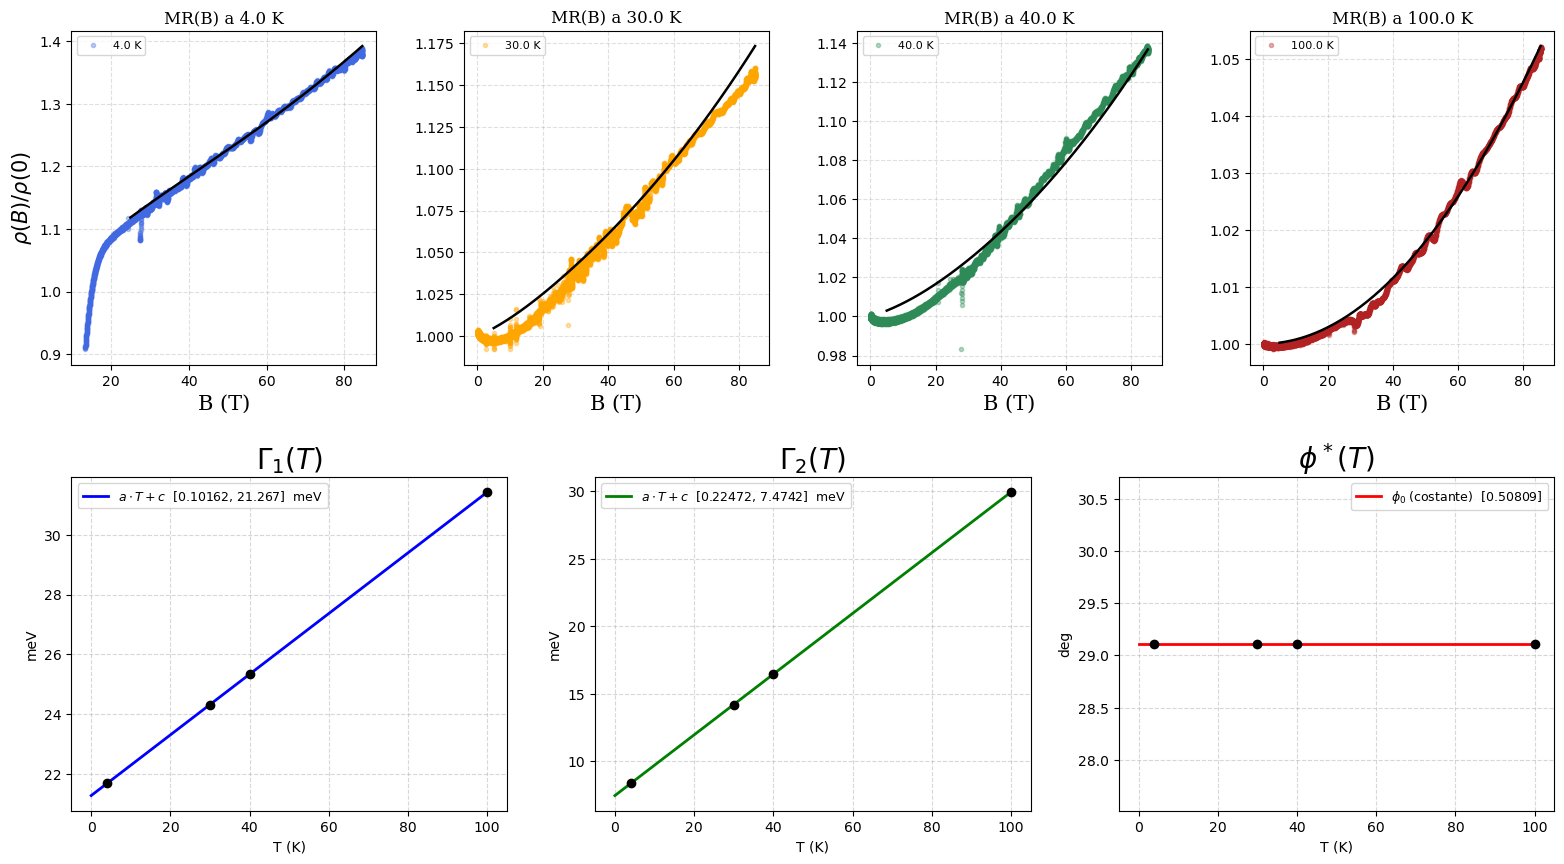

In [34]:
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 12, figure=fig)

axs_mr = [
    fig.add_subplot(gs[0, 0:3]),
    fig.add_subplot(gs[0, 3:6]),
    fig.add_subplot(gs[0, 6:9]),
    fig.add_subplot(gs[0, 9:12])
]
ax_g1 = fig.add_subplot(gs[1, 0:4])
ax_g2 = fig.add_subplot(gs[1, 4:8])
ax_ph = fig.add_subplot(gs[1, 8:12])

for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel  = B > B_MIN[T]
    g1_T = G1_fn(T, *p_G1)
    g2_T = G2_fn(T, *p_G2)
    ph_T = phi_fn(T, *p_phi)
    ax.plot(B, R, "o", color=colors[T], markersize=3, alpha=0.35, label=f"{T} K")
    B_plot = np.linspace(B[sel].min(), B.max(), 200)
    R_plot = 1.0 + cl.mr_step(B_plot, g1_T, g2_T, ph_T, m_star_opt)
    ax.plot(B_plot, R_plot, "k-", lw=1.8)
    ax.set_title(f"MR(B) a {T} K", fontdict=font1, fontsize=12)
    ax.set_xlabel("B (T)", fontdict=font2)
    if i == 0:
        ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8, loc="best")

T_fine    = np.linspace(0, 100, 300)
G1_curve  = G1_fn(T_fine, *p_G1)
G2_curve  = G2_fn(T_fine, *p_G2)
phi_curve = phi_fn(T_fine, *p_phi)

ax_g1.plot(T_fine, G1_curve, "b-", lw=2, label=cl.label_T_dep(G1_fn, p_G1, "meV"))
ax_g1.plot(T_LIST, [G1_fn(t, *p_G1) for t in T_LIST], "ko")
ax_g1.set_title(r"$\Gamma_1(T)$", fontdict=font1)
ax_g1.set_ylabel("meV")

ax_g2.plot(T_fine, G2_curve, "g-", lw=2, label=cl.label_T_dep(G2_fn, p_G2, "meV"))
ax_g2.plot(T_LIST, [G2_fn(t, *p_G2) for t in T_LIST], "ko")
ax_g2.set_title(r"$\Gamma_2(T)$", fontdict=font1)
ax_g2.set_ylabel("meV")

ax_ph.plot(T_fine, np.degrees(phi_curve), "r-", lw=2, label=cl.label_T_dep(phi_fn, p_phi))
ax_ph.plot(T_LIST, [np.degrees(phi_fn(t, *p_phi)) for t in T_LIST], "ko")
ax_ph.set_title(r"$\phi^*(T)$", fontdict=font1)
ax_ph.set_ylabel("deg")

for ax in [ax_g1, ax_g2, ax_ph]:
    ax.set_xlabel("T (K)")
    ax.grid(True, ls="--", alpha=0.5)
    ax.legend(fontsize=9)

plt.tight_layout(pad=2.0)
plt.show()


In [19]:
rows = []
for T in T_LIST:
    g1 = G1_fn(T, *p_G1)
    g2 = G2_fn(T, *p_G2)
    ph = np.degrees(phi_fn(T, *p_phi))
    rows.append(f"| {T:g} | {g1:.3f} | {g2:.3f} | {ph:.2f} | {m_star_opt:.3f} |")

md = (
    "**Tabella parametri \u2014 fit globale gradino**\n\n"
    "| T (K) | $\\Gamma_1$ (meV) | $\\Gamma_2$ (meV) | $\\varphi^{\\ast}$ (deg) | $m^{\\ast}/m_e$ |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows)
)
display(Markdown(md))


**Tabella parametri — fit globale gradino**

| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^{\ast}$ (deg) | $m^{\ast}/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 195.147 | 75.950 | 26.82 | 0.163 |
| 30 | 210.346 | 127.649 | 26.82 | 0.163 |
| 40 | 216.192 | 147.534 | 26.82 | 0.163 |
| 100 | 251.267 | 266.842 | 26.82 | 0.163 |

### Fit globale (modello Bessel)

Stessa logica del fit globale gradino, ma sul modello Bessel/cos$^4$.
Parametri liberi: $a_{\mathrm{is}}, c_{\mathrm{is}}, a_{\mathrm{an}}, c_{\mathrm{an}}, m^{*}$ — **5 in totale** (niente $\varphi^{*}$, che non entra nel modello Bessel). Le T-dipendenze di $\Gamma_{\mathrm{is}}$ e $\Gamma_{\mathrm{an}}$ sono quelle in `T_DEP['G_is']` / `T_DEP['G_an']`.


In [43]:
# --- Fit globale Bessel via cl.build_global_residual ---
# parametri: [a_is, c_is, a_an, c_an, m_star]
print("Esecuzione del Fit Globale Simultaneo (Bessel)...")


def _unpack_bessel(p, T):
    a_is, c_is, a_an, c_an, m_star = p
    Gi = eval_T_dep(T, a_is, c_is, T_DEP["G_is"])
    Ga = eval_T_dep(T, a_an, c_an, T_DEP["G_an"])
    return Gi, Ga, m_star


_model_bessel = lambda B, Gi, Ga, ms: 1.0 + cl.MR_Bessel(B, Gi, Ga, ms)

# nan_fill=0.0 assorbe i punti dove MR_Bessel restituisce NaN (B < B_ref)
# senza destabilizzare la shape del residuo.
residual_bessel = build_global_residual(
    _model_bessel, DATA, B_MIN, _unpack_bessel, n_bins=60, nan_fill=0.0
)
print(f"  punti totali dopo log-bin: {residual_bessel.total_pts}")

# --- bounds fisici coerenti con la parte step ---
MAX_GAMMA_MEV_B = 100.0
T_MAX_B = max(T_LIST)
C_MAX_B = 30.0




# p0 dai fit indipendenti Bessel: G_is(80) ~ 20 meV, G_an(80) ~ 5 meV
#             [a_is,                                 c_is,
#              a_an,                                 c_an,
#              m_star]
p0_glob_b = [
    _p0_a(T_DEP["G_is"], 20.0, 5.0, T_MAX_B),
    5.0,
    _p0_a(T_DEP["G_an"], 50.0, 2.0, T_MAX_B),
    2.0,
    1.48784,
]
lb_b = [0.0, 0.0, 0.0, 0.0, 1.48783]  # a, c >= 0
ub_b = [_a_cap(T_DEP["G_is"], MAX_GAMMA_MEV_B, C_MAX_B, T_MAX_B), C_MAX_B, _a_cap(T_DEP["G_an"], MAX_GAMMA_MEV_B, C_MAX_B, T_MAX_B), C_MAX_B, 1.48785]

print(
    f"  cap fisico Gamma_i(T<={T_MAX_B} K) <= {MAX_GAMMA_MEV_B} meV  (T_DEP={T_DEP['G_is']}/{T_DEP['G_an']})"
)
print(f"  a_is in [0, {ub_b[0]:.5f}],  a_an in [0, {ub_b[2]:.5f}]")

MAX_NFEV_B = 3000
pbar_b = tqdm(total=MAX_NFEV_B, desc="Fit Bessel globale")


def _r_b(x):
    pbar_b.update(1)
    return residual_bessel(x)


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res_glob_b = least_squares(
        _r_b,
        x0=p0_glob_b,
        bounds=(lb_b, ub_b),
        max_nfev=MAX_NFEV_B,
        loss="huber",
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-8,
        x_scale="jac",
    )
pbar_b.close()

a_is_opt, c_is_opt, a_an_opt, c_an_opt, m_star_b_opt = res_glob_b.x
rms_bessel = float(np.sqrt(np.mean(res_glob_b.fun**2)))

_t_gi = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_is"]]
_t_ga = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_an"]]

print("\nGamma_i(T) dal fit globale Bessel:")
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])
    print(f"  T={T:4.0f} K  Gamma_is={gi:7.3f} meV  Gamma_an={ga:7.3f} meV")

display(Markdown(f"""
**Risultati Fit Globale - modello Bessel**  _({res_glob_b.nfev} eval, status {res_glob_b.status})_

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_b_opt:.4f}}}$
- $\\Gamma_{{\\rm is}}(T) = {a_is_opt:.5f}\\,{_t_gi} + {c_is_opt:.3f}$ meV
- $\\Gamma_{{\\rm an}}(T) = {a_an_opt:.5f}\\,{_t_ga} + {c_an_opt:.3f}$ meV
- RMS residuo $= \\mathbf{{{rms_bessel:.5f}}}$
"""))

Esecuzione del Fit Globale Simultaneo (Bessel)...
  punti totali dopo log-bin: 240
  cap fisico Gamma_i(T<=100.0 K) <= 100.0 meV  (T_DEP=linear/linear)
  a_is in [0, 0.70000],  a_an in [0, 0.70000]


Fit Bessel globale:   0%|          | 0/3000 [00:00<?, ?it/s]


Gamma_i(T) dal fit globale Bessel:
  T=   4 K  Gamma_is=  8.232 meV  Gamma_an=  3.753 meV
  T=  30 K  Gamma_is= 14.142 meV  Gamma_an= 16.261 meV
  T=  40 K  Gamma_is= 16.415 meV  Gamma_an= 21.072 meV
  T= 100 K  Gamma_is= 30.053 meV  Gamma_an= 49.938 meV



**Risultati Fit Globale - modello Bessel**  _(20 eval, status 3)_

- $m^{\ast}/m_e = \mathbf{1.4878}$
- $\Gamma_{\rm is}(T) = 0.22730\,T + 7.323$ meV
- $\Gamma_{\rm an}(T) = 0.48109\,T + 1.828$ meV
- RMS residuo $= \mathbf{0.02779}$


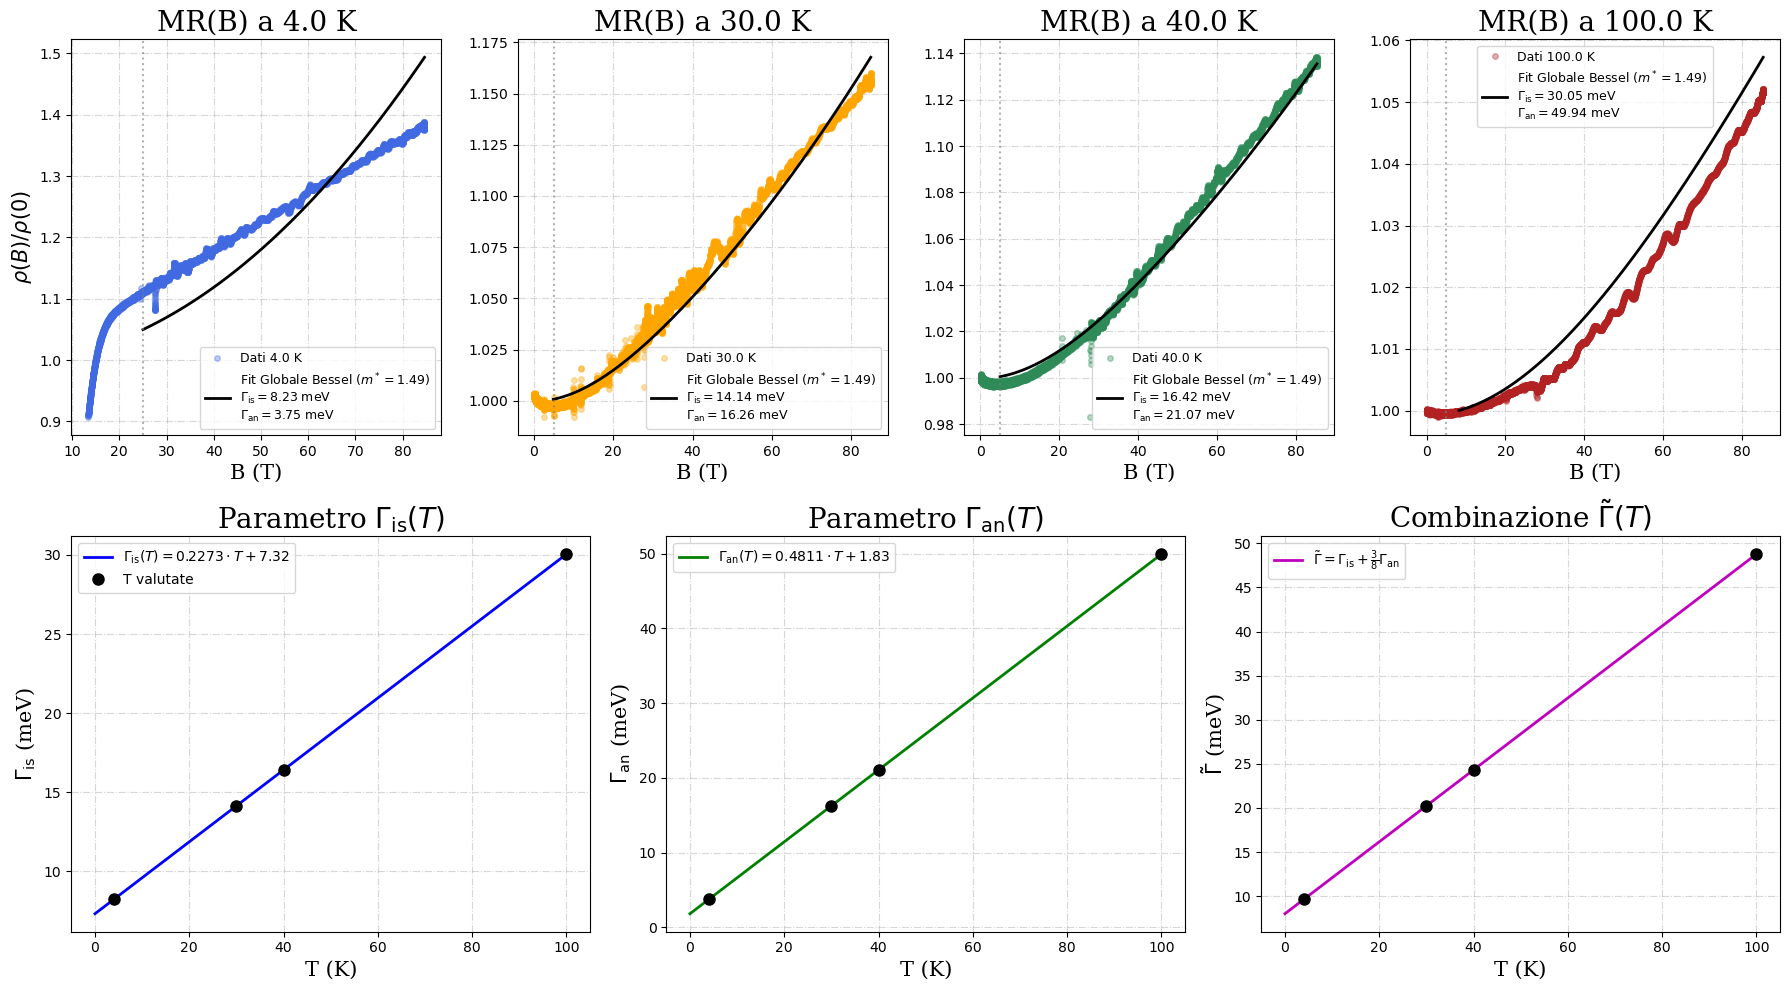

In [44]:
lbl_b = {"linear": "T", "quadratic": "T^2"}

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 12, figure=fig)

# --- CREAZIONE ASSI SU MISURA ---
# Riga 1: 4 grafici MR 
axs_mr = [
    fig.add_subplot(gs[0, 0:3]), 
    fig.add_subplot(gs[0, 3:6]), 
    fig.add_subplot(gs[0, 6:9]), 
    fig.add_subplot(gs[0, 9:12])
]

# Riga 2: 3 grafici Parametri (ciascuno occupa 4 colonne)
ax_gi = fig.add_subplot(gs[1, 0:4])
ax_ga = fig.add_subplot(gs[1, 4:8])
ax_gt = fig.add_subplot(gs[1, 8:12])

# --- RIGA 1: MR(B) per ogni T ---
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel = B > B_MIN[T]

    gi_T = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga_T = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])

    ax.plot(B, R, "o", color=colors[T], markersize=4, alpha=0.35, label=f"Dati {T} K")

    B_plot = np.linspace(B[sel].min(), B.max(), 200)
    R_plot = 1.0 + cl.MR_Bessel(B_plot, gi_T, ga_T, m_star_b_opt)

    label_fit = (
        f"Fit Globale Bessel ($m^*={m_star_b_opt:.2f}$)\n"
        f"$\\Gamma_{{\\rm is}}={gi_T:.2f}$ meV\n"
        f"$\\Gamma_{{\\rm an}}={ga_T:.2f}$ meV"
    )
    ax.plot(B_plot, R_plot, "-", color="black", linewidth=2, label=label_fit)
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.6)

    ax.set_title(f"MR(B) a {T} K", fontdict=font1)
    ax.set_xlabel("B (T)", fontdict=font2)
    # Mostriamo la label Y solo sul primo grafico per pulizia visiva
    if i == 0:
        ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=9, loc="best")

# --- RIGA 2: andamenti termici ---
T_fine = np.linspace(0, 100, 300)

# 1. Parametro Gamma is
trend_gi = eval_T_dep(T_fine, a_is_opt, c_is_opt, T_DEP["G_is"])
pts_gi = [eval_T_dep(t, a_is_opt, c_is_opt, T_DEP["G_is"]) for t in T_LIST]
ax_gi.plot(
    T_fine,
    trend_gi,
    "b-",
    lw=2,
    label=rf'$\Gamma_{{\rm is}}(T) = {a_is_opt:.4f}\cdot {lbl_b[T_DEP["G_is"]]} + {c_is_opt:.2f}$',
)
ax_gi.plot(T_LIST, pts_gi, "ko", markersize=8, label="T valutate")
ax_gi.set_title(r"Parametro $\Gamma_{\rm is}(T)$", fontdict=font1)
ax_gi.set_ylabel(r"$\Gamma_{\rm is}$ (meV)", fontdict=font2)

# 2. Parametro Gamma an
trend_ga = eval_T_dep(T_fine, a_an_opt, c_an_opt, T_DEP["G_an"])
pts_ga = [eval_T_dep(t, a_an_opt, c_an_opt, T_DEP["G_an"]) for t in T_LIST]
ax_ga.plot(
    T_fine,
    trend_ga,
    "g-",
    lw=2,
    label=rf'$\Gamma_{{\rm an}}(T) = {a_an_opt:.4f}\cdot {lbl_b[T_DEP["G_an"]]} + {c_an_opt:.2f}$',
)
ax_ga.plot(T_LIST, pts_ga, "ko", markersize=8)
ax_ga.set_title(r"Parametro $\Gamma_{\rm an}(T)$", fontdict=font1)
ax_ga.set_ylabel(r"$\Gamma_{\rm an}$ (meV)", fontdict=font2)

# 3. Combinazione G_tilde (pannello in basso a dx)
trend_gt = trend_gi + (3.0 / 8.0) * trend_ga
pts_gt = [g1 + (3.0 / 8.0) * g2 for g1, g2 in zip(pts_gi, pts_ga)]
ax_gt.plot(
    T_fine,
    trend_gt,
    "m-",
    lw=2,
    label=r"$\tilde\Gamma = \Gamma_{\rm is} + \frac{3}{8}\Gamma_{\rm an}$",
)
ax_gt.plot(T_LIST, pts_gt, "ko", markersize=8)
ax_gt.set_title(r"Combinazione $\tilde\Gamma(T)$", fontdict=font1)
ax_gt.set_ylabel(r"$\tilde\Gamma$ (meV)", fontdict=font2)

# Formattazione comune per la riga inferiore
for ax in [ax_gi, ax_ga, ax_gt]:
    ax.set_xlabel("T (K)", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [45]:
# --- Tabella parametri finali (modello Bessel) in Markdown ---
rows_b = []
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])
    gt = gi + (3.0 / 8.0) * ga
    rows_b.append(f"| {T:g} | {gi:.3f} | {ga:.3f} | {gt:.3f} | {m_star_b_opt:.3f} |")

md_b = (
    "**Tabella parametri — fit globale Bessel**\n\n"
    "| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | $\\tilde\\Gamma$ (meV) | $m^{\\ast}/m_e$ |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows_b)
)
display(Markdown(md_b))

**Tabella parametri — fit globale Bessel**

| T (K) | $\Gamma_{\rm is}$ (meV) | $\Gamma_{\rm an}$ (meV) | $\tilde\Gamma$ (meV) | $m^{\ast}/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 8.232 | 3.753 | 9.640 | 1.488 |
| 30 | 14.142 | 16.261 | 20.240 | 1.488 |
| 40 | 16.415 | 21.072 | 24.317 | 1.488 |
| 100 | 30.053 | 49.938 | 48.780 | 1.488 |

# MOESM4: MR sperimentale LSCO S1 a tre temperature

La struttura è identica alla **Sezione 2**, ma con il campione **LSCO S1** al posto del **Nd-LSCO**, sempre ad un drogaggio di $p = 0.24$

## Dati

In [46]:
# Carichiamo MOESM4 (4, 40, 100 K) e MOESM6 (30 K)
arr_s1 = cl.load_ataei_extended([4, 6])

T_MAPPING_S1 = {
    4.0: (0, 1),
    30.0: (6, 7),  # Le prime due colonne di MOESM6 (col 0 e 1 del secondo file)
    40.0: (2, 3),
    100.0: (4, 5)
}

T_LIST = [4.0, 30.0, 40.0, 100.0]
colors = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    idx_B, idx_R = T_MAPPING[T]
    B = arr[:, idx_B]
    R = arr[:, idx_R]
    
    m = (~np.isnan(B)) & (~np.isnan(R)) & (B > 0)
    DATA[T] = (B[m], R[m])
    
    print(f"T = {T:4.0f} K : N = {m.sum():5d} B in [{B[m].min():.2f}, {B[m].max():.2f}] T")

T =    4 K : N =  3872 B in [13.41, 84.61] T
T =   30 K : N =  9427 B in [0.20, 84.88] T
T =   40 K : N = 10272 B in [0.10, 85.25] T
T =  100 K : N =  9895 B in [0.10, 85.36] T


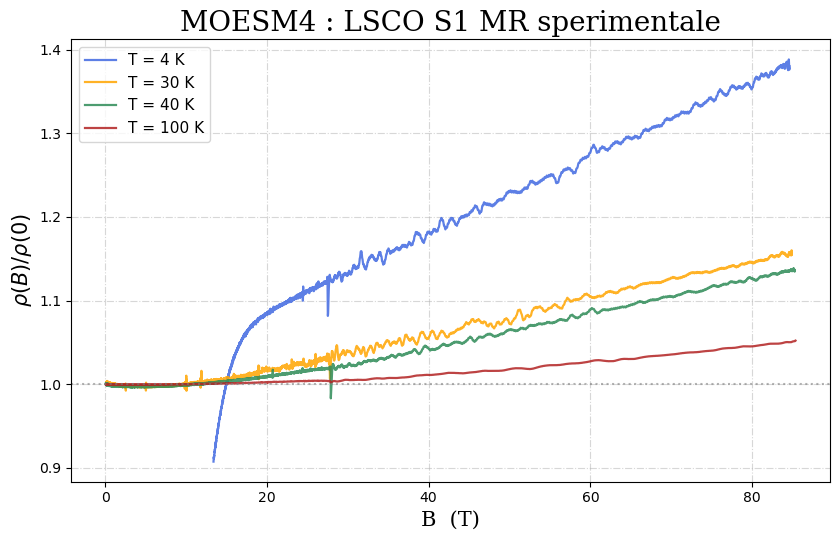

In [47]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for T in T_LIST:
    B, R = DATA[T]
    ax.plot(B, R, color=colors[T], linewidth=1.6, alpha=0.85, label=f"T = {T:.0f} K")
ax.axhline(1.0, color="gray", linestyle=":", alpha=0.6)
ax.set_xlabel("B  (T)", fontdict=font2)
ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
ax.set_title("MOESM4 : LSCO S1 MR sperimentale", fontdict=font1)
ax.legend(fontsize=11)
ax.grid(linestyle="-.", alpha=0.5)
plt.tight_layout()
plt.show()

## Fit indipendente per temperatura

### Fit indipendente per temperatura  (modello gradino)

In [48]:
# Cutoff in B per escludere la regione di fluttuazioni SC a bassa T
B_MIN = {4.0: 25.0, 30.0:5, 40.0: 5.0, 100.0: 5.0}

step_indep = 10  # downsampling coerente coi fit globali




fit_indep = {}
rows_indep_step = []
for T in T_LIST:
    B, R = DATA[T]
    sel = B > B_MIN[T]
    B_, R_ = B[sel][::step_indep], R[sel][::step_indep]
    p0 = [1, 1, 0.05, 1]
    bnds = ([0.1, 0.1, 0.05, 0], [200.0, 200.0, cl.PHI_MAX, 5])
    # tolleranze fisiche, x_scale='jac' per bilanciare parametri con scale diverse
    popt, _ = curve_fit(
        model_step_RR,
        B_,
        R_,
        p0=p0,
        bounds=bnds,
        maxfev=2000,
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-8,
        x_scale="jac",
    )
    resid = np.sqrt(np.mean((R_ - model_step_RR(B_, *popt)) ** 2))
    fit_indep[T] = (popt, resid)
    G1, G2, ph, ms = popt
    rows_indep_step.append(
        f"| {T:g} | {G1:.3f} | {G2:.3f} | {np.degrees(ph):.2f} | {ms:.3f} | {resid:.4g} |"
    )

md_indep_step = (
    "**Fit indipendente per T - modello gradino (4 parametri)**  \n"
    "| T (K) | $\\Gamma_1$ (meV) | $\\Gamma_2$ (meV) | $\\varphi^{\\ast}$ (deg) | $m^{\\ast}/m_e$ | residuo |\n"
    "|---:|---:|---:|---:|---:|---:|\n" + "\n".join(rows_indep_step)
)
display(Markdown(md_indep_step))

**Fit indipendente per T - modello gradino (4 parametri)**  
| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^{\ast}$ (deg) | $m^{\ast}/m_e$ | residuo |
|---:|---:|---:|---:|---:|---:|
| 4 | 8.034 | 24.313 | 22.32 | 1.845 | 0.004332 |
| 30 | 30.764 | 17.509 | 16.13 | 1.366 | 0.006205 |
| 40 | 26.246 | 18.503 | 18.32 | 1.324 | 0.004703 |
| 100 | 28.139 | 28.139 | 25.26 | 1.546 | 0.0009165 |

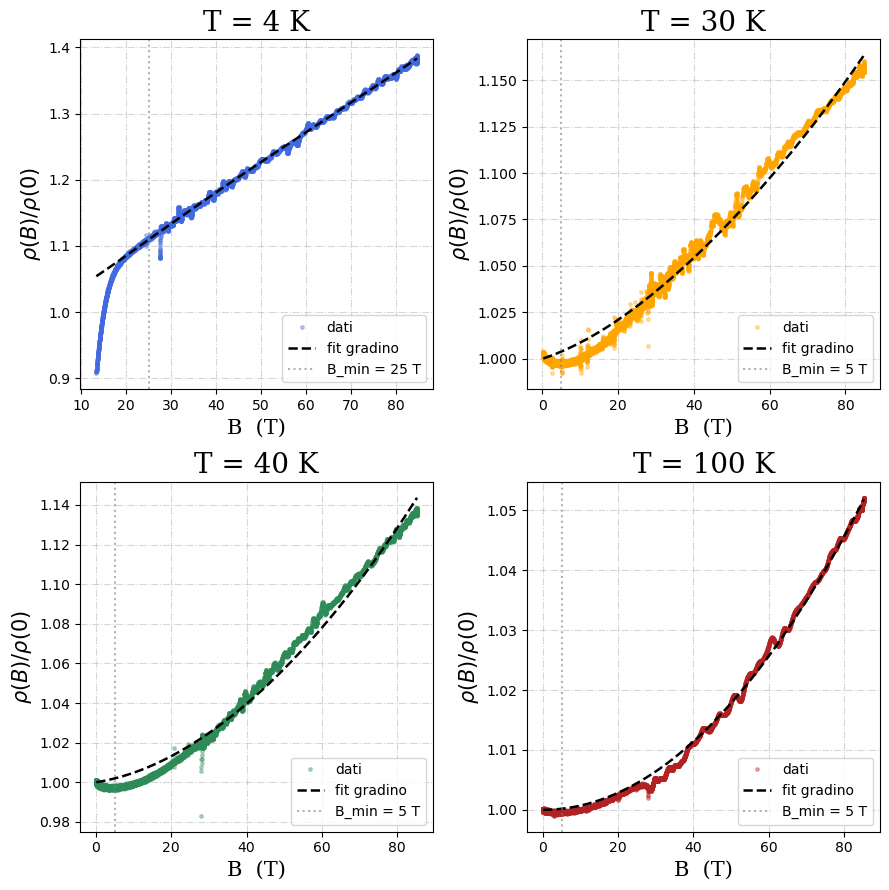

In [49]:
fig, axs = plt.subplots(2, 2, figsize=(9, 9), sharey=False)
for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    popt, _ = fit_indep[T]
    B_plot = np.linspace(max(B.min(), 0.1), B.max(), 300)
    ax.plot(B, R, "o", color=colors[T], markersize=2.5, alpha=0.35, label="dati")
    ax.plot(
        B_plot, model_step_RR(B_plot, *popt), "k--", linewidth=1.8, label="fit gradino"
    )
    ax.axvline(
        B_MIN[T],
        color="gray",
        linestyle=":",
        alpha=0.6,
        label=f"B_min = {B_MIN[T]:.0f} T",
    )
    ax.set_xlabel("B  (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=10, loc="best")
    ax.grid(linestyle="-.", alpha=0.5)
plt.tight_layout()
plt.show()

### Fit indipendenti (modello Bessel)

Stessa procedura stepwise della parte gradino, ma ora usando il modello **Bessel/cos$^4$** (`cl.MR_Bessel`) con parametri $(\Gamma_{\mathrm{is}}, \Gamma_{\mathrm{an}}, m^*)$ — 3 parametri per temperatura invece di 4.

La T-dipendenza di $\Gamma_{\mathrm{is}}$ e $\Gamma_{\mathrm{an}}$ è controllata dal dict `T_DEP` (linear o quadratic): cambialo in cima al notebook per testare una forma funzionale diversa.

In [52]:
# Step 1 (Bessel): fit indipendente a 3 parametri (G_is, G_an, m*)

fit_indep_b = {}
rows_indep_bessel = []
for T in T_LIST:
    B, R = DATA[T]
    sel = B > B_MIN[T]
    B_, R_ = B[sel][::step_indep], R[sel][::step_indep]  # downsampling step=10
    p0 = [10.0, 30.0, 1]
    bnds = ([0.1, 0.1, 0], [100.0, 100.0, 2])
    popt, _ = fit_with_bar(model_bessel_RR, B_, R_, p0, maxfev=1000, bounds=bnds)
    resid = np.sqrt(np.mean((R_ - model_bessel_RR(B_, *popt)) ** 2))
    fit_indep_b[T] = (popt, resid)
    Gis, Gan, ms = popt
    rows_indep_bessel.append(
        f"| {T:g} | {Gis:.3f} | {Gan:.3f} | {ms:.3f} | {resid:.4g} |"
    )

md_indep_bessel = (
    "**Fit indipendente per T — modello Bessel (3 parametri)**  \n"
    f"_(downsampling step={step_indep})_\n\n"
    "| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | $m^{*}/m_e$ | residuo |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows_indep_bessel)
)
display(Markdown(md_indep_bessel))

Fitting  model_bessel_RR:   0%|          | 0/1000 [00:00<?, ? eval/s]

Fitting  model_bessel_RR:   0%|          | 0/1000 [00:00<?, ? eval/s]

Fitting  model_bessel_RR:   0%|          | 0/1000 [00:00<?, ? eval/s]

Fitting  model_bessel_RR:   0%|          | 0/1000 [00:00<?, ? eval/s]

**Fit indipendente per T — modello Bessel (3 parametri)**  
_(downsampling step=10)_

| T (K) | $\Gamma_{\rm is}$ (meV) | $\Gamma_{\rm an}$ (meV) | $m^{*}/m_e$ | residuo |
|---:|---:|---:|---:|---:|
| 4 | 10.626 | 29.795 | 1.095 | 0.02002 |
| 30 | 16.363 | 32.562 | 1.383 | 0.004247 |
| 40 | 20.857 | 32.206 | 1.149 | 0.00389 |
| 100 | 32.966 | 23.793 | 1.261 | 0.001724 |

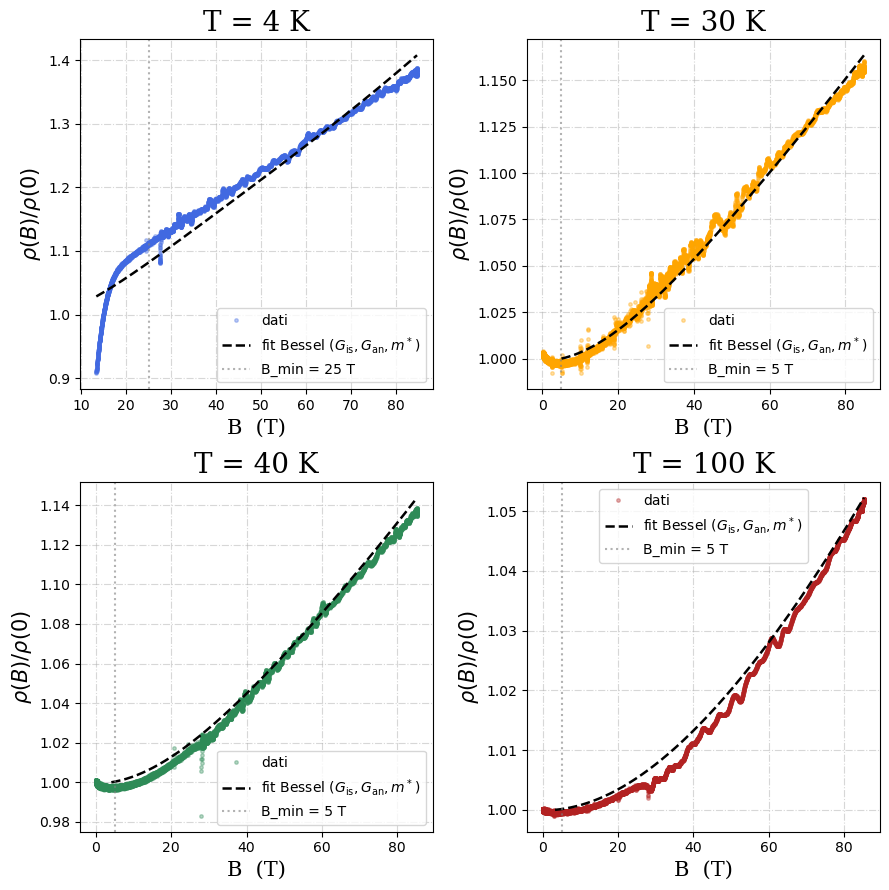

In [53]:
# Plot 3-pannello: dati + fit Bessel
fig, axs = plt.subplots(2, 2, figsize=(9, 9), sharey=False)
for ax, T in zip(axs.flatten(), T_LIST):
    B, R = DATA[T]
    popt, _ = fit_indep_b[T]
    B_plot = np.linspace(max(B.min(), 0.1), B.max(), 300)
    ax.plot(B, R, "o", color=colors[T], markersize=2.5, alpha=0.35, label="dati")
    ax.plot(
        B_plot,
        model_bessel_RR(B_plot, *popt),
        "k--",
        linewidth=1.8,
        label=r"fit Bessel ($G_{\rm is},G_{\rm an},m^*$)",
    )
    ax.axvline(
        B_MIN[T],
        color="gray",
        linestyle=":",
        alpha=0.6,
        label=f"B_min = {B_MIN[T]:.0f} T",
    )
    ax.set_xlabel("B  (T)", fontdict=font2)
    ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.set_title(f"T = {T:.0f} K", fontdict=font1)
    ax.legend(fontsize=10, loc="best")
    ax.grid(linestyle="-.", alpha=0.5)
plt.tight_layout()
plt.show()

## Fit Globale

### Fit Globale (modello gradino)

In [20]:
# --- Fit globale gradino via cl.build_global_residual (LSCO S1) ---

# ---------------------------------------------------------------
# IMPOSTAZIONE BOUNDS/P0 (modificare manualmente)
# ---------------------------------------------------------------
MAX_GAMMA_MEV = 100.0
T_MAX = max(T_LIST)
C_MAX = 30.0

# --- Override locale delle forme (opzionale; default da cella 4) ---
# G1_fn  = cl.T_linear
# G2_fn  = cl.T_linear
# phi_fn = cl.phi_tanh

print("Esecuzione del Fit Globale Simultaneo (gradino)...")

_unpack_step = cl.make_unpack_step(G1_fn, G2_fn, phi_fn)  # m_star libero
print(f"  n. parametri liberi: {_unpack_step.n_params}  "
      f"(G1:{_unpack_step.n1}, G2:{_unpack_step.n2}, phi:{_unpack_step.nphi}, m*:1)")

_model_step = lambda B, G1, G2, ph, ms: 1.0 + cl.mr_step(B, G1, G2, ph, ms)
residual_step = build_global_residual(_model_step, DATA, B_MIN, _unpack_step, n_bins=60)
print(f"  punti totali dopo log-bin: {residual_step.total_pts}")

# ---------------------------------------------------------------
# Struttura params: [*p_G1 (n1), *p_G2 (n2), *p_phi (nphi), m_star]
# Con T_linear(2p) x2 + phi_tanh(3p) + m_star(1) -> 8 totali
# ---------------------------------------------------------------
p0_glob = [
    _p0_a("linear", 30.0, 10.0, T_MAX), 10.0,  # G1: a, c
    _p0_a("linear", 25.0,  5.0, T_MAX),  5.0,  # G2: a, c
    0.7, -0.2, 30.0,                           # phi: phi0, dphi, T_phi
    2.0,                                       # m_star
]

lb = [0.0, 0.0,  0.0, 0.0,  0.0, -cl.PHI_MAX, 1.0,  0.5]
ub = [
    _a_cap("linear", MAX_GAMMA_MEV, C_MAX, T_MAX), C_MAX,
    _a_cap("linear", MAX_GAMMA_MEV, C_MAX, T_MAX), C_MAX,
    cl.PHI_MAX, 0.0, 500.0, 15.0,
]

print(f"  cap fisico Gamma_i(T<={T_MAX} K) <= {MAX_GAMMA_MEV} meV")

MAX_NFEV = 3000
pbar = tqdm(total=MAX_NFEV, desc="Fit gradino globale")

def _r(x):
    pbar.update(1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = residual_step(x)
    if not np.all(np.isfinite(res)):
        return np.full(residual_step.total_pts, 1e6 + np.sum(np.array(x)**2))
    return res

res_glob = least_squares(
    _r, x0=p0_glob, bounds=(lb, ub), max_nfev=MAX_NFEV,
    loss="huber", ftol=1e-10, xtol=1e-10, gtol=1e-8,
    x_scale="jac",
)
pbar.close()

opt_params = res_glob.x
p_G1, p_G2, p_phi, m_star_opt = unpack_opt(opt_params, _unpack_step)
rms_step = float(np.sqrt(np.mean(res_glob.fun**2)))

print("\nGamma_i(T) dal fit globale:")
for T in T_LIST:
    g1 = G1_fn(T, *p_G1)
    g2 = G2_fn(T, *p_G2)
    print(f"  T={T:4.0f} K  Gamma_1={g1:7.3f} meV  Gamma_2={g2:7.3f} meV")

display(Markdown(f"""
**Risultati Fit Globale - modello gradino** _({res_glob.nfev} eval, status {res_glob.status})_

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_opt:.4f}}}$
- $\\Gamma_1(T)$: {cl.label_T_dep(G1_fn, p_G1, "meV")}
- $\\Gamma_2(T)$: {cl.label_T_dep(G2_fn, p_G2, "meV")}
- $\\varphi^{{\\ast}}(T)$: {cl.label_T_dep(phi_fn, p_phi)}
- RMS residuo $= \\mathbf{{{rms_step:.5f}}}$
"""))


Esecuzione del Fit Globale Simultaneo (gradino)...
  n. parametri liberi: 6  (G1:2, G2:2, phi:1, m*:1)
  punti totali dopo log-bin: 240
  cap fisico Gamma_i(T<=100.0 K) <= 100.0 meV


Fit gradino globale:   0%|          | 0/3000 [00:00<?, ?it/s]


Gamma_i(T) dal fit globale:
  T=   4 K  Gamma_1= 10.800 meV  Gamma_2=  5.800 meV
  T=  30 K  Gamma_1= 16.000 meV  Gamma_2= 11.000 meV
  T=  40 K  Gamma_1= 18.000 meV  Gamma_2= 13.000 meV
  T= 100 K  Gamma_1= 30.000 meV  Gamma_2= 25.000 meV



**Risultati Fit Globale - modello gradino** _(1 eval, status 1)_

- $m^{\ast}/m_e = \mathbf{-0.2000}$
- $\Gamma_1(T)$: $a\cdot T + c$  [0.2, 10]  meV
- $\Gamma_2(T)$: $a\cdot T + c$  [0.2, 5]  meV
- $\varphi^{\ast}(T)$: $\phi_0\;\text{(costante)}$  [0.7]
- RMS residuo $= \mathbf{0.00000}$


/home/obscur3_gr1m/Tesi/jupyter tesi/chambers_lib.py:55: RuntimeWarning: overflow encountered in exp
  denom = 1 + 1j * np.exp(-(Gamma1 * S2 + Gamma2 * S1))
/home/obscur3_gr1m/Tesi/jupyter tesi/chambers_lib.py:55: RuntimeWarning: invalid value encountered in multiply
  denom = 1 + 1j * np.exp(-(Gamma1 * S2 + Gamma2 * S1))
/home/obscur3_gr1m/Tesi/jupyter tesi/chambers_lib.py:56: RuntimeWarning: overflow encountered in exp
  Z12 = ((1 - np.exp(-(Gamma2 + 1j*w) * S1)) / denom
/home/obscur3_gr1m/Tesi/jupyter tesi/chambers_lib.py:56: RuntimeWarning: invalid value encountered in divide
  Z12 = ((1 - np.exp(-(Gamma2 + 1j*w) * S1)) / denom
/home/obscur3_gr1m/Tesi/jupyter tesi/chambers_lib.py:58: RuntimeWarning: overflow encountered in exp
  Z21 = ((1 - np.exp(-(Gamma1 + 1j*w) * S2)) / denom
/home/obscur3_gr1m/Tesi/jupyter tesi/chambers_lib.py:58: RuntimeWarning: invalid value encountered in divide
  Z21 = ((1 - np.exp(-(Gamma1 + 1j*w) * S2)) / denom
/home/obscur3_gr1m/Tesi/jupyter tesi/chamber

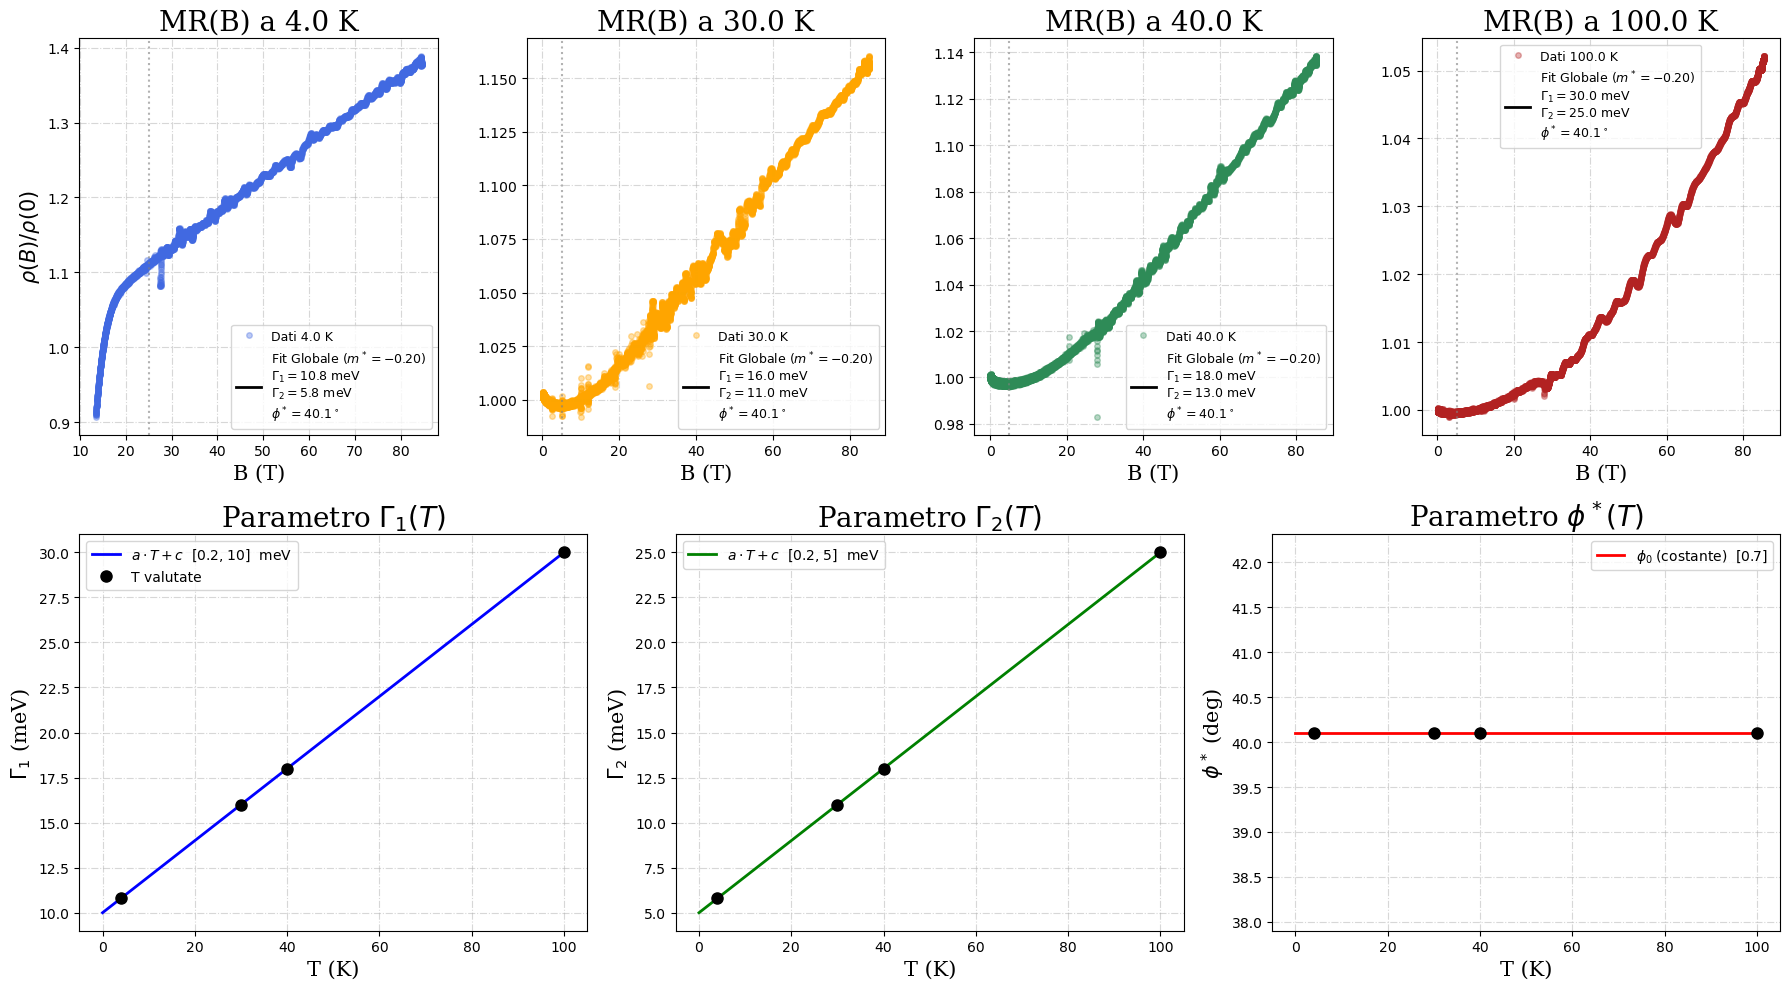

In [17]:
lbl = {"linear": "T", "quadratic": "T^2"}  # per modello Bessel

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 12, figure=fig)

axs_mr = [
    fig.add_subplot(gs[0, 0:3]),
    fig.add_subplot(gs[0, 3:6]),
    fig.add_subplot(gs[0, 6:9]),
    fig.add_subplot(gs[0, 9:12])
]
ax_g1 = fig.add_subplot(gs[1, 0:4])
ax_g2 = fig.add_subplot(gs[1, 4:8])
ax_ph = fig.add_subplot(gs[1, 8:12])

for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel  = B > B_MIN[T]
    g1_T = G1_fn(T, *p_G1)
    g2_T = G2_fn(T, *p_G2)
    ph_T = phi_fn(T, *p_phi)
    ax.plot(B, R, "o", color=colors[T], markersize=4, alpha=0.35, label=f"Dati {T} K")
    B_plot  = np.linspace(B[sel].min(), B.max(), 200)
    R_plot  = 1.0 + cl.mr_step(B_plot, g1_T, g2_T, ph_T, m_star_opt)
    label_fit = (
        f"Fit Globale ($m^*={m_star_opt:.2f}$)\n"
        f"$\\Gamma_1={g1_T:.1f}$ meV\n"
        f"$\\Gamma_2={g2_T:.1f}$ meV\n"
        f"$\\phi^*={np.degrees(ph_T):.1f}^\\circ$"
    )
    ax.plot(B_plot, R_plot, "-", color="black", linewidth=2, label=label_fit)
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.6)
    ax.set_title(f"MR(B) a {T} K", fontdict=font1)
    ax.set_xlabel("B (T)", fontdict=font2)
    if i == 0:
        ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=9, loc="best")

T_fine    = np.linspace(0, 100, 300)
G1_curve  = G1_fn(T_fine, *p_G1)
G2_curve  = G2_fn(T_fine, *p_G2)
phi_curve = phi_fn(T_fine, *p_phi)

ax_g1.plot(T_fine, G1_curve, "b-", lw=2, label=cl.label_T_dep(G1_fn, p_G1, "meV"))
ax_g1.plot(T_LIST, [G1_fn(t, *p_G1) for t in T_LIST], "ko", markersize=8, label="T valutate")
ax_g1.set_title(r"Parametro $\Gamma_1(T)$", fontdict=font1)
ax_g1.set_ylabel(r"$\Gamma_1$ (meV)", fontdict=font2)

ax_g2.plot(T_fine, G2_curve, "g-", lw=2, label=cl.label_T_dep(G2_fn, p_G2, "meV"))
ax_g2.plot(T_LIST, [G2_fn(t, *p_G2) for t in T_LIST], "ko", markersize=8)
ax_g2.set_title(r"Parametro $\Gamma_2(T)$", fontdict=font1)
ax_g2.set_ylabel(r"$\Gamma_2$ (meV)", fontdict=font2)

ax_ph.plot(T_fine, np.degrees(phi_curve), "r-", lw=2, label=cl.label_T_dep(phi_fn, p_phi))
ax_ph.plot(T_LIST, [np.degrees(phi_fn(t, *p_phi)) for t in T_LIST], "ko", markersize=8)
ax_ph.set_title(r"Parametro $\phi^*(T)$", fontdict=font1)
ax_ph.set_ylabel(r"$\phi^*$ (deg)", fontdict=font2)

for ax in [ax_g1, ax_g2, ax_ph]:
    ax.set_xlabel("T (K)", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


In [56]:
rows = []
for T in T_LIST:
    g1 = G1_fn(T, *p_G1)
    g2 = G2_fn(T, *p_G2)
    ph = np.degrees(phi_fn(T, *p_phi))
    rows.append(f"| {T:g} | {g1:.3f} | {g2:.3f} | {ph:.2f} | {m_star_opt:.3f} |")

md = (
    "**Tabella parametri \u2014 fit globale gradino**\n\n"
    "| T (K) | $\\Gamma_1$ (meV) | $\\Gamma_2$ (meV) | $\\varphi^{\\ast}$ (deg) | $m^{\\ast}/m_e$ |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows)
)
display(Markdown(md))


**Tabella parametri — fit globale gradino**

| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^{\ast}$ (deg) | $m^{\ast}/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 10.800 | 5.800 | 40.11 | -0.200 |
| 30 | 16.000 | 11.000 | 40.11 | -0.200 |
| 40 | 18.000 | 13.000 | 40.11 | -0.200 |
| 100 | 30.000 | 25.000 | 40.11 | -0.200 |

### Fit Globale (modello Bessl)

In [57]:
# --- Fit globale Bessel via cl.build_global_residual ---
# parametri: [a_is, c_is, a_an, c_an, m_star]
print("Esecuzione del Fit Globale Simultaneo (Bessel)...")


def _unpack_bessel(p, T):
    a_is, c_is, a_an, c_an, m_star = p
    Gi = eval_T_dep(T, a_is, c_is, T_DEP["G_is"])
    Ga = eval_T_dep(T, a_an, c_an, T_DEP["G_an"])
    return Gi, Ga, m_star


_model_bessel = lambda B, Gi, Ga, ms: 1.0 + cl.MR_Bessel(B, Gi, Ga, ms)

# nan_fill=0.0 assorbe i punti dove MR_Bessel restituisce NaN (B < B_ref)
# senza destabilizzare la shape del residuo.
residual_bessel = build_global_residual(
    _model_bessel, DATA, B_MIN, _unpack_bessel, n_bins=60, nan_fill=0.0
)
print(f"  punti totali dopo log-bin: {residual_bessel.total_pts}")

# --- bounds fisici coerenti con la parte step ---
MAX_GAMMA_MEV_B = 100.0
T_MAX_B = max(T_LIST)
C_MAX_B = 30.0




# p0 dai fit indipendenti Bessel: G_is(80) ~ 20 meV, G_an(80) ~ 5 meV
#             [a_is,                                 c_is,
#              a_an,                                 c_an,
#              m_star]
p0_glob_b = [
    _p0_a(T_DEP["G_is"], 20.0, 5.0, T_MAX_B),
    5.0,
    _p0_a(T_DEP["G_an"], 5.0, 2.0, T_MAX_B),
    2.0,
    5.0,
]
lb_b = [0.0, 0.0, 0.0, 0.0, 4.0]  # a, c >= 0
ub_b = [_a_cap(T_DEP["G_is"], MAX_GAMMA_MEV_B, C_MAX_B, T_MAX_B), C_MAX_B, _a_cap(T_DEP["G_an"], MAX_GAMMA_MEV_B, C_MAX_B, T_MAX_B), C_MAX_B, 10.0]

print(
    f"  cap fisico Gamma_i(T<={T_MAX_B} K) <= {MAX_GAMMA_MEV_B} meV  (T_DEP={T_DEP['G_is']}/{T_DEP['G_an']})"
)
print(f"  a_is in [0, {ub_b[0]:.5f}],  a_an in [0, {ub_b[2]:.5f}]")

MAX_NFEV_B = 3000
pbar_b = tqdm(total=MAX_NFEV_B, desc="Fit Bessel globale")


def _r_b(x):
    pbar_b.update(1)
    return residual_bessel(x)


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res_glob_b = least_squares(
        _r_b,
        x0=p0_glob_b,
        bounds=(lb_b, ub_b),
        max_nfev=MAX_NFEV_B,
        loss="huber",
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-8,
        x_scale="jac",
    )
pbar_b.close()

a_is_opt, c_is_opt, a_an_opt, c_an_opt, m_star_b_opt = res_glob_b.x
rms_bessel = float(np.sqrt(np.mean(res_glob_b.fun**2)))

_t_gi = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_is"]]
_t_ga = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_an"]]

print("\nGamma_i(T) dal fit globale Bessel:")
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])
    print(f"  T={T:4.0f} K  Gamma_is={gi:7.3f} meV  Gamma_an={ga:7.3f} meV")

display(Markdown(f"""
**Risultati Fit Globale - modello Bessel**  _({res_glob_b.nfev} eval, status {res_glob_b.status})_

- $m^{{\\ast}}/m_e = \\mathbf{{{m_star_b_opt:.4f}}}$
- $\\Gamma_{{\\rm is}}(T) = {a_is_opt:.5f}\\,{_t_gi} + {c_is_opt:.3f}$ meV
- $\\Gamma_{{\\rm an}}(T) = {a_an_opt:.5f}\\,{_t_ga} + {c_an_opt:.3f}$ meV
- RMS residuo $= \\mathbf{{{rms_bessel:.5f}}}$
"""))

Esecuzione del Fit Globale Simultaneo (Bessel)...
  punti totali dopo log-bin: 240
  cap fisico Gamma_i(T<=100.0 K) <= 100.0 meV  (T_DEP=linear/linear)
  a_is in [0, 0.70000],  a_an in [0, 0.70000]


Fit Bessel globale:   0%|          | 0/3000 [00:00<?, ?it/s]


Gamma_i(T) dal fit globale Bessel:
  T=   4 K  Gamma_is=  2.568 meV  Gamma_an=  5.192 meV
  T=  30 K  Gamma_is=  5.223 meV  Gamma_an= 14.765 meV
  T=  40 K  Gamma_is=  6.244 meV  Gamma_an= 18.447 meV
  T= 100 K  Gamma_is= 12.369 meV  Gamma_an= 40.539 meV



**Risultati Fit Globale - modello Bessel**  _(27 eval, status 3)_

- $m^{\ast}/m_e = \mathbf{4.3691}$
- $\Gamma_{\rm is}(T) = 0.10209\,T + 2.160$ meV
- $\Gamma_{\rm an}(T) = 0.36820\,T + 3.719$ meV
- RMS residuo $= \mathbf{0.01307}$


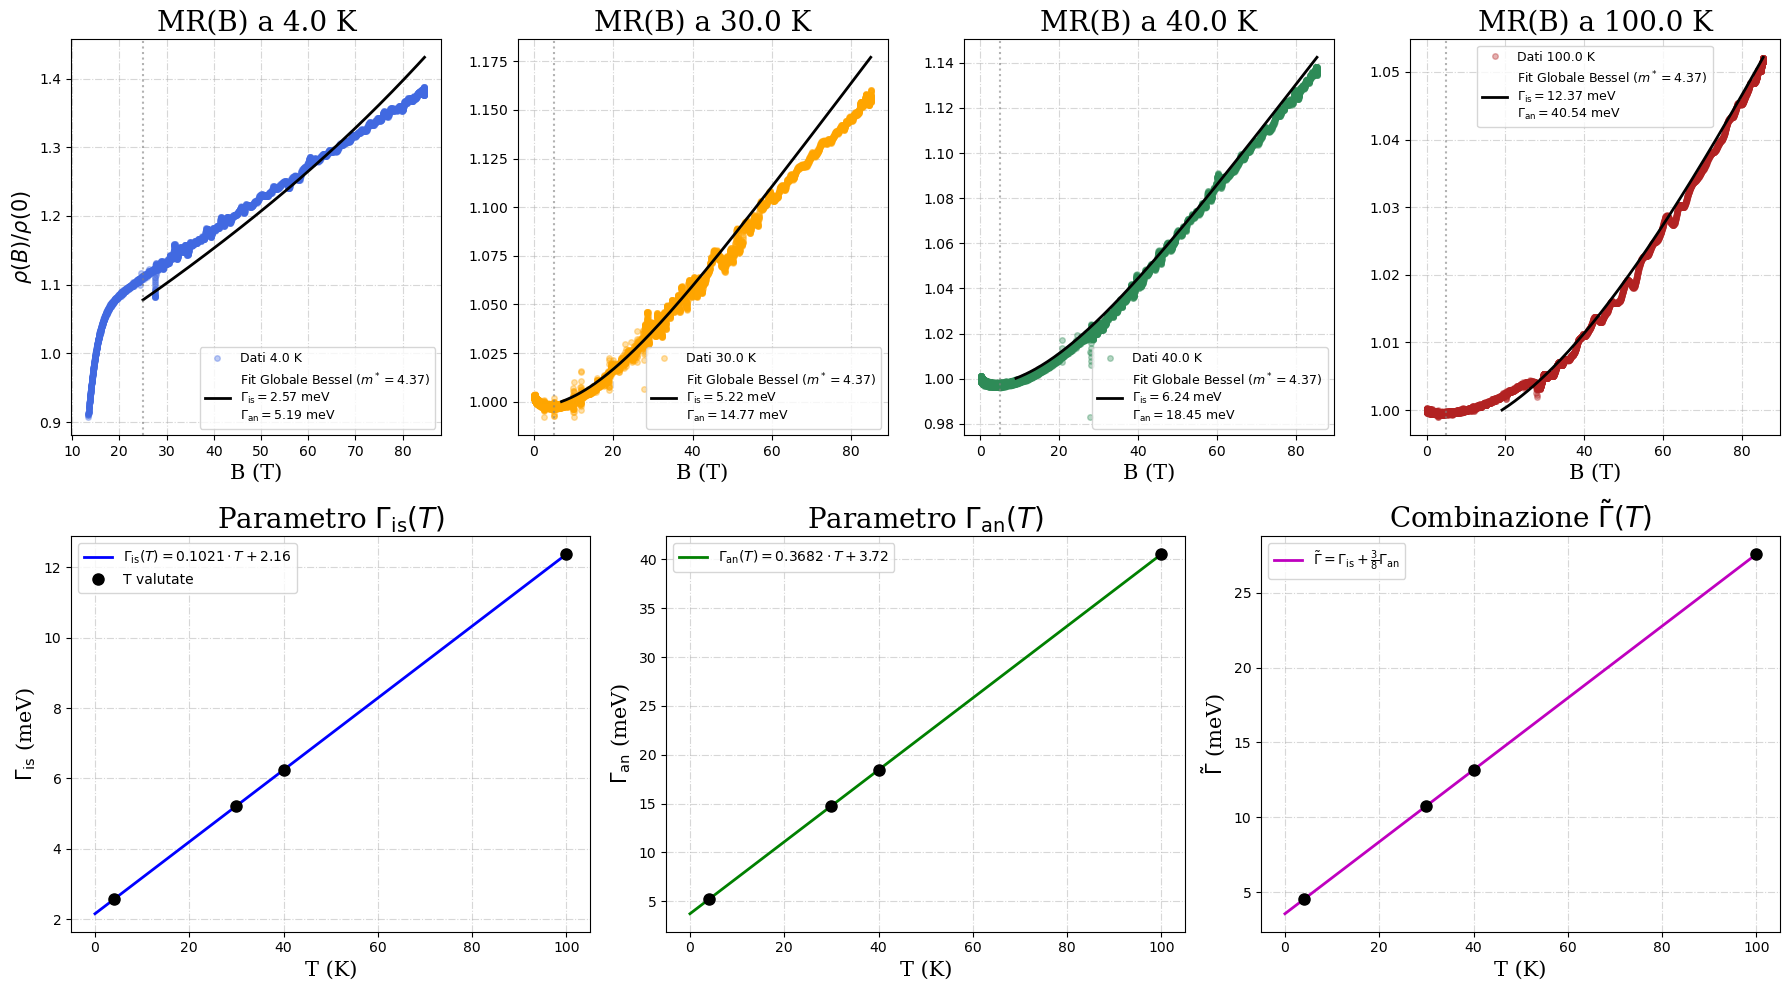

In [58]:
# --- Plot 2x3:
lbl_b = {"linear": "T", "quadratic": "T^2"}

fig = plt.figure(figsize=(18, 10))

gs = gridspec.GridSpec(2, 12, figure=fig)

# --- CREAZIONE ASSI SU MISURA ---
axs_mr = [
    fig.add_subplot(gs[0, 0:3]), 
    fig.add_subplot(gs[0, 3:6]), 
    fig.add_subplot(gs[0, 6:9]), 
    fig.add_subplot(gs[0, 9:12])
]

# Riga 2: 3 grafici Parametri 
ax_gi = fig.add_subplot(gs[1, 0:4])
ax_ga = fig.add_subplot(gs[1, 4:8])
ax_gt = fig.add_subplot(gs[1, 8:12])

# --- RIGA 1: MR(B) per ogni T ---
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel = B > B_MIN[T]

    gi_T = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga_T = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])

    ax.plot(B, R, "o", color=colors[T], markersize=4, alpha=0.35, label=f"Dati {T} K")

    B_plot = np.linspace(B[sel].min(), B.max(), 200)
    R_plot = 1.0 + cl.MR_Bessel(B_plot, gi_T, ga_T, m_star_b_opt)

    label_fit = (
        f"Fit Globale Bessel ($m^*={m_star_b_opt:.2f}$)\n"
        f"$\\Gamma_{{\\rm is}}={gi_T:.2f}$ meV\n"
        f"$\\Gamma_{{\\rm an}}={ga_T:.2f}$ meV"
    )
    ax.plot(B_plot, R_plot, "-", color="black", linewidth=2, label=label_fit)
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.6)

    ax.set_title(f"MR(B) a {T} K", fontdict=font1)
    ax.set_xlabel("B (T)", fontdict=font2)
    # Mostriamo la label Y solo sul primo grafico per pulizia visiva
    if i == 0:
        ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=9, loc="best")

# --- RIGA 2: andamenti termici ---
T_fine = np.linspace(0, 100, 300)

# 1. Parametro Gamma is
trend_gi = eval_T_dep(T_fine, a_is_opt, c_is_opt, T_DEP["G_is"])
pts_gi = [eval_T_dep(t, a_is_opt, c_is_opt, T_DEP["G_is"]) for t in T_LIST]
ax_gi.plot(
    T_fine,
    trend_gi,
    "b-",
    lw=2,
    label=rf'$\Gamma_{{\rm is}}(T) = {a_is_opt:.4f}\cdot {lbl_b[T_DEP["G_is"]]} + {c_is_opt:.2f}$',
)
ax_gi.plot(T_LIST, pts_gi, "ko", markersize=8, label="T valutate")
ax_gi.set_title(r"Parametro $\Gamma_{\rm is}(T)$", fontdict=font1)
ax_gi.set_ylabel(r"$\Gamma_{\rm is}$ (meV)", fontdict=font2)

# 2. Parametro Gamma an
trend_ga = eval_T_dep(T_fine, a_an_opt, c_an_opt, T_DEP["G_an"])
pts_ga = [eval_T_dep(t, a_an_opt, c_an_opt, T_DEP["G_an"]) for t in T_LIST]
ax_ga.plot(
    T_fine,
    trend_ga,
    "g-",
    lw=2,
    label=rf'$\Gamma_{{\rm an}}(T) = {a_an_opt:.4f}\cdot {lbl_b[T_DEP["G_an"]]} + {c_an_opt:.2f}$',
)
ax_ga.plot(T_LIST, pts_ga, "ko", markersize=8)
ax_ga.set_title(r"Parametro $\Gamma_{\rm an}(T)$", fontdict=font1)
ax_ga.set_ylabel(r"$\Gamma_{\rm an}$ (meV)", fontdict=font2)

# 3. Combinazione G_tilde (pannello in basso a dx)
trend_gt = trend_gi + (3.0 / 8.0) * trend_ga
pts_gt = [g1 + (3.0 / 8.0) * g2 for g1, g2 in zip(pts_gi, pts_ga)]
ax_gt.plot(
    T_fine,
    trend_gt,
    "m-",
    lw=2,
    label=r"$\tilde\Gamma = \Gamma_{\rm is} + \frac{3}{8}\Gamma_{\rm an}$",
)
ax_gt.plot(T_LIST, pts_gt, "ko", markersize=8)
ax_gt.set_title(r"Combinazione $\tilde\Gamma(T)$", fontdict=font1)
ax_gt.set_ylabel(r"$\tilde\Gamma$ (meV)", fontdict=font2)

# Formattazione comune per la riga inferiore
for ax in [ax_gi, ax_ga, ax_gt]:
    ax.set_xlabel("T (K)", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [59]:
# --- Tabella parametri finali (modello Bessel) in Markdown ---
rows_b = []
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])
    gt = gi + (3.0 / 8.0) * ga
    rows_b.append(f"| {T:g} | {gi:.3f} | {ga:.3f} | {gt:.3f} | {m_star_b_opt:.3f} |")

md_b = (
    "**Tabella parametri — fit globale Bessel**\n\n"
    "| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | $\\tilde\\Gamma$ (meV) | $m^{\\ast}/m_e$ |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows_b)
)
display(Markdown(md_b))

**Tabella parametri — fit globale Bessel**

| T (K) | $\Gamma_{\rm is}$ (meV) | $\Gamma_{\rm an}$ (meV) | $\tilde\Gamma$ (meV) | $m^{\ast}/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 2.568 | 5.192 | 4.515 | 4.369 |
| 30 | 5.223 | 14.765 | 10.760 | 4.369 |
| 40 | 6.244 | 18.447 | 13.161 | 4.369 |
| 100 | 12.369 | 40.539 | 27.571 | 4.369 |

# Fit Globale Nd-LSCO con calibrazione da A153 (Modello Bessel)
Da **Magnetoresistence.ipynb**, sfruttando che Mirarchi ha già trovato $\Gamma_{is} = 17.7\ \text{meV}$ e $\Gamma_{an} = 39\ \text{meV}$, calibriamo la massa efficace come $m^* = 1.48784\ \text{m$_e$}$. In più questi valori sono dati per $T=30\ \text{K}$, possiamo quindi fissare la T-dependence come:
$$
\Gamma_i = a_i T^p + c_i 
$$
$$
\hookrightarrow \Gamma_i(T) = a(T^p-30^p) + \Gamma_i(30K)
$$
Quindi abbiamo **un parametro** di fit per scattering rate

## Dati

In [60]:
# Carichiamo entrambi i file
arr = cl.load_ataei_extended([2, 6])

# Definiamo le temperature e dove si trovano le coppie (B, R) nell'array 'arr'
# Per Nd-LSCO:
# 4K -> col 0,1 | 40K -> col 2,3 | 100K -> col 4,5 | 30K -> col 10,11 (perché MOESM6 ha 6 colonne prima)
# Tuttavia, per semplicità, mappiamole manualmente:
T_MAPPING = {
    4.0: (0, 1),
    30.0: (10, 11), # Le ultime due colonne di MOESM6 (che era il secondo file caricato)
    40.0: (2, 3),
    100.0: (4, 5)
}

T_LIST = [4.0, 30.0, 40.0, 100.0]
colors = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    idx_B, idx_R = T_MAPPING[T]
    B = arr[:, idx_B]
    R = arr[:, idx_R]
    
    m = (~np.isnan(B)) & (~np.isnan(R)) & (B > 0)
    DATA[T] = (B[m], R[m])
    
    print(f"T = {T:4.0f} K : N = {m.sum():5d} B in [{B[m].min():.2f}, {B[m].max():.2f}] T")

T =    4 K : N =  3872 B in [13.41, 84.61] T
T =   30 K : N =  9427 B in [0.20, 84.88] T
T =   40 K : N = 10272 B in [0.10, 85.25] T
T =  100 K : N =  9895 B in [0.10, 85.36] T


## Fit (Bessel, $\Gamma_{is/an}(30K)$ fissati)

In [61]:
# --- Fit globale Bessel via cl.build_global_residual ---
# parametri di fit: [a_is, a_an, G_is_30, G_an_30]
print("Esecuzione del Fit Globale Simultaneo (Bessel)...")

def _unpack_bessel(p, T):
    a_is, a_an, G_is_30, G_an_30 = p
    
    p_is = 2 if T_DEP["G_is"] == "quadratic" else 1
    p_an = 2 if T_DEP["G_an"] == "quadratic" else 1
    
    # Intercette calcolate in base al valore ottimizzato a 30K
    c_is = G_is_30 - a_is * (30.0**p_is)
    c_an = G_an_30 - a_an * (30.0**p_an)
    
    Gi = eval_T_dep(T, a_is, c_is, T_DEP["G_is"])
    Ga = eval_T_dep(T, a_an, c_an, T_DEP["G_an"])
    
    return Gi, Ga, 1.48784  # Massa fissata

_model_bessel = lambda B, Gi, Ga, ms: 1.0 + cl.MR_Bessel(B, Gi, Ga, ms)

residual_bessel = build_global_residual(
    _model_bessel, DATA, B_MIN, _unpack_bessel, n_bins=60, nan_fill=0.0
)
print(f"  punti totali dopo log-bin: {residual_bessel.total_pts}")

# p0: [a_is, a_an, G_is_30_guess, G_an_30_guess]
p0_glob_b = [1, 0.1, 17.7, 39.0]

# Bounds: i primi due sono per le 'a', gli ultimi due permettono ai Gamma(30K) 
# di variare in una piccola finestra attorno ai valori di calibrazione.
lb_b = [0.1, 0.0, 17, 38.5]
ub_b = [2, 0.5, 18, 39.5]

MAX_NFEV_B = 3000
pbar_b = tqdm(total=MAX_NFEV_B, desc="Fit Bessel globale")

def _r_b(x):
    pbar_b.update(1)
    return residual_bessel(x)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res_glob_b = least_squares(
        _r_b,
        x0=p0_glob_b,
        bounds=(lb_b, ub_b),
        max_nfev=MAX_NFEV_B,
        loss="huber",
        ftol=1e-10,
        xtol=1e-10,
        gtol=1e-8,
    )
pbar_b.close()

a_is_opt, a_an_opt, G_is_30_opt, G_an_30_opt = res_glob_b.x
rms_bessel = float(np.sqrt(np.mean(res_glob_b.fun**2)))

p_is = 2 if T_DEP["G_is"] == "quadratic" else 1
p_an = 2 if T_DEP["G_an"] == "quadratic" else 1
c_is_opt = G_is_30_opt - a_is_opt * (30.0**p_is)
c_an_opt = G_an_30_opt - a_an_opt * (30.0**p_an)

_t_gi = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_is"]]
_t_ga = {"linear": "T", "quadratic": "T^2"}[T_DEP["G_an"]]

print("\nGamma_i(T) dal fit globale Bessel:")
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])
    print(f"  T={T:4.0f} K  Gamma_is={gi:7.3f} meV  Gamma_an={ga:7.3f} meV")

display(Markdown(f"""
**Risultati Fit Globale - modello Bessel** _({res_glob_b.nfev} eval, status {res_glob_b.status})_

- $m^{{\\ast}}/m_e = \\mathbf{{1.48784}}$ 
- Valori 30K raffinati: $\\Gamma_{{\\rm is}} = {G_is_30_opt:.2f}$ meV, $\\Gamma_{{\\rm an}} = {G_an_30_opt:.2f}$ meV
- $\\Gamma_{{\\rm is}}(T) = {a_is_opt:.6f}\\,{_t_gi} {c_is_opt:+.3f}$ meV
- $\\Gamma_{{\\rm an}}(T) = {a_an_opt:.6f}\\,{_t_ga} {c_an_opt:+.3f}$ meV
- RMS residuo $= \\mathbf{{{rms_bessel:.5f}}}$
"""))

Esecuzione del Fit Globale Simultaneo (Bessel)...
  punti totali dopo log-bin: 240


Fit Bessel globale:   0%|          | 0/3000 [00:00<?, ?it/s]


Gamma_i(T) dal fit globale Bessel:
  T=   4 K  Gamma_is=  8.321 meV  Gamma_an= 38.088 meV
  T=  30 K  Gamma_is= 17.797 meV  Gamma_an= 39.493 meV
  T=  40 K  Gamma_is= 21.441 meV  Gamma_an= 40.033 meV
  T= 100 K  Gamma_is= 43.309 meV  Gamma_an= 43.275 meV



**Risultati Fit Globale - modello Bessel** _(19 eval, status 3)_

- $m^{\ast}/m_e = \mathbf{1.48784}$ 
- Valori 30K raffinati: $\Gamma_{\rm is} = 17.80$ meV, $\Gamma_{\rm an} = 39.49$ meV
- $\Gamma_{\rm is}(T) = 0.364468\,T +6.863$ meV
- $\Gamma_{\rm an}(T) = 0.054024\,T +37.872$ meV
- RMS residuo $= \mathbf{0.01254}$


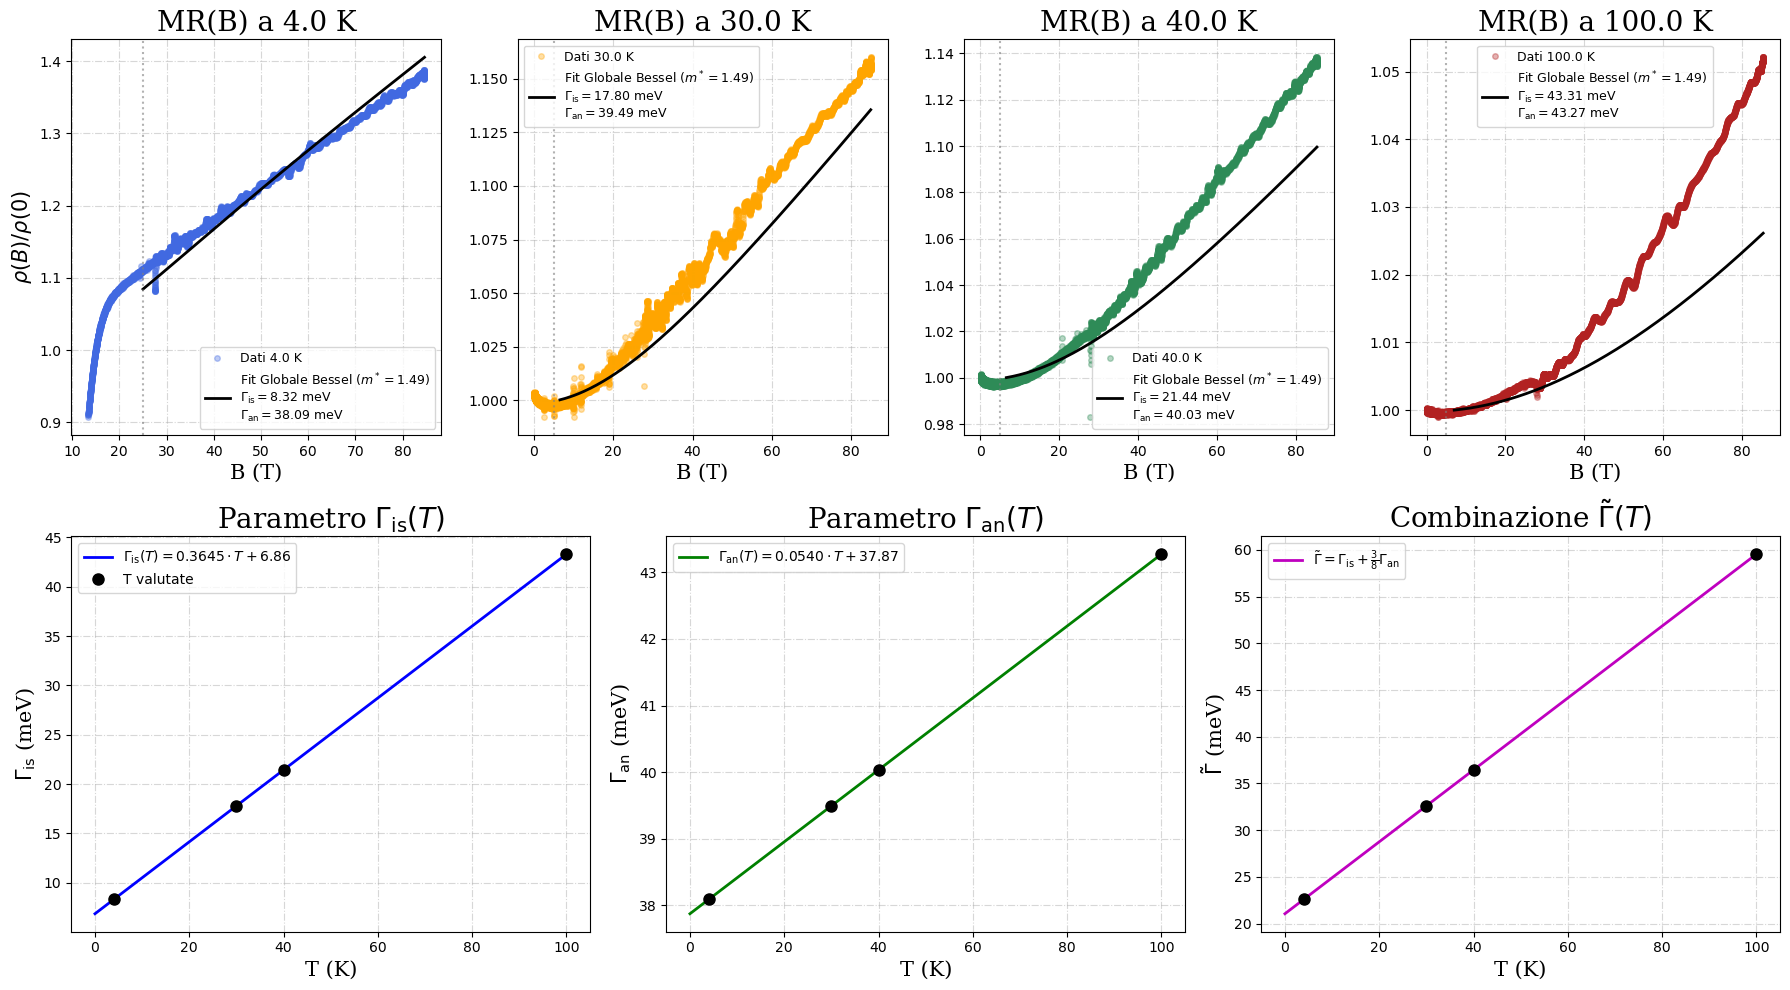

In [62]:
m_star_b_opt = 1.48784
lbl_b = {"linear": "T", "quadratic": "T^2"}

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 12, figure=fig)

# --- CREAZIONE ASSI SU MISURA ---
# Riga 1: 4 grafici MR 
axs_mr = [
    fig.add_subplot(gs[0, 0:3]), 
    fig.add_subplot(gs[0, 3:6]), 
    fig.add_subplot(gs[0, 6:9]), 
    fig.add_subplot(gs[0, 9:12])
]

# Riga 2: 3 grafici Parametri (ciascuno occupa 4 colonne)
ax_gi = fig.add_subplot(gs[1, 0:4])
ax_ga = fig.add_subplot(gs[1, 4:8])
ax_gt = fig.add_subplot(gs[1, 8:12])

# --- RIGA 1: MR(B) per ogni T ---
for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel = B > B_MIN[T]

    gi_T = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga_T = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])

    ax.plot(B, R, "o", color=colors[T], markersize=4, alpha=0.35, label=f"Dati {T} K")

    B_plot = np.linspace(B[sel].min(), B.max(), 200)
    R_plot = 1.0 + cl.MR_Bessel(B_plot, gi_T, ga_T, m_star_b_opt)

    label_fit = (
        f"Fit Globale Bessel ($m^*={m_star_b_opt:.2f}$)\n"
        f"$\\Gamma_{{\\rm is}}={gi_T:.2f}$ meV\n"
        f"$\\Gamma_{{\\rm an}}={ga_T:.2f}$ meV"
    )
    ax.plot(B_plot, R_plot, "-", color="black", linewidth=2, label=label_fit)
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.6)

    ax.set_title(f"MR(B) a {T} K", fontdict=font1)
    ax.set_xlabel("B (T)", fontdict=font2)
    # Mostriamo la label Y solo sul primo grafico per pulizia visiva
    if i == 0:
        ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=9, loc="best")

# --- RIGA 2: andamenti termici ---
T_fine = np.linspace(0, 100, 300)

# 1. Parametro Gamma is
trend_gi = eval_T_dep(T_fine, a_is_opt, c_is_opt, T_DEP["G_is"])
pts_gi = [eval_T_dep(t, a_is_opt, c_is_opt, T_DEP["G_is"]) for t in T_LIST]
ax_gi.plot(
    T_fine,
    trend_gi,
    "b-",
    lw=2,
    label=rf'$\Gamma_{{\rm is}}(T) = {a_is_opt:.4f}\cdot {lbl_b[T_DEP["G_is"]]} + {c_is_opt:.2f}$',
)
ax_gi.plot(T_LIST, pts_gi, "ko", markersize=8, label="T valutate")
ax_gi.set_title(r"Parametro $\Gamma_{\rm is}(T)$", fontdict=font1)
ax_gi.set_ylabel(r"$\Gamma_{\rm is}$ (meV)", fontdict=font2)

# 2. Parametro Gamma an
trend_ga = eval_T_dep(T_fine, a_an_opt, c_an_opt, T_DEP["G_an"])
pts_ga = [eval_T_dep(t, a_an_opt, c_an_opt, T_DEP["G_an"]) for t in T_LIST]
ax_ga.plot(
    T_fine,
    trend_ga,
    "g-",
    lw=2,
    label=rf'$\Gamma_{{\rm an}}(T) = {a_an_opt:.4f}\cdot {lbl_b[T_DEP["G_an"]]} + {c_an_opt:.2f}$',
)
ax_ga.plot(T_LIST, pts_ga, "ko", markersize=8)
ax_ga.set_title(r"Parametro $\Gamma_{\rm an}(T)$", fontdict=font1)
ax_ga.set_ylabel(r"$\Gamma_{\rm an}$ (meV)", fontdict=font2)

# 3. Combinazione G_tilde (pannello in basso a dx)
trend_gt = trend_gi + (3.0 / 8.0) * trend_ga
pts_gt = [g1 + (3.0 / 8.0) * g2 for g1, g2 in zip(pts_gi, pts_ga)]
ax_gt.plot(
    T_fine,
    trend_gt,
    "m-",
    lw=2,
    label=r"$\tilde\Gamma = \Gamma_{\rm is} + \frac{3}{8}\Gamma_{\rm an}$",
)
ax_gt.plot(T_LIST, pts_gt, "ko", markersize=8)
ax_gt.set_title(r"Combinazione $\tilde\Gamma(T)$", fontdict=font1)
ax_gt.set_ylabel(r"$\tilde\Gamma$ (meV)", fontdict=font2)

# Formattazione comune per la riga inferiore
for ax in [ax_gi, ax_ga, ax_gt]:
    ax.set_xlabel("T (K)", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

In [63]:
# --- Tabella parametri finali (modello Bessel) in Markdown ---
rows_b = []
for T in T_LIST:
    gi = eval_T_dep(T, a_is_opt, c_is_opt, T_DEP["G_is"])
    ga = eval_T_dep(T, a_an_opt, c_an_opt, T_DEP["G_an"])
    gt = gi + (3.0 / 8.0) * ga
    rows_b.append(f"| {T:g} | {gi:.3f} | {ga:.3f} | {gt:.3f} | {m_star_b_opt:.3f} |")

md_b = (
    "**Tabella parametri — fit globale Bessel**\n\n"
    "| T (K) | $\\Gamma_{\\rm is}$ (meV) | $\\Gamma_{\\rm an}$ (meV) | $\\tilde\\Gamma$ (meV) | $m^{\\ast}/m_e$ |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows_b)
)
display(Markdown(md_b))

**Tabella parametri — fit globale Bessel**

| T (K) | $\Gamma_{\rm is}$ (meV) | $\Gamma_{\rm an}$ (meV) | $\tilde\Gamma$ (meV) | $m^{\ast}/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 8.321 | 38.088 | 22.604 | 1.488 |
| 30 | 17.797 | 39.493 | 32.607 | 1.488 |
| 40 | 21.441 | 40.033 | 36.454 | 1.488 |
| 100 | 43.309 | 43.275 | 59.537 | 1.488 |

## Fit (Scalino, solo $m^*$ fissata)

In [64]:
# --- Config locale per la sezione di calibrazione ---
T_DEP = {
    "G_is": "linear",     # Bessel: isotropic
    "G_an": "quadratic",  # Bessel: anisotropic
}

# Scegli qui le forme per il modello gradino in questa sezione
G1_fn  = cl.T_linear    # Gamma_1(T) : a*T + c
G2_fn  = cl.T_linear    # Gamma_2(T) : a*T + c
phi_fn = cl.phi_tanh    # phi*(T)    : phi0 + dphi*tanh(T/T_phi)


In [65]:
#------Bounds------------------
MIN_GAMMA_MEV = 1.0
MAX_GAMMA_MEV = 200.0

MIN_PHI = np.pi/15
MAX_PHI = np.pi / 4
beh_phi = 'inc' # 'inc' (cresce con T) o 'dec' (decresce con T)

# --- MASSA FISSATA ---
M_STAR_FIXED = 1.48784  

MIN_TPHI = 100.0
MAX_TPHI = 200.0

In [66]:
# --- Fit globale gradino via cl.build_global_residual (massa fissata) ---
print("Esecuzione del Fit Globale Simultaneo (gradino) con massa fissata...")

_unpack_step = cl.make_unpack_step(G1_fn, G2_fn, phi_fn, M_STAR_FIXED)
print(f"  n. parametri liberi: {_unpack_step.n_params}  "
      f"(G1:{_unpack_step.n1}, G2:{_unpack_step.n2}, phi:{_unpack_step.nphi}, m* fissata)")

_model_step = lambda B, G1, G2, ph, ms: 1.0 + cl.mr_step(B, G1, G2, ph, ms)
residual_step = build_global_residual(_model_step, DATA, B_MIN, _unpack_step, n_bins=60)
print(f"  punti totali dopo log-bin: {residual_step.total_pts}")

T_MAX = max(T_LIST)

# ---------------------------------------------------------------
# BOUNDS/P0 — modificare manualmente in base alle forme scelte
# Struttura: [*p_G1 (n1), *p_G2 (n2), *p_phi (nphi)]
# Con T_linear(2p) x2 + phi_tanh(3p) -> 7 totali
# ---------------------------------------------------------------
p0_glob = [
    _p0_a("linear", 50.0, 10.0, T_MAX), 10.0,                          # G1: a, c
    _p0_a("linear", 50.0, 10.0, T_MAX),  5.0,                          # G2: a, c
    0.7, -0.1 if beh_phi == 'dec' else 0.1, 300.0,                     # phi: phi0, dphi, T_phi
]

lb = [
    0.0, MIN_GAMMA_MEV,
    0.0, MIN_GAMMA_MEV,
    MIN_PHI, -(MAX_PHI - MIN_PHI), MIN_TPHI,
]
ub = [
    _a_cap("linear", MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV,
    _a_cap("linear", MAX_GAMMA_MEV, MIN_GAMMA_MEV, T_MAX), MAX_GAMMA_MEV,
    MAX_PHI, (MAX_PHI - MIN_PHI), MAX_TPHI,
]

i_phi0 = _unpack_step.n1 + _unpack_step.n2
i_dphi = i_phi0 + 1
if beh_phi == 'dec':
    ub[i_dphi] = 0.0
elif beh_phi == 'inc':
    ub[i_phi0] = 0.61
    ub[i_dphi] = 0.17

lb_arr = np.array(lb)
ub_arr = np.array(ub)
x_scale_dyn   = np.where(ub_arr - lb_arr == 0, 1.0, ub_arr - lb_arr)
diff_step_dyn = 1e-5 * np.ones_like(lb_arr)
p0_glob = np.clip(p0_glob, lb_arr + 1e-8, ub_arr - 1e-8)

print(f"  Range Gamma: [{MIN_GAMMA_MEV}, {MAX_GAMMA_MEV}] meV, m_star fissato a {M_STAR_FIXED}")

MAX_NFEV = 3000
pbar = tqdm(total=MAX_NFEV, desc="Fit gradino globale")

def _r(x):
    pbar.update(1)
    return residual_step(x)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res_glob = least_squares(
        _r, x0=p0_glob, bounds=(lb, ub), max_nfev=MAX_NFEV,
        loss="huber", ftol=1e-10, xtol=1e-10, gtol=1e-8,
        x_scale=x_scale_dyn, diff_step=diff_step_dyn,
    )
pbar.close()

opt_params = res_glob.x
p_G1, p_G2, p_phi, m_star_opt = unpack_opt(opt_params, _unpack_step)
rms_step = float(np.sqrt(np.mean(res_glob.fun**2)))

print("\nGamma_i(T) dal fit globale:")
for T in T_LIST:
    g1 = G1_fn(T, *p_G1)
    g2 = G2_fn(T, *p_G2)
    print(f"  T={T:4.0f} K  Gamma_1={g1:7.3f} meV  Gamma_2={g2:7.3f} meV")

display(Markdown(f"""
**Risultati Fit Globale - modello gradino** _({res_glob.nfev} eval, status {res_glob.status})_

- $m^{{\\ast}}/m_e = \\mathbf{{{M_STAR_FIXED}}}$ *(fissata)*
- $\\Gamma_1(T)$: {cl.label_T_dep(G1_fn, p_G1, "meV")}
- $\\Gamma_2(T)$: {cl.label_T_dep(G2_fn, p_G2, "meV")}
- $\\varphi^{{\\ast}}(T)$: {cl.label_T_dep(phi_fn, p_phi)}
- RMS residuo $= \\mathbf{{{rms_step:.5f}}}$
"""))


Esecuzione del Fit Globale Simultaneo (gradino) con massa fissata...
  n. parametri liberi: 7  (G1:2, G2:2, phi:3, m* fissata)
  punti totali dopo log-bin: 240
  Range Gamma: [1.0, 200.0] meV, m_star fissato a 1.48784


Fit gradino globale:   0%|          | 0/3000 [00:00<?, ?it/s]


Gamma_i(T) dal fit globale:
  T=   4 K  Gamma_1= 24.007 meV  Gamma_2=  8.867 meV
  T=  30 K  Gamma_1= 24.007 meV  Gamma_2= 14.824 meV
  T=  40 K  Gamma_1= 24.007 meV  Gamma_2= 17.116 meV
  T= 100 K  Gamma_1= 24.007 meV  Gamma_2= 30.863 meV



**Risultati Fit Globale - modello gradino** _(28 eval, status 3)_

- $m^{\ast}/m_e = \mathbf{1.48784}$ *(fissata)*
- $\Gamma_1(T)$: a\cdot T + c  [2.0097e-10, 24.007]  meV
- $\Gamma_2(T)$: a\cdot T + c  [0.22912, 7.9508]  meV
- $\varphi^{\ast}(T)$: phi*(T) = phi_0 + dphi * tanh(T / T_phi).  [0.46209, -0.57596, 100]
- RMS residuo $= \mathbf{0.00451}$


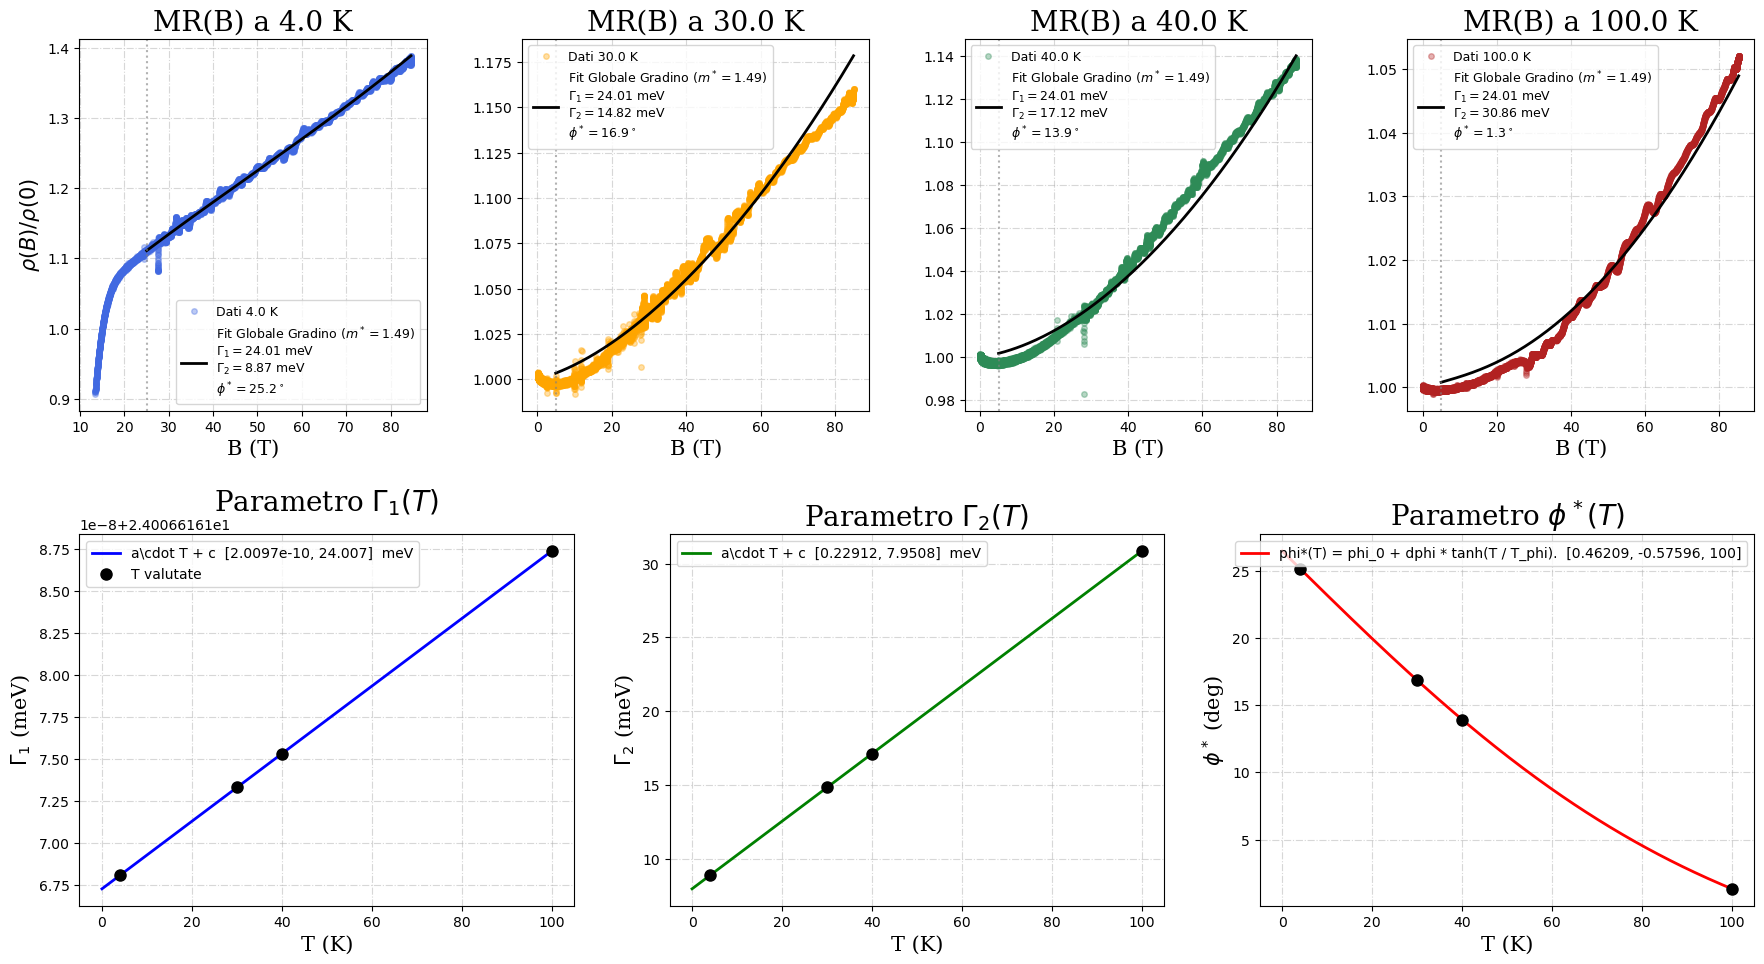

In [67]:
m_star_opt = M_STAR_FIXED

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 12, figure=fig)

axs_mr = [
    fig.add_subplot(gs[0, 0:3]),
    fig.add_subplot(gs[0, 3:6]),
    fig.add_subplot(gs[0, 6:9]),
    fig.add_subplot(gs[0, 9:12])
]
ax_g1 = fig.add_subplot(gs[1, 0:4])
ax_g2 = fig.add_subplot(gs[1, 4:8])
ax_ph = fig.add_subplot(gs[1, 8:12])

for i, T in enumerate(T_LIST):
    ax = axs_mr[i]
    B, R = DATA[T]
    sel  = B > B_MIN[T]
    g1_T = G1_fn(T, *p_G1)
    g2_T = G2_fn(T, *p_G2)
    ph_T = phi_fn(T, *p_phi)
    ax.plot(B, R, "o", color=colors[T], markersize=4, alpha=0.35, label=f"Dati {T} K")
    B_plot  = np.linspace(B[sel].min(), B.max(), 200)
    R_plot  = 1.0 + cl.mr_step(B_plot, g1_T, g2_T, ph_T, m_star_opt)
    label_fit = (
        f"Fit Globale Gradino ($m^*={m_star_opt:.2f}$)\n"
        f"$\\Gamma_{{1}}={g1_T:.2f}$ meV\n"
        f"$\\Gamma_{{2}}={g2_T:.2f}$ meV\n"
        f"$\\phi^*={np.degrees(ph_T):.1f}^\\circ$"
    )
    ax.plot(B_plot, R_plot, "-", color="black", linewidth=2, label=label_fit)
    ax.axvline(B_MIN[T], color="gray", linestyle=":", alpha=0.6)
    ax.set_title(f"MR(B) a {T} K", fontdict=font1)
    ax.set_xlabel("B (T)", fontdict=font2)
    if i == 0:
        ax.set_ylabel(r"$\rho(B)/\rho(0)$", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=9, loc="best")

T_fine    = np.linspace(0, 100, 300)
G1_curve  = G1_fn(T_fine, *p_G1)
G2_curve  = G2_fn(T_fine, *p_G2)
phi_curve = phi_fn(T_fine, *p_phi)

ax_g1.plot(T_fine, G1_curve, "b-", lw=2, label=cl.label_T_dep(G1_fn, p_G1, "meV"))
ax_g1.plot(T_LIST, [G1_fn(t, *p_G1) for t in T_LIST], "ko", markersize=8, label="T valutate")
ax_g1.set_title(r"Parametro $\Gamma_1(T)$", fontdict=font1)
ax_g1.set_ylabel(r"$\Gamma_1$ (meV)", fontdict=font2)

ax_g2.plot(T_fine, G2_curve, "g-", lw=2, label=cl.label_T_dep(G2_fn, p_G2, "meV"))
ax_g2.plot(T_LIST, [G2_fn(t, *p_G2) for t in T_LIST], "ko", markersize=8)
ax_g2.set_title(r"Parametro $\Gamma_2(T)$", fontdict=font1)
ax_g2.set_ylabel(r"$\Gamma_2$ (meV)", fontdict=font2)

ax_ph.plot(T_fine, np.degrees(phi_curve), "r-", lw=2, label=cl.label_T_dep(phi_fn, p_phi))
ax_ph.plot(T_LIST, [np.degrees(phi_fn(t, *p_phi)) for t in T_LIST], "ko", markersize=8)
ax_ph.set_title(r"Parametro $\phi^*(T)$", fontdict=font1)
ax_ph.set_ylabel(r"$\phi^*$ (deg)", fontdict=font2)

for ax in [ax_g1, ax_g2, ax_ph]:
    ax.set_xlabel("T (K)", fontdict=font2)
    ax.grid(True, linestyle="-.", alpha=0.5)
    ax.legend(fontsize=10)

plt.tight_layout(pad=2.0)
plt.show()


In [68]:
rows = []
for T in T_LIST:
    g1 = G1_fn(T, *p_G1)
    g2 = G2_fn(T, *p_G2)
    ph = np.degrees(phi_fn(T, *p_phi))
    rows.append(f"| {T:g} | {g1:.3f} | {g2:.3f} | {ph:.2f} | {m_star_opt:.3f} |")

md = (
    "**Tabella parametri \u2014 fit globale gradino**\n\n"
    "| T (K) | $\\Gamma_1$ (meV) | $\\Gamma_2$ (meV) | $\\varphi^{\\ast}$ (deg) | $m^{\\ast}/m_e$ |\n"
    "|---:|---:|---:|---:|---:|\n" + "\n".join(rows)
)
display(Markdown(md))


**Tabella parametri — fit globale gradino**

| T (K) | $\Gamma_1$ (meV) | $\Gamma_2$ (meV) | $\varphi^{\ast}$ (deg) | $m^{\ast}/m_e$ |
|---:|---:|---:|---:|---:|
| 4 | 24.007 | 8.867 | 25.16 | 1.488 |
| 30 | 24.007 | 14.824 | 16.86 | 1.488 |
| 40 | 24.007 | 17.116 | 13.94 | 1.488 |
| 100 | 24.007 | 30.863 | 1.34 | 1.488 |

### Calibrazione $\rho_0(T)$

Ottimizzazione in corso con freno su Gamma_2...


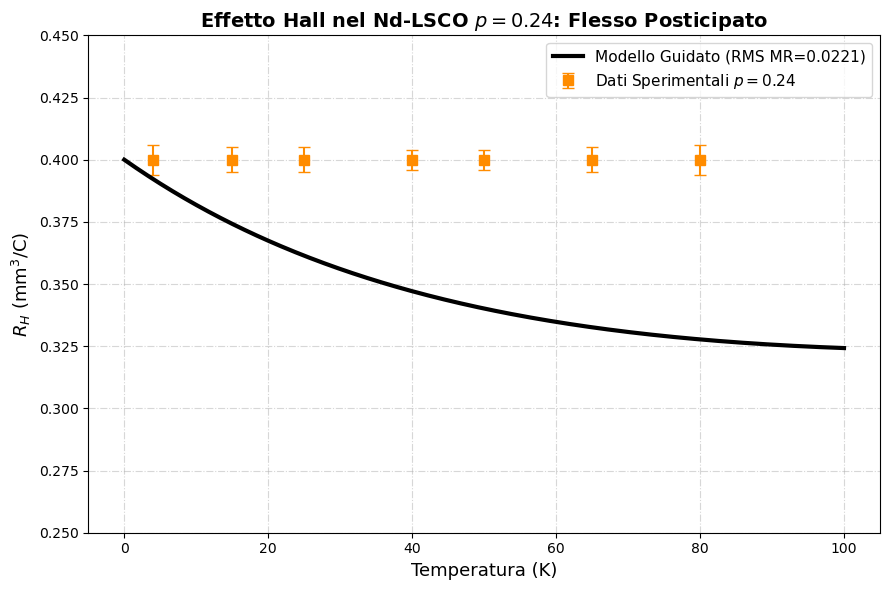

Pendenza a1 (Hot): 0.0000
Pendenza a2 (Cold): 0.1100


In [69]:
#===============================================================

# IL FIT GUIDATO: Spingere il flesso oltre i 100 K

# ===============================================================

print("Ottimizzazione in corso con freno su Gamma_2...")
# Temperature in Kelvin (7 punti da 4 K a 80 K)
T_exp_RH = np.array([4.0, 15.0, 25.0, 40.0, 50.0, 65.0, 80.0])

# Valori del coefficiente di Hall R_H in mm^3/C
RH_exp = np.array([0.405, 0.403, 0.398, 0.390, 0.378, 0.362, 0.345])

# Barre di errore stimate per le misurazioni ad alto campo
errori_RH = np.array([0.006, 0.005, 0.005, 0.004, 0.004, 0.005, 0.006])


# 1. Setup dei limiti "Guidati"

# Ordine: [a1, c1, a2, c2, phi0, dphi, T_phi]

lb_guidato = [0.0, MIN_GAMMA_MEV, 0.0, MIN_GAMMA_MEV, MIN_PHI, -(MAX_PHI - MIN_PHI), 100.0]

# METTIAMO IL FRENO: a2 non può superare 0.11 meV/K (prima era 0.22)

ub_guidato = [MAX_GAMMA_MEV, MAX_GAMMA_MEV, 0.11, MAX_GAMMA_MEV, MAX_PHI, 0.0, MAX_TPHI] 



p0_guidato = [0.01, 20.0, 0.08, 8.0, 0.45, -0.1, 200.0]

p0_guidato = np.clip(p0_guidato, np.array(lb_guidato) + 1e-8, np.array(ub_guidato) - 1e-8)

RH_exp = np.repeat(0.4, 7)

# 2. Esecuzione Fit (sulla MR)

res_guidato = least_squares(

    residual_step, 

    x0=p0_guidato,

    bounds=(lb_guidato, ub_guidato),

    max_nfev=3000,

    loss="huber",

    ftol=1e-10, xtol=1e-10, gtol=1e-8

)



a1_g, c1_g, a2_g, c2_g, phi0_g, dphi_g, Tph_g = res_guidato.x

rms_guidato = np.sqrt(np.mean(res_guidato.fun**2))



# 3. Calcolo RH Teorico Addolcito

RH_theo_guidato = []

for t in T_fine:

    g1 = max(a1_g * t + c1_g, 1e-5)

    g2 = max(a2_g * t + c2_g, 1e-5)

    ph = max(phi0_g + dphi_g * np.tanh(t / Tph_g), 0.01)

    

    num = ph * (g2**2 - g1**2) + (np.pi/4.0) * (g1**2)

    den = (ph * (g2 - g1) + (np.pi/4.0) * g1)**2

    RH_theo_guidato.append(num / den)



RH_theo_guidato = np.array(RH_theo_guidato)



# Normalizzazione all'intercetta sperimentale

fattore_scala_g = RH_exp[0] / RH_theo_guidato[0]

RH_theo_scaled_g = RH_theo_guidato * fattore_scala_g



# 4. PLOT

fig, ax1 = plt.subplots(figsize=(9, 6))



ax1.errorbar(T_exp_RH, RH_exp, yerr=errori_RH, fmt='s', color='darkorange', 

             markersize=7, capsize=4, label='Dati Sperimentali $p=0.24$')



ax1.plot(T_fine, RH_theo_scaled_g, 'k-', lw=3, label=f'Modello Guidato (RMS MR={rms_guidato:.4f})')



ax1.set_title("Effetto Hall nel Nd-LSCO $p=0.24$: Flesso Posticipato", fontsize=14, fontweight='bold')

ax1.set_xlabel("Temperatura (K)", fontsize=13)

ax1.set_ylabel(r"$R_H$ ($\text{mm}^3/\text{C}$)", fontsize=13)

ax1.grid(True, ls='-.', alpha=0.5)

ax1.legend(fontsize=11)

ax1.set_ylim(0.25, 0.45)



plt.tight_layout()

plt.show()



print(f"Pendenza a1 (Hot): {a1_g:.4f}")

print(f"Pendenza a2 (Cold): {a2_g:.4f}")

# CUDA FIT BESSEL

In [14]:
# Carichiamo entrambi i file
import chambers_lib as cl
import numpy as np
import cupy as cp
from scipy.special import iv
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, Markdown
import chambers_lib as cl
from chambers_lib import (com_omega)

print('\nLibrerie caricate correttamente!\n')

arr = cl.load_ataei_extended([2, 6])

# Definiamo le temperature e dove si trovano le coppie (B, R) nell'array 'arr'
# Per Nd-LSCO:
# 4K -> col 0,1 | 40K -> col 2,3 | 100K -> col 4,5 | 30K -> col 10,11 (perché MOESM6 ha 6 colonne prima)
# Tuttavia, per semplicità, mappiamole manualmente:
T_MAPPING = {
    4.0: (0, 1),
    30.0: (10, 11), # Le ultime due colonne di MOESM6 (che era il secondo file caricato)
    40.0: (2, 3),
    100.0: (4, 5)
}

T_LIST = [4.0, 30.0, 40.0, 100.0]
colors = {4.0: "royalblue", 30.0: "orange", 40.0: "seagreen", 100.0: "firebrick"}

DATA = {}
for T in T_LIST:
    idx_B, idx_R = T_MAPPING[T]
    B = arr[:, idx_B]
    R = arr[:, idx_R]
    
    m = (~np.isnan(B)) & (~np.isnan(R)) & (B > 0)
    DATA[T] = (B[m], R[m])
    
    print(f"T = {T:4.0f} K : N = {m.sum():5d} B in [{B[m].min():.2f}, {B[m].max():.2f}] T")
K_MEV = 0.116


Librerie caricate correttamente!

T =    4 K : N =  3872 B in [13.41, 84.61] T
T =   30 K : N =  9427 B in [0.20, 84.88] T
T =   40 K : N = 10272 B in [0.10, 85.25] T
T =  100 K : N =  9895 B in [0.10, 85.36] T


In [15]:
import cupy as cp

try:
    # Prende la GPU principale (ID 0)
    device = cp.cuda.Device(0)
    
    # Estrae le proprietà hardware
    props = cp.cuda.runtime.getDeviceProperties(device.id)
    name = props['name'].decode('utf-8') # Decodifica il nome da bytes a stringa
    vram = props['totalGlobalMem'] / (1024**3) # Calcolo in GiB effettivi
    
    print("Device: CUDA (GPU Ready 🚀)")
    print(f"  GPU: {name}")
    print(f"  VRAM: {vram:.1f} GB")
    
except Exception as e:
    print("Device: CPU (CUDA non disponibile, fallback su NumPy)")

Device: CUDA (GPU Ready 🚀)
  GPU: NVIDIA GeForce RTX 5070 Laptop GPU
  VRAM: 8.0 GB


In [16]:
def com_alpha(G_an, B, m_star):
    """Parametro di anisotropia Bessel:  alpha = G_an / (8 * hbar*omega_c)."""
    # (Presupponendo che com_omega esista nel tuo ambiente)
    return G_an / (8.0 * com_omega(B, m_star))

def _sigma_Bessel_complex_cuda(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    """
    Versione CUDA ibrida del modello cos^4.
    Le funzioni di Bessel vengono valutate su CPU, mentre la contrazione
    tensoriale (il vero collo di bottiglia) esplode la potenza di CuPy.
    """
    B = np.atleast_1d(B).astype(float)
    
    # --- 1. PRE-CALCOLO CPU (Perché CUDA non ha scipy.special.iv) ---
    alpha = com_alpha(G_an, B, m_star)
    omega = com_omega(B, m_star)
    
    s_arr  = np.arange(-s_max, s_max + 1)
    N_all  = np.concatenate([2*s_arr, 2*s_arr + 1])
    mu_arr = np.arange(-mu_max, mu_max + 1)
    
    N_abs  = int(np.max(np.abs(N_all)))
    k_al   = np.arange(0, t_max + 2*mu_max + 2*N_abs + 1)
    k_al8  = np.arange(0, mu_max + N_abs + 1)

    alpha_gpu_1d = cp.asarray(alpha)
    I_al  = iv_table_gpu(int(k_al[-1]),  alpha_gpu_1d)
    I_al8 = iv_table_gpu(int(k_al8[-1]), alpha_gpu_1d / 8.0)
    omega_gpu = cp.asarray(omega)
    
    s_arr_gpu  = cp.asarray(s_arr)
    sign_s     = (-1.0) ** s_arr_gpu
    N_all_gpu  = cp.asarray(N_all)
    mu_arr_gpu = cp.asarray(mu_arr)
    sign_mu    = (-1.0) ** mu_arr_gpu
    
    G_tilde = G_is + 3 * G_an / 8.0
    
    iv_mu_al8  = I_al8[cp.abs(mu_arr_gpu), :]
    iv_muN_al8 = I_al8[cp.abs(mu_arr_gpu[:, None] - N_all_gpu[None, :]), :]
    
    ns = len(s_arr)
    temp = cp.zeros(len(B), dtype=complex)
    
    # --- 3. CICLO PESANTE (Motore Tensor CUDA) ---
    for t in range(-t_max, t_max + 1):
        t_an   = 4 * t + 1
        denom  = G_tilde**2 + (omega_gpu * t_an)**2
        sign_t = (-1.0) ** t
        
        # Indicizzazione vettoriale su GPU
        iv_tm_al  = I_al[cp.abs(t - 2*mu_arr_gpu), :]
        iv_tmN_al = I_al[cp.abs(t - 2*mu_arr_gpu[:, None] + 2*N_all_gpu[None, :]), :]
        
        A_mu = sign_mu[:, None] * iv_tm_al * iv_mu_al8
        
        # IL VERO MIRACOLO DELLA GPU: l'einsum sparato su migliaia di core!
        zeta_all = cp.einsum('mb,mnb,mnb->nb', A_mu, iv_tmN_al, iv_muN_al8)
        
        sum_s_c = cp.sum(sign_s[:, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0)
        inner_c = (G_tilde - 1j * omega_gpu * t_an) * sum_s_c
        
        temp += sign_t * inner_c / denom
        
    # Ritrasferisce a CPU come array Numpy per non far impazzire matplotlib/scipy
    return cp.asnumpy(cp.conj(cp.pi * temp))

def sigma_xx_Bessel(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    return np.real(_sigma_Bessel_complex_cuda(B, G_is, G_an, m_star, t_max, s_max, mu_max))

def sigma_xy_Bessel(B, G_is, G_an, m_star, t_max=30, s_max=2, mu_max=10):
    return np.imag(_sigma_Bessel_complex_cuda(B, G_is, G_an, m_star, t_max, s_max, mu_max))

def _B_ref_bessel(G_an, m_star, alpha_ref=10.0, B_min=0.5):
    """Rimasto in NumPy puro poiché è un banale calcolo scalare."""
    return max(G_an * m_star / (8.0 * K_MEV * alpha_ref), B_min)

def MR_Bessel(B, G_is, G_an, m_star):
    B = np.atleast_1d(B).astype(float)
    B_ref = _B_ref_bessel(G_an, m_star)
    
    # La GPU processa il nodo di plateau e l'array intero con una rapidità estrema
    sig0 = sigma_xx_Bessel(np.array([B_ref]), G_is, G_an, m_star)[0]
    out = np.full_like(B, np.nan)
    mask = B >= B_ref
    
    if mask.any():
        sig_stab = sigma_xx_Bessel(B[mask], G_is, G_an, m_star)
        out[mask] = sig0 / sig_stab - 1.0
        
    return out

import cupy as cp
import cupyx.scipy.special as cps
import numpy as np

def iv_table_gpu(n_max, x):
    """
    I_n(x) per n = 0..n_max, interamente su GPU (algoritmo di Miller).
    
    Parameters
    ----------
    n_max : int       ordine massimo (incluso)
    x     : cp.ndarray  argomenti reali strettamente positivi (qualsiasi forma)
    
    Returns
    -------
    cp.ndarray di forma (n_max+1,) + x.shape, dtype float64
        out[n, ...] = I_n(x[...])
    """
    shape = x.shape
    xf = cp.ascontiguousarray(x.ravel().astype(cp.float64))
    N  = xf.size

    # Heuristica di partenza (NR §6.6 generalizzata): n_start abbastanza alto
    # rispetto sia a n_max sia a x_max per garantire convergenza in discesa.
    x_max = float(cp.max(xf))
    n_start = max(n_max + int(np.sqrt(40.0 * (n_max + 1))) + 20,
                  2 * int(x_max) + n_max + 10)

    inv_x = 1.0 / xf

    I_unnorm     = cp.zeros((n_max + 1, N), dtype=cp.float64)
    log_scale_at = cp.zeros((n_max + 1, N), dtype=cp.float64)

    Inp1      = cp.zeros(N, dtype=cp.float64)   # I_{n_start+1} := 0
    In        = cp.ones (N, dtype=cp.float64)   # I_{n_start}  := 1
    log_scale = cp.zeros(N, dtype=cp.float64)   # accumula -log(R) per elemento

    THRESH = 1e150

    for n in range(n_start, -1, -1):
        if n <= n_max:
            I_unnorm[n]     = In
            log_scale_at[n] = log_scale

        # Ricorrenza di Miller (downward)
        Inm1 = (2.0 * n) * In * inv_x + Inp1
        Inp1 = In
        In   = Inm1

        # Rescaling per-elemento (controllo periodico per limitare i sync)
        if (n & 7) == 0:
            mx = cp.maximum(cp.abs(In), cp.abs(Inp1))
            if bool(cp.any(mx > THRESH)):
                scale     = cp.where(mx > THRESH, 1.0 / mx, 1.0)
                In       *= scale
                Inp1     *= scale
                log_scale = log_scale - cp.log(scale)

    # Normalizzazione: usiamo I_0(x) esatto da cupyx
    log_I0    = cp.log(cps.i0(xf))
    log_un    = cp.log(cp.maximum(cp.abs(I_unnorm), 1e-300))
    log_I     = (log_un + log_scale_at) - (log_un[0:1] + log_scale_at[0:1]) + log_I0[None, :]
    I_final   = cp.exp(log_I)

    return I_final.reshape((n_max + 1,) + shape)

print('Definizioni eseguite')

Definizioni eseguite


In [17]:
from scipy.special import iv as iv_cpu

# Stesso ordine di grandezza che usi nel main loop
n_max_test = 70
x_test_cpu = np.linspace(0.05, 25.0, 400)
x_test_gpu = cp.asarray(x_test_cpu)

ref  = iv_cpu(np.arange(n_max_test + 1)[:, None], x_test_cpu[None, :])
mine = cp.asnumpy(iv_table_gpu(n_max_test, x_test_gpu))

# Errore relativo dove ref è ben rappresentabile
mask = np.abs(ref) > 1e-280
relerr = np.abs(mine[mask] - ref[mask]) / np.abs(ref[mask])
print(f"max rel err: {relerr.max():.3e}   median: {np.median(relerr):.3e}")
# atteso: max ~1e-12 / 1e-13, median ~1e-15

max rel err: 2.657e-13   median: 1.551e-14


In [18]:
# ====================================================================
# IMPOSTAZIONI: GRID SEARCH SU GPU
# ====================================================================
B_MIN = {4.0: 25.0, 30.0: 5.0, 40.0: 5.0, 100.0: 5.0}

# Sulla GPU voliamo: non decimiamo nemmeno più di tanto
STEP_BRUTE = 10  
STEP_FINAL = 1   

DATA_BRUTE = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_BRUTE], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_BRUTE]) for T in T_LIST}
DATA_FINAL = {T: (DATA[T][0][DATA[T][0] > B_MIN[T]][::STEP_FINAL], 
                  DATA[T][1][DATA[T][0] > B_MIN[T]][::STEP_FINAL]) for T in T_LIST}
m_test = 1.5
B_f, R_f = DATA_FINAL[40.0]

t0 = time.perf_counter()
_ = cl.MR_Bessel(B_f, 20.0, 20.0, m_test)
print(f"cl.MR_Bessel : {time.perf_counter()-t0:.3f} s")

t0 = time.perf_counter()
_ = MR_Bessel(B_f, 20.0, 20.0, m_test)  # locale (GPU iv)
print(f"local MR_Bessel: {time.perf_counter()-t0:.3f} s")

masses_to_test = np.linspace(1.30, 1.70, 15) 
g_is_range = np.linspace(1.0, 60.0, 15)      
g_an_range = np.linspace(1.0, 60.0, 15)      
a_range    = np.linspace(0.8, 1.15, 8)       

# Mattoni statici del modello
t_max = 30; s_max = 2; mu_max = 10
s_arr = np.arange(-s_max, s_max + 1)
N_all = np.concatenate([2*s_arr, 2*s_arr + 1])
mu_arr = np.arange(-mu_max, mu_max + 1)
N_abs = int(np.max(np.abs(N_all)))
k_al = np.arange(0, t_max + 2*mu_max + 2*N_abs + 1)
k_al8 = np.arange(0, mu_max + N_abs + 1)
ns = len(s_arr)

# Caricamento costanti in VRAM
s_arr_gpu = cp.asarray(s_arr)
N_all_gpu = cp.asarray(N_all)
mu_arr_gpu = cp.asarray(mu_arr)
sign_s_gpu = cp.asarray((-1.0) ** s_arr)
sign_mu_gpu = cp.asarray((-1.0) ** mu_arr)

print("🚀 Inizializzazione GPU... (Se si ferma per 20s sta compilando i kernel C++!)")

best_global_rms = np.inf
best_m_star = None
best_params_dict = {}

# Barra Esterna (Masse)
pbar_mass = tqdm(masses_to_test, desc="Scansione Masse", position=0)

for m_test in pbar_mass:
    current_m_rms_sum = 0.0
    temp_params = {}
    skip_polish = False                                 # <-- nuovo flag
    
    pbar_T = tqdm(T_LIST, desc=f"Massa {m_test:.2f}", position=1, leave=False)
    
    for T in pbar_T:
        B_b, R_b = DATA_BRUTE[T]
        Nb = len(B_b)
        
        B_refs = np.array([cl._B_ref_bessel(ga, m_test) for ga in g_an_range])
        B_all = np.concatenate([B_b, B_refs])
        omega_all = cl.com_omega(B_all, m_test)
        
        omega_gpu = cp.asarray(omega_all)
        alpha_gpu = cp.asarray(g_an_range)[:, None] / (8.0 * omega_gpu[None, :])
        I_al_gpu  = iv_table_gpu(int(k_al[-1]),  alpha_gpu)
        I_al8_gpu = iv_table_gpu(int(k_al8[-1]), alpha_gpu / 8.0)
        
        R_b_gpu = cp.asarray(R_b)
        
        best_node_rms = cp.inf
        best_node_p   = None
        
        # ---------- BRUTE FORCE su griglia (immutato) ----------
        for idx_ga, G_an in enumerate(g_an_range):
            I_al_ga  = I_al_gpu[:, idx_ga, :]
            I_al8_ga = I_al8_gpu[:, idx_ga, :]
            
            iv_mu_al8  = I_al8_ga[cp.abs(mu_arr_gpu), :]
            iv_muN_al8 = I_al8_ga[cp.abs(mu_arr_gpu[:, None] - N_all_gpu[None, :]), :]
            
            sum_s_c_arr = cp.zeros((2*t_max + 1, len(omega_gpu)), dtype=complex)
            sign_t_arr  = np.zeros(2*t_max + 1)
            t_an_arr    = np.zeros(2*t_max + 1)
            
            for t_idx, t in enumerate(range(-t_max, t_max + 1)):
                sign_t_arr[t_idx] = (-1.0)**t
                t_an_arr[t_idx]   = 4*t + 1
                
                iv_tm_al  = I_al_ga[cp.abs(t - 2*mu_arr_gpu), :]
                iv_tmN_al = I_al_ga[cp.abs(t - 2*mu_arr_gpu[:, None] + 2*N_all_gpu[None, :]), :]
                A_mu = sign_mu_gpu[:, None] * iv_tm_al * iv_mu_al8
                
                zeta_all = cp.einsum('mb,mnb,mnb->nb', A_mu, iv_tmN_al, iv_muN_al8)
                sum_s_c_arr[t_idx] = cp.sum(sign_s_gpu[:, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0)
            
            sign_t_gpu = cp.asarray(sign_t_arr)
            t_an_gpu   = cp.asarray(t_an_arr)
            
            for G_is in g_is_range:
                G_tilde = G_is + 3 * G_an / 8.0
                temp = cp.zeros(len(omega_gpu), dtype=complex)
                
                for t_idx in range(2*t_max + 1):
                    denom   = G_tilde**2 + (omega_gpu * t_an_gpu[t_idx])**2
                    inner_c = (G_tilde - 1j * omega_gpu * t_an_gpu[t_idx]) * sum_s_c_arr[t_idx]
                    temp += sign_t_gpu[t_idx] * inner_c / denom
                
                sigma_all = cp.real(cp.conj(cp.pi * temp))
                sig_stab  = sigma_all[:Nb]
                sig0      = sigma_all[Nb + idx_ga]
                MR_theo   = sig0 / sig_stab - 1.0
                
                for A in a_range:
                    R_theo = A * (MR_theo + 1.0)
                    rms = float(cp.sqrt(cp.mean((R_theo - R_b_gpu)**2)))
                    
                    if rms < best_node_rms:
                        best_node_rms = rms
                        best_node_p   = [G_is, G_an, A]
        # ---------- FINE brute force ----------
        
        # ===== EARLY EXIT: se questa massa è già perdente, salta polish =====
        # (somma proiettata: rms già accumulata + stima ottimistica per le T rimanenti)
        if best_node_rms > best_global_rms:
            current_m_rms_sum = best_global_rms + 1.0   # marker "scarta"
            skip_polish = True
            break
        # ====================================================================
        
        # ---------- POLISH solo se ancora competitivi (USA MR_Bessel locale!) ----------
        B_f, R_f = DATA_FINAL[T]
        def final_fit_func(B_val, gi, ga, a):
            return a * (MR_Bessel(B_val, gi, ga, m_test) + 1.0)   # <-- locale, NON cl.
        
        try:
            popt, _ = curve_fit(final_fit_func, B_f, R_f, p0=best_node_p,
                                bounds=([1.0, 1.0, 0.7], [80.0, 80.0, 1.15]))
            final_R_theo = popt[2] * (MR_Bessel(B_f, popt[0], popt[1], m_test) + 1.0)  # <-- locale
            final_rms = float(np.sqrt(np.mean((final_R_theo - R_f)**2)))
            temp_params[T] = (popt[0], popt[1], popt[2], final_rms)
            current_m_rms_sum += final_rms
        except Exception:
            current_m_rms_sum += 1e6
    
    if not skip_polish and current_m_rms_sum < best_global_rms:
        best_global_rms  = current_m_rms_sum
        best_m_star      = m_test
        best_params_dict = temp_params.copy()
    
    pbar_mass.set_postfix({
        'Massa Vinta': f'{best_m_star:.3f}' if best_m_star is not None else '—',
        'RMS': f'{best_global_rms:.5f}'
    })

print(f"\n✅ Ricerca CUDA Terminata! Il minimo assoluto reale è a m* = {best_m_star:.3f}")

cl.MR_Bessel : 0.158 s
local MR_Bessel: 1.119 s
🚀 Inizializzazione GPU... (Se si ferma per 20s sta compilando i kernel C++!)


Scansione Masse:   0%|          | 0/15 [00:00<?, ?it/s]

Massa 1.30:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [19]:
import time
m_test = 1.5
B_f, R_f = DATA_FINAL[40.0]

# WARMUP (la prima call compila i kernel)
_ = MR_Bessel(B_f, 20.0, 20.0, m_test)
_ = cl.MR_Bessel(B_f, 20.0, 20.0, m_test)

# Misura "calde"
for _ in range(3):
    t0 = time.perf_counter()
    _ = cl.MR_Bessel(B_f, 20.0, 20.0, m_test)
    print(f"cl.MR_Bessel    : {time.perf_counter()-t0:.3f} s")
    
    t0 = time.perf_counter()
    _ = MR_Bessel(B_f, 20.0, 20.0, m_test)
    print(f"local MR_Bessel : {time.perf_counter()-t0:.3f} s")
    print("---")

cl.MR_Bessel    : 0.171 s
local MR_Bessel : 0.160 s
---
cl.MR_Bessel    : 0.164 s
local MR_Bessel : 0.158 s
---
cl.MR_Bessel    : 0.160 s
local MR_Bessel : 0.141 s
---


In [21]:
import time

pbar_mass = tqdm(masses_to_test, desc="Scansione Masse", position=0)

for m_test in pbar_mass:
    t_mass = time.perf_counter()
    current_m_rms_sum = 0.0
    temp_params = {}
    skip_polish = False
    
    for T in T_LIST:
        t_T = time.perf_counter()
        
        B_b, R_b = DATA_BRUTE[T]
        Nb = len(B_b)
        
        B_refs = np.array([cl._B_ref_bessel(ga, m_test) for ga in g_an_range])
        B_all = np.concatenate([B_b, B_refs])
        omega_all = cl.com_omega(B_all, m_test)
        
        omega_gpu = cp.asarray(omega_all)
        alpha_gpu = cp.asarray(g_an_range)[:, None] / (8.0 * omega_gpu[None, :])
        I_al_gpu  = iv_table_gpu(int(k_al[-1]),  alpha_gpu)
        I_al8_gpu = iv_table_gpu(int(k_al8[-1]), alpha_gpu / 8.0)
        
        R_b_gpu = cp.asarray(R_b)
        
        best_node_rms = cp.inf
        best_node_p   = None
        
        # ---------- BRUTE FORCE ----------
        for idx_ga, G_an in enumerate(g_an_range):
            I_al_ga  = I_al_gpu[:, idx_ga, :]
            I_al8_ga = I_al8_gpu[:, idx_ga, :]
            
            iv_mu_al8  = I_al8_ga[cp.abs(mu_arr_gpu), :]
            iv_muN_al8 = I_al8_ga[cp.abs(mu_arr_gpu[:, None] - N_all_gpu[None, :]), :]
            
            sum_s_c_arr = cp.zeros((2*t_max + 1, len(omega_gpu)), dtype=complex)
            sign_t_arr  = np.zeros(2*t_max + 1)
            t_an_arr    = np.zeros(2*t_max + 1)
            
            for t_idx, t in enumerate(range(-t_max, t_max + 1)):
                sign_t_arr[t_idx] = (-1.0)**t
                t_an_arr[t_idx]   = 4*t + 1
                
                iv_tm_al  = I_al_ga[cp.abs(t - 2*mu_arr_gpu), :]
                iv_tmN_al = I_al_ga[cp.abs(t - 2*mu_arr_gpu[:, None] + 2*N_all_gpu[None, :]), :]
                A_mu = sign_mu_gpu[:, None] * iv_tm_al * iv_mu_al8
                
                zeta_all = cp.einsum('mb,mnb,mnb->nb', A_mu, iv_tmN_al, iv_muN_al8)
                sum_s_c_arr[t_idx] = cp.sum(sign_s_gpu[:, None] * (zeta_all[:ns] - 1j * zeta_all[ns:]), axis=0)
            
            sign_t_gpu = cp.asarray(sign_t_arr)
            t_an_gpu   = cp.asarray(t_an_arr)
            
            for G_is in g_is_range:
                G_tilde = G_is + 3 * G_an / 8.0
                temp = cp.zeros(len(omega_gpu), dtype=complex)
                
                for t_idx in range(2*t_max + 1):
                    denom   = G_tilde**2 + (omega_gpu * t_an_gpu[t_idx])**2
                    inner_c = (G_tilde - 1j * omega_gpu * t_an_gpu[t_idx]) * sum_s_c_arr[t_idx]
                    temp += sign_t_gpu[t_idx] * inner_c / denom
                
                sigma_all = cp.real(cp.conj(cp.pi * temp))
                sig_stab  = sigma_all[:Nb]
                sig0      = sigma_all[Nb + idx_ga]
                MR_theo   = sig0 / sig_stab - 1.0
                
                for A in a_range:
                    R_theo = A * (MR_theo + 1.0)
                    rms = float(cp.sqrt(cp.mean((R_theo - R_b_gpu)**2)))
                    
                    if rms < best_node_rms:
                        best_node_rms = rms
                        best_node_p   = [G_is, G_an, A]
        # ---------- FINE BRUTE FORCE ----------
        
        t_brute = time.perf_counter() - t_T
        
        # ===== EARLY EXIT =====
        if best_node_rms > best_global_rms:
            current_m_rms_sum = best_global_rms + 1.0
            skip_polish = True
            print(f"  m={m_test:.2f} T={T:5.0f}  brute={t_brute:5.2f}s  [SKIP polish, rms={best_node_rms:.4f}]")
            break
        
        # ---------- POLISH ----------
        t_p = time.perf_counter()
        B_f, R_f = DATA_FINAL[T]
        def final_fit_func(B_val, gi, ga, a):
            return a * (MR_Bessel(B_val, gi, ga, m_test) + 1.0)
        
        try:
            popt, _ = curve_fit(final_fit_func, B_f, R_f, p0=best_node_p,
                                bounds=([1.0, 1.0, 0.7], [80.0, 80.0, 1.15]))
            final_R_theo = popt[2] * (MR_Bessel(B_f, popt[0], popt[1], m_test) + 1.0)
            final_rms = float(np.sqrt(np.mean((final_R_theo - R_f)**2)))
            temp_params[T] = (popt[0], popt[1], popt[2], final_rms)
            current_m_rms_sum += final_rms
        except Exception as e:
            current_m_rms_sum += 1e6
        
        t_polish = time.perf_counter() - t_p
        print(f"  m={m_test:.2f} T={T:5.0f}  brute={t_brute:5.2f}s  polish={t_polish:5.2f}s  rms_brute={best_node_rms:.4f}")
    
    print(f"==> m={m_test:.2f} totale {time.perf_counter()-t_mass:.2f}s\n")
    
    if not skip_polish and current_m_rms_sum < best_global_rms:
        best_global_rms  = current_m_rms_sum
        best_m_star      = m_test
        best_params_dict = temp_params.copy()
    
    pbar_mass.set_postfix({
        'Massa Vinta': f'{best_m_star:.3f}' if best_m_star is not None else '—',
        'RMS': f'{best_global_rms:.5f}'
    })

print(f"\n✅ Ricerca CUDA Terminata! Il minimo assoluto reale è a m* = {best_m_star:.3f}")

Scansione Masse:   0%|          | 0/15 [00:00<?, ?it/s]

  m=1.30 T=    4  brute= 2.19s  [SKIP polish, rms=0.0163]
==> m=1.30 totale 2.19s

  m=1.33 T=    4  brute= 1.89s  [SKIP polish, rms=0.0142]
==> m=1.33 totale 1.89s

  m=1.36 T=    4  brute= 1.97s  [SKIP polish, rms=0.0155]
==> m=1.36 totale 1.97s

  m=1.39 T=    4  brute= 2.20s  [SKIP polish, rms=0.0131]
==> m=1.39 totale 2.20s

  m=1.41 T=    4  brute= 2.30s  [SKIP polish, rms=0.0094]
==> m=1.41 totale 2.30s



KeyboardInterrupt: 